# Phase 2 — Exploratory Data Analysis (EDA)
## Adaptive Real-Time Financial Transaction Fraud Detection Using XGBoost, Kafka, Spark, Explainable AI, Drift Detection and Automated Model Retraining

**Project stage:** Phase 1 (dataset selection) + Phase 2 (exploratory data analysis)
**Dataset:** PaySim — Synthetic Financial Dataset for Fraud Detection (Kaggle: `ealaxi/paysim1`)
**Notebook:** `notebooks/02_exploratory_data_analysis.ipynb`

> **Scope of this notebook.** This notebook only *studies* the data. It trains **no** model, applies **no** resampling, builds **no** streaming pipeline, and does **not** modify the raw CSV. Every number reported below is computed from the actual CSV when the notebook is run.

## SECTION 1 — Project Introduction

### What is financial transaction fraud detection?
Financial transaction fraud detection is the task of deciding, for each payment or transfer, whether it is legitimate or fraudulent. In machine-learning terms it is usually framed as **binary classification**: given the information describing a transaction, estimate the probability that it is fraudulent.

### Why is it an important machine learning problem?
Fraud causes direct financial loss to customers and institutions, and decisions must be made on very large volumes of transactions where manual review of every case is not feasible. Machine learning can help rank or score transactions so that limited human attention is focused on the riskiest ones. (This project makes no claims about the size of real-world fraud losses; it treats fraud detection as an engineering and modelling problem.)

### Why are fraud datasets usually highly imbalanced?
Most transactions are legitimate, so fraudulent cases are typically a very small minority. The class ratio is a property of the data-generating process, and we will **measure it from the CSV** in Section 7 rather than assume it.

### Why is fraud detection different from ordinary classification?
| Aspect | Ordinary classification | Fraud detection |
|---|---|---|
| Class balance | Often roughly balanced | Usually extremely imbalanced |
| Cost of errors | Often symmetric | **Asymmetric** — missed fraud and false alarms have different costs |
| Time | Rows often treated as independent | Transactions are **ordered in time**; behaviour and fraud patterns can change |
| Labels | Available immediately | Often **delayed** (a fraud may be confirmed days later) |
| Evaluation | Accuracy is often acceptable | Accuracy is misleading; precision/recall/PR-AUC are preferred |
| Explanations | Optional | Frequently required to justify blocking a customer's transaction |

### Why do false positives and false negatives matter?
* **False negative** (fraud predicted as legitimate): the fraud goes through undetected.
* **False positive** (legitimate predicted as fraud): a genuine customer is inconvenienced or blocked.

Reducing one usually increases the other, so the final system must expose a **risk score and a tunable threshold** instead of only a hard 0/1 output.

### What is the final project intended to accomplish?
The final system will (1) train an XGBoost model on historical data, (2) score new transactions in near real time through Kafka and Spark Structured Streaming, (3) explain each prediction with SHAP and counterfactuals, (4) store predictions and later join them with delayed ground-truth labels, (5) monitor for drift, and (6) retrain, evaluate and conditionally promote a new model version.

### What role does EDA play?
EDA is the foundation: it tells us **what data exists, what is safe to use, and what could mislead the model**. Its results feed directly into feature engineering (Phase 3) and every later component.

| Future component | What this EDA contributes |
|---|---|
| **XGBoost** | Class imbalance severity, candidate features, skew/outlier behaviour of numeric columns |
| **Real-time streaming** | Which columns exist at prediction time; how to replay the data in time order |
| **Kafka** | Message schema (which fields a transaction event needs); how to order events |
| **Spark Structured Streaming** | Which features need history (windowed/stateful) versus row-level computation |
| **SHAP** | Which features are meaningful vs. leakage-prone (explanations of leaked features are meaningless) |
| **Drift monitoring** | Which variables/distributions are worth monitoring; a descriptive reference period |
| **Automated retraining** | How a chronological "old vs. recent" split can be built and labelled with delay |

## SECTION 2 — Environment and Imports

**Purpose:** Import libraries, define configurable paths, and create output folders.
**Relevance:** Reproducible paths are required so the same notebook can later be reused by scripts in `src/`.

The dataset path can be changed either by editing `DATA_PATH` below or by setting the environment variable `PAYSIM_DATA_PATH` before launching Jupyter.

In [1]:
import os
import json
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Only silence FutureWarnings (pandas/seaborn API deprecation chatter). Real warnings stay visible.
warnings.filterwarnings("ignore", category=FutureWarning)

# ---- Paths (no hardcoded absolute paths) -------------------------------------------------
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DEFAULT_CSV = PROJECT_ROOT / "data" / "raw" / "PS_20174392719_1491204439457_log.csv"
DATA_PATH = Path(os.environ.get("PAYSIM_DATA_PATH", DEFAULT_CSV))

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
REPORT_PATH = REPORTS_DIR / "eda_summary.json"

for _d in (FIGURES_DIR, TABLES_DIR, PROJECT_ROOT / "data" / "processed", PROJECT_ROOT / "models", PROJECT_ROOT / "src"):
    _d.mkdir(parents=True, exist_ok=True)

# ---- Column-name configuration -------------------------------------------------------------
TARGET = "isFraud"
FLAG_COL = "isFlaggedFraud"
EXPECTED_COLUMNS = ["step", "type", "amount", "nameOrig", "oldbalanceOrg", "newbalanceOrig",
                    "nameDest", "oldbalanceDest", "newbalanceDest", "isFraud", "isFlaggedFraud"]
BALANCE_COLS = ["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
EXPECTED_TYPES = {"PAYMENT", "TRANSFER", "CASH_OUT", "DEBIT", "CASH_IN"}  # from the PaySim documentation

# ---- Plot configuration --------------------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "axes.titlesize": 12,
                     "axes.labelsize": 10, "legend.fontsize": 9})
COLORS = {0: "#4C72B0", 1: "#C44E52"}            # legitimate = blue, fraud = red
CLASS_NAMES = {0: "Legitimate", 1: "Fraud"}
pd.options.display.float_format = "{:,.4f}".format
pd.options.display.max_columns = 50

# ---- Global containers filled while the notebook runs -------------------------------------
TABLES = {}        # filename -> DataFrame (written to disk in Section 32)
FINDINGS = {}      # computed facts reused by later sections and the final summary


# ---- Small helper functions ------------------------------------------------------------------
def md(text):
    """Render Markdown text in the notebook output."""
    display(Markdown(text))


def rel(path):
    """Path relative to the project root (for tidy printing)."""
    try:
        return Path(path).resolve().relative_to(PROJECT_ROOT)
    except ValueError:
        return Path(path)


def cols_present(df, cols, analysis):
    """Return True if all columns exist; otherwise print a clear skip message."""
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"[SKIPPED] {analysis}: required column(s) not found in the CSV -> {missing}")
        return False
    return True


def save_fig(fig, filename):
    """Save a figure to reports/figures/."""
    path = FIGURES_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    print(f"Figure saved -> {rel(path)}")


def pct(part, whole):
    return 100.0 * part / whole if whole else 0.0


print("Project root :", PROJECT_ROOT)
print("Data path    :", DATA_PATH)
print("Figures dir  :", rel(FIGURES_DIR))
print("Tables dir   :", rel(TABLES_DIR))
print("pandas", pd.__version__, "| numpy", np.__version__)

Project root : D:\fraud-detection-system\fraud-detection-system
Data path    : D:\fraud-detection-system\fraud-detection-system\data\raw\PS_20174392719_1491204439457_log.csv
Figures dir  : reports\figures
Tables dir   : reports\tables
pandas 2.2.2 | numpy 1.26.4


## SECTION 3 — Dataset Existence and File Information

**Purpose:** Fail loudly and helpfully if the CSV is not where we expect it.
**Relevance:** Silent failures would produce empty or fake analysis.

In [2]:
def check_dataset_file(path):
    """Verify the CSV exists and print basic file information. Raises FileNotFoundError otherwise."""
    print("File path   :", path)
    exists = Path(path).is_file()
    print("File exists :", exists)
    if not exists:
        raise FileNotFoundError(
            "\n\nThe PaySim CSV was not found.\n"
            f"Expected location:\n  {path}\n\n"
            "How to fix:\n"
            "  1. Download the dataset from https://www.kaggle.com/datasets/ealaxi/paysim1\n"
            "  2. Unzip it and place the file 'PS_20174392719_1491204439457_log.csv' in <project>/data/raw/\n"
            "  3. Or set the environment variable PAYSIM_DATA_PATH to the CSV location, then restart Jupyter.\n"
        )
    size_mb = Path(path).stat().st_size / 1024 ** 2
    print(f"File size   : {size_mb:,.2f} MB")
    return size_mb


FILE_SIZE_MB = check_dataset_file(DATA_PATH)

File path   : D:\fraud-detection-system\fraud-detection-system\data\raw\PS_20174392719_1491204439457_log.csv
File exists : True
File size   : 470.67 MB


## SECTION 4 — Load the Dataset

**Purpose:** Load the CSV once, with memory-efficient data types.
**Relevance:** PaySim has roughly 6 million rows; careless loading can exhaust RAM on a laptop. (Rule of thumb: keep at least 8 GB of RAM free.)

**Design choices**
* The header is read first, and dtypes are assigned **only to columns that actually exist**.
* Small-range columns use small integer types; `type` is a `category`.
* Money columns stay `float64` to preserve precision for the balance-consistency checks in Section 17.
* Account IDs (`nameOrig`, `nameDest`) are stored as Arrow strings when `pyarrow` is available (much smaller than Python objects). If not, pandas falls back to normal strings.
* The DataFrame is **never copied**; later sections use column views or small aggregates.

In [4]:
def load_dataset(path):
    """Load the CSV efficiently. Inspects the header first so missing columns never cause a crash."""
    header = pd.read_csv(path, nrows=0).columns.tolist()
    dtype_map = {"step": "int32", "type": "category", "amount": "float64",
                 "oldbalanceOrg": "float64", "newbalanceOrig": "float64",
                 "oldbalanceDest": "float64", "newbalanceDest": "float64",
                 "isFraud": "int8", "isFlaggedFraud": "int8"}
    dtypes = {c: t for c, t in dtype_map.items() if c in header}
    try:
        import pyarrow  # noqa: F401  (optional dependency, only used to save RAM)
        for c in ("nameOrig", "nameDest"):
            if c in header:
                dtypes[c] = "string[pyarrow]"
    except ImportError:
        pass
    try:
        return pd.read_csv(path, dtype=dtypes)
    except (ValueError, TypeError) as exc:
        # e.g. NaNs in an integer column -> retry with pandas' own dtype inference
        print(f"Efficient dtypes failed ({exc}); falling back to default type inference.")
        return pd.read_csv(path)


df = load_dataset(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
md("**First 5 rows**")
display(df.head())
md("**Last 5 rows**")
display(df.tail())
md("**Random sample of 5 rows** (`random_state=42` for reproducibility)")
display(df.sample(5, random_state=42))

Shape: (6362620, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


**First 5 rows**

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0


**Last 5 rows**

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,"339,682.1300",C786484425,"339,682.1300",0.0000,C776919290,0.0000,"339,682.1300",1,0
6362616,743,TRANSFER,"6,311,409.2800",C1529008245,"6,311,409.2800",0.0000,C1881841831,0.0000,0.0000,1,0
6362617,743,CASH_OUT,"6,311,409.2800",C1162922333,"6,311,409.2800",0.0000,C1365125890,"68,488.8400","6,379,898.1100",1,0
6362618,743,TRANSFER,"850,002.5200",C1685995037,"850,002.5200",0.0000,C2080388513,0.0000,0.0000,1,0
6362619,743,CASH_OUT,"850,002.5200",C1280323807,"850,002.5200",0.0000,C873221189,"6,510,099.1100","7,360,101.6300",1,0


**Random sample of 5 rows** (`random_state=42` for reproducibility)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,"330,218.4200",C632336343,"20,866.0000","351,084.4200",C834976624,"452,419.5700","122,201.1500",0,0
264914,15,PAYMENT,"11,647.0800",C1264712553,"30,370.0000","18,722.9200",M215391829,0.0000,0.0000,0,0
85647,10,CASH_IN,"152,264.2100",C1746846248,"106,589.0000","258,853.2100",C1607284477,"201,303.0100","49,038.8000",0,0
5899326,403,TRANSFER,"1,551,760.6300",C333676753,0.0000,0.0000,C1564353608,"3,198,359.4500","4,750,120.0800",0,0
2544263,206,CASH_IN,"78,172.3000",C813403091,"2,921,331.5800","2,999,503.8800",C1091768874,"415,821.9000","337,649.6000",0,0


## SECTION 5 — Basic Dataset Overview

**Purpose:** Size, memory, data types, cardinality of each column, and numeric summary.
**Relevance:** Determines which columns can be used numerically, which are identifiers, and how much memory the later Spark/Pandas pipelines will need.

*Scope: FULL DATASET ANALYSIS.*

In [5]:
ORIGINAL_COLUMNS = df.columns.tolist()          # snapshot: later EDA-only columns are excluded from schema logic
HAS = {c: (c in df.columns) for c in EXPECTED_COLUMNS}
MISSING_EXPECTED = [c for c, ok in HAS.items() if not ok]
UNEXPECTED_EXTRA = [c for c in ORIGINAL_COLUMNS if c not in EXPECTED_COLUMNS]
HAS_TARGET = HAS[TARGET]

print("Expected columns found   :", [c for c, ok in HAS.items() if ok])
print("Expected columns MISSING :", MISSING_EXPECTED if MISSING_EXPECTED else "none")
print("Extra columns (not in PaySim documentation):", UNEXPECTED_EXTRA if UNEXPECTED_EXTRA else "none")
if MISSING_EXPECTED:
    print("\nWARNING: analyses depending on the missing columns will be skipped with an explicit message.")

numeric_cols = [c for c in ORIGINAL_COLUMNS if pd.api.types.is_numeric_dtype(df[c])]
datetime_cols = [c for c in ORIGINAL_COLUMNS if pd.api.types.is_datetime64_any_dtype(df[c])]
categorical_cols = [c for c in ORIGINAL_COLUMNS if c not in numeric_cols and c not in datetime_cols]


def get_dataset_overview(df):
    """Return (column_table, dataset_summary_table, numeric_summary_table)."""
    n_rows, n_cols = df.shape
    mem_mb = df.memory_usage(deep=True).sum() / 1024 ** 2
    rows = []
    for c in ORIGINAL_COLUMNS:
        n_missing = int(df[c].isna().sum())
        rows.append({"Column": c, "Data Type": str(df[c].dtype), "Unique Values": int(df[c].nunique(dropna=True)),
                     "Missing Count": n_missing, "Missing Percentage": pct(n_missing, n_rows)})
    col_table = pd.DataFrame(rows)
    summary = pd.DataFrame({
        "Metric": ["Rows", "Columns", "Memory usage (MB)", "CSV file size (MB)", "Numeric columns",
                   "Categorical/string columns", "Datetime-like columns", "Expected columns missing"],
        "Value": [n_rows, n_cols, round(mem_mb, 2), round(FILE_SIZE_MB, 2), len(numeric_cols),
                  len(categorical_cols), len(datetime_cols), len(MISSING_EXPECTED)]})
    num_summary = df[numeric_cols].describe().T.rename(columns={"count": "Count", "mean": "Mean", "std": "Std", "min": "Min",
                                                                 "max": "Max"}) if numeric_cols else pd.DataFrame()
    return col_table, summary, num_summary, mem_mb


col_table, dataset_summary, numeric_summary, MEMORY_MB = get_dataset_overview(df)
FINDINGS.update(n_rows=len(df), n_cols=df.shape[1], memory_mb=MEMORY_MB)
TABLES.update({"dataset_summary.csv": dataset_summary, "data_types.csv": col_table,
               "numeric_summary.csv": numeric_summary})

display(dataset_summary)
md("**Column summary**")
display(col_table)
md("**Numeric summary**")
display(numeric_summary)
print("Numeric columns    :", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Datetime columns   :", datetime_cols if datetime_cols else "none (PaySim time is the integer 'step')")

Expected columns found   : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Expected columns MISSING : none
Extra columns (not in PaySim documentation): none


,Metric,Value
0,Rows,"6,362,620.0000"
1,Columns,11.0000
2,Memory usage (MB),509.4800
3,CSV file size (MB),470.6700
4,Numeric columns,8.0000
5,Categorical/string columns,3.0000
6,Datetime-like columns,0.0000
7,Expected columns missing,0.0000


**Column summary**

,Column,Data Type,Unique Values,Missing Count,Missing Percentage
0,step,int32,743,0,0.0000
1,type,category,5,0,0.0000
2,amount,float64,5316900,0,0.0000
3,nameOrig,string,6353307,0,0.0000
4,oldbalanceOrg,float64,1845844,0,0.0000
5,newbalanceOrig,float64,2682586,0,0.0000
6,nameDest,string,2722362,0,0.0000
7,oldbalanceDest,float64,3614697,0,0.0000
8,newbalanceDest,float64,3555499,0,0.0000
9,isFraud,int8,2,0,0.0000


**Numeric summary**

,Count,Mean,Std,Min,25%,50%,75%,Max
step,"6,362,620.0000",243.3972,142.3320,1.0000,156.0000,239.0000,335.0000,743.0000
amount,"6,362,620.0000","179,861.9035","603,858.2315",0.0000,"13,389.5700","74,871.9400","208,721.4775","92,445,516.6400"
oldbalanceOrg,"6,362,620.0000","833,883.1041","2,888,242.6730",0.0000,0.0000,"14,208.0000","107,315.1750","59,585,040.3700"
newbalanceOrig,"6,362,620.0000","855,113.6686","2,924,048.5030",0.0000,0.0000,0.0000,"144,258.4100","49,585,040.3700"
oldbalanceDest,"6,362,620.0000","1,100,701.6665","3,399,180.1130",0.0000,0.0000,"132,705.6650","943,036.7075","356,015,889.3500"
newbalanceDest,"6,362,620.0000","1,224,996.3982","3,674,128.9421",0.0000,0.0000,"214,661.4400","1,111,909.2500","356,179,278.9200"
isFraud,"6,362,620.0000",0.0013,0.0359,0.0000,0.0000,0.0000,0.0000,1.0000
isFlaggedFraud,"6,362,620.0000",0.0000,0.0016,0.0000,0.0000,0.0000,0.0000,1.0000


Numeric columns    : ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Categorical columns: ['type', 'nameOrig', 'nameDest']
Datetime columns   : none (PaySim time is the integer 'step')


**Interpretation.** Check that (i) the row count matches what you expect from PaySim, (ii) numeric columns are numeric and IDs/`type` are strings/categories, and (iii) the unique-value counts make sense: `nameOrig` should be almost unique per row (an identifier), while `type` should have very few values.

**Relevance to the final system.** Columns typed as identifiers will need *behavioural aggregation* rather than direct encoding (Sections 13, 23 and 27). Memory usage tells us whether Phase 3 can use plain pandas or needs chunking.

## SECTION 6 — Data Quality Audit

**Purpose:** Count and quantify missing values, duplicates, infinite values, negative/zero amounts, negative balances, unexpected categories and impossible values.
**Relevance:** Data-quality problems in a streaming system become production incidents; we need to know which validations the Kafka producer/consumer must perform.

> The raw data is **not modified** here.

In [6]:
def analyze_data_quality(df):
    """Run all quality checks; returns a table (Check, Count, Percentage, Why it matters)."""
    n = len(df)
    rows = []

    def add(check, count, why, denom=n):
        rows.append({"Check": check, "Count": int(count), "Percentage": pct(count, denom), "Why it matters": why})

    add("Missing cells (all columns)", int(df.isna().sum().sum()),
        "Missing inputs must be imputed or rejected; XGBoost can handle NaN but the stream must define behaviour.",
        denom=n * df.shape[1])
    add("Rows with at least one missing value", int(df.isna().any(axis=1).sum()), "Shows how widespread missingness is per record.")

    dup_mask = df.duplicated()
    add("Duplicate rows (all columns identical)", int(dup_mask.sum()),
        "Exact duplicates may be replayed/duplicated events and can inflate training counts.")

    id_like = [c for c in ORIGINAL_COLUMNS if c.lower() in ("transactionid", "transaction_id", "txn_id", "trans_id", "id")]
    if id_like:
        for c in id_like:
            add(f"Duplicate values in transaction-ID column '{c}'", int(df[c].duplicated().sum()),
                "A transaction ID should be unique; duplicates break idempotent processing in Kafka/Spark.")
    else:
        add("Duplicate transaction IDs (N/A - no transaction-ID column)", 0,
            "PaySim has no transaction ID; the streaming design must generate its own event ID (e.g. row index).")

    float_cols = [c for c in numeric_cols if pd.api.types.is_float_dtype(df[c])]
    add("Infinite values (float columns)", sum(int(np.isinf(df[c].to_numpy()).sum()) for c in float_cols),
        "Infinite values break scaling/statistics and must be blocked in the stream.")
    add("NaN values in numeric columns", int(df[numeric_cols].isna().sum().sum()) if numeric_cols else 0,
        "Numeric NaNs need an explicit imputation policy.", denom=n * max(len(numeric_cols), 1))

    if HAS["amount"]:
        add("Negative amounts", int((df["amount"] < 0).sum()), "A negative transaction amount is not meaningful.")
        add("Zero amounts", int((df["amount"] == 0).sum()), "Zero-value transactions may be test/probe transactions.")
    for c in BALANCE_COLS:
        if HAS[c]:
            add(f"Negative values in {c}", int((df[c] < 0).sum()), "Negative balances would indicate overdraft or data errors.")
    if HAS["type"]:
        observed = set(df["type"].dropna().unique().tolist())
        unexpected = sorted(observed - EXPECTED_TYPES)
        add(f"Unexpected 'type' values (expected {sorted(EXPECTED_TYPES)})", int(df["type"].isin(unexpected).sum()),
            f"Unknown categories would break encoders. Unexpected values found: {unexpected if unexpected else 'none'}.")
    if HAS["step"]:
        add("Non-positive 'step' values", int((df["step"] < 1).sum()), "Step is a 1-based simulated hour; values < 1 are impossible.")
    if HAS_TARGET:
        add("Target values outside {0,1}", int((~df[TARGET].isin([0, 1])).sum()), "Target must be strictly binary.")
    if HAS[FLAG_COL]:
        add("isFlaggedFraud values outside {0,1}", int((~df[FLAG_COL].isin([0, 1])).sum()), "Flag must be strictly binary.")
    return pd.DataFrame(rows), dup_mask


quality_table, dup_mask = analyze_data_quality(df)
display(quality_table)

if dup_mask.sum() > 0:
    md("**Examples of duplicate rows**")
    display(df[df.duplicated(keep=False)].head(10))
if HAS["amount"] and (df["amount"] == 0).any():
    md("**Examples of zero-amount transactions**")
    display(df[df["amount"] == 0].head(5))

FINDINGS["duplicate_count"] = int(dup_mask.sum())
FINDINGS["missing_cells"] = int(df.isna().sum().sum())
FINDINGS["invalid_value_checks"] = quality_table[(quality_table["Count"] > 0) & quality_table["Check"].str.contains(
    "Negative|Infinite|outside|Non-positive|Unexpected")]["Check"].tolist()
del dup_mask
gc.collect()

missing_table = col_table[["Column", "Missing Count", "Missing Percentage"]].copy()
duplicate_summary = quality_table[quality_table["Check"].str.contains("Duplicate")].copy()
TABLES.update({"missing_values.csv": missing_table, "duplicate_summary.csv": duplicate_summary,
               "data_quality_audit.csv": quality_table})

,Check,Count,Percentage,Why it matters
0,Missing cells (all columns),0,0.0000,Missing inputs must be imputed or rejected; XG...
1,Rows with at least one missing value,0,0.0000,Shows how widespread missingness is per record.
2,Duplicate rows (all columns identical),0,0.0000,Exact duplicates may be replayed/duplicated ev...
3,Duplicate transaction IDs (N/A - no transactio...,0,0.0000,PaySim has no transaction ID; the streaming de...
4,Infinite values (float columns),0,0.0000,Infinite values break scaling/statistics and m...
5,NaN values in numeric columns,0,0.0000,Numeric NaNs need an explicit imputation policy.
6,Negative amounts,0,0.0000,A negative transaction amount is not meaningful.
7,Zero amounts,16,0.0003,Zero-value transactions may be test/probe tran...
8,Negative values in oldbalanceOrg,0,0.0000,Negative balances would indicate overdraft or ...
9,Negative values in newbalanceOrig,0,0.0000,Negative balances would indicate overdraft or ...


**Examples of zero-amount transactions**

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736447,212,CASH_OUT,0.0000,C1510987794,0.0000,0.0000,C1696624817,0.0000,0.0000,1,0
3247298,250,CASH_OUT,0.0000,C521393327,0.0000,0.0000,C480398193,0.0000,0.0000,1,0
3760289,279,CASH_OUT,0.0000,C539112012,0.0000,0.0000,C1106468520,"538,547.6300","538,547.6300",1,0
5563714,387,CASH_OUT,0.0000,C1294472700,0.0000,0.0000,C1325541393,"7,970,766.5700","7,970,766.5700",1,0
5996408,425,CASH_OUT,0.0000,C832555372,0.0000,0.0000,C1462759334,"76,759.9000","76,759.9000",1,0


**Interpretation.** A count of 0 for a check means the check passed on this file. Any non-zero count should be examined before Phase 3 decides how to clean or validate data.

**Relevance.** These checks become the *input validation rules* of the future Kafka consumer. Note again that we only **report** issues; we do not repair them in EDA.

## SECTION 7 — Target Variable Analysis (`isFraud`)

**Purpose:** Measure the class balance.
**Relevance:** Class imbalance drives the choice of evaluation metrics, threshold tuning and training strategy (Phase 4+). `isFraud` is the **ground-truth label** and is never an input feature.

*Scope: FULL DATASET ANALYSIS.*

,Class,Count,Percentage
0,Legitimate (0),6354407,99.8709
1,Fraud (1),8213,0.1291


Fraud count        : 8,213
Legitimate count   : 6,354,407
Fraud percentage   : 0.1291%
Imbalance ratio    : 1 fraud per 773.7 legitimate transactions
Accuracy of a model that always predicts 'legitimate': 99.8709%
Figure saved -> reports\figures\01_fraud_distribution.png


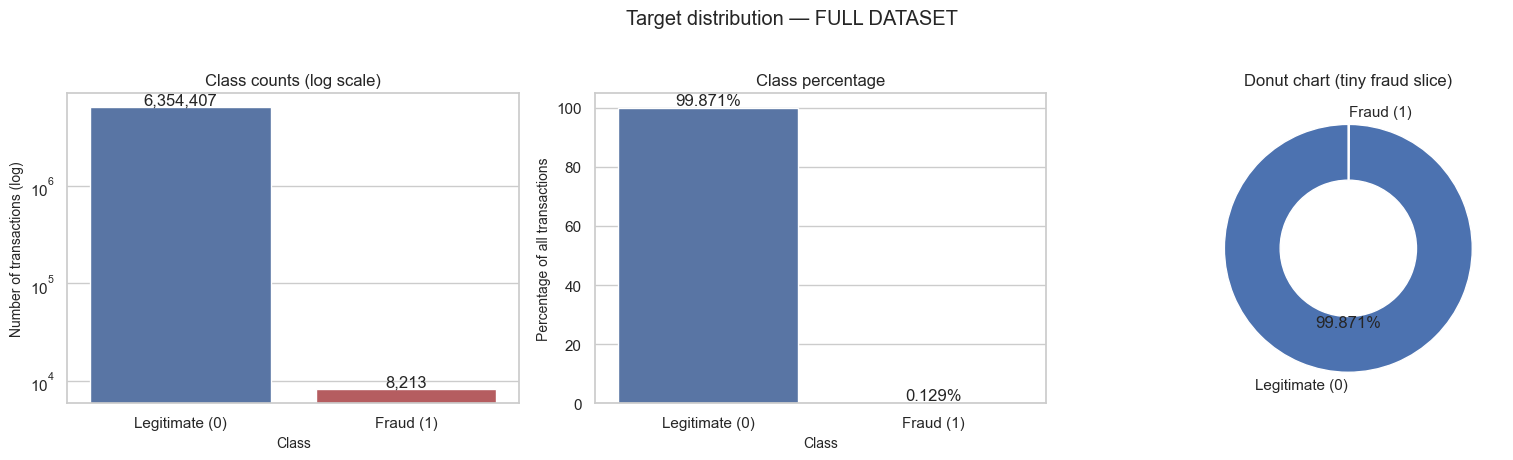

In [7]:
def analyze_target(df):
    """Class counts, percentages and imbalance ratio; returns (table, dict)."""
    vc = df[TARGET].value_counts()
    fraud_count = int(vc.get(1, 0))
    legit_count = int(vc.get(0, 0))
    total = len(df)
    ratio = (legit_count / fraud_count) if fraud_count else float("inf")
    table = pd.DataFrame({"Class": ["Legitimate (0)", "Fraud (1)"], "Count": [legit_count, fraud_count],
                          "Percentage": [pct(legit_count, total), pct(fraud_count, total)]})
    return table, {"fraud_count": fraud_count, "legitimate_count": legit_count,
                   "fraud_percentage": pct(fraud_count, total), "legitimate_percentage": pct(legit_count, total),
                   "imbalance_ratio": ratio}


if HAS_TARGET:
    target_table, target_info = analyze_target(df)
    FINDINGS.update(target_info)
    TABLES["fraud_distribution.csv"] = target_table
    display(target_table)
    print(f"Fraud count        : {target_info['fraud_count']:,}")
    print(f"Legitimate count   : {target_info['legitimate_count']:,}")
    print(f"Fraud percentage   : {target_info['fraud_percentage']:.4f}%")
    print(f"Imbalance ratio    : 1 fraud per {target_info['imbalance_ratio']:,.1f} legitimate transactions")
    print(f"Accuracy of a model that always predicts 'legitimate': {target_info['legitimate_percentage']:.4f}%")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    palette = [COLORS[0], COLORS[1]]
    sns.barplot(x=target_table["Class"], y=target_table["Count"], hue=target_table["Class"], palette=palette,
                legend=False, ax=axes[0])
    axes[0].set_yscale("log")
    axes[0].set_title("Class counts (log scale)")
    axes[0].set_ylabel("Number of transactions (log)")
    for i, v in enumerate(target_table["Count"]):
        axes[0].text(i, max(v, 1), f"{v:,}", ha="center", va="bottom")
    sns.barplot(x=target_table["Class"], y=target_table["Percentage"], hue=target_table["Class"], palette=palette,
                legend=False, ax=axes[1])
    axes[1].set_title("Class percentage")
    axes[1].set_ylabel("Percentage of all transactions")
    for i, v in enumerate(target_table["Percentage"]):
        axes[1].text(i, v, f"{v:.3f}%", ha="center", va="bottom")
    axes[2].pie(target_table["Count"], labels=target_table["Class"], colors=palette, startangle=90,
                wedgeprops={"width": 0.45}, autopct=lambda p: f"{p:.3f}%" if p > 0.5 else "")
    axes[2].set_title("Donut chart (tiny fraud slice)")
    fig.suptitle("Target distribution — FULL DATASET", y=1.02)
    plt.tight_layout()
    save_fig(fig, "01_fraud_distribution.png")
    plt.show()
else:
    print(f"[SKIPPED] Target analysis: column '{TARGET}' not found. Fraud-related sections will be skipped.")

**Observation.** The printed numbers show how skewed the label is. A trivial model that predicts "legitimate" for every transaction would already reach the accuracy printed above while detecting **zero** fraud — so **accuracy alone is not sufficient**.

**Metrics to be used later (not calculated now — there is no model yet):**
* **Precision** — of the transactions flagged as fraud, how many really were.
* **Recall** — of all real frauds, how many were caught.
* **F1-score** — harmonic mean of precision and recall.
* **PR-AUC** — area under the precision–recall curve; informative when the positive class is rare (ROC-AUC can look overly optimistic).

**Relevance.** This ratio will guide XGBoost's `scale_pos_weight` decision and threshold selection later, and the stratified temporal evaluation in Section 26.

## SECTION 8 — Transaction Type Analysis

**Purpose:** Volume of each transaction type and how fraud is distributed across them.
**Relevance:** `type` is a low-cardinality categorical variable that is available at transaction time, so it is a natural model feature and a natural drift-monitoring variable.

> Language note: we describe *concentration* of fraud, never *causes* of fraud.

,Transaction Type,Total Transactions,Fraud Transactions,Legitimate Transactions,Fraud Rate (%),Share of All Transactions (%),Share of All Fraud (%)
0,CASH_OUT,2237500,4116,2233384,0.1840,35.1663,50.1157
1,PAYMENT,2151495,0,2151495,0.0000,33.8146,0.0000
2,CASH_IN,1399284,0,1399284,0.0000,21.9923,0.0000
3,TRANSFER,532909,4097,528812,0.7688,8.3756,49.8843
4,DEBIT,41432,0,41432,0.0000,0.6512,0.0000


Number of transaction types: 5
Figure saved -> reports\figures\02_transaction_type_distribution.png


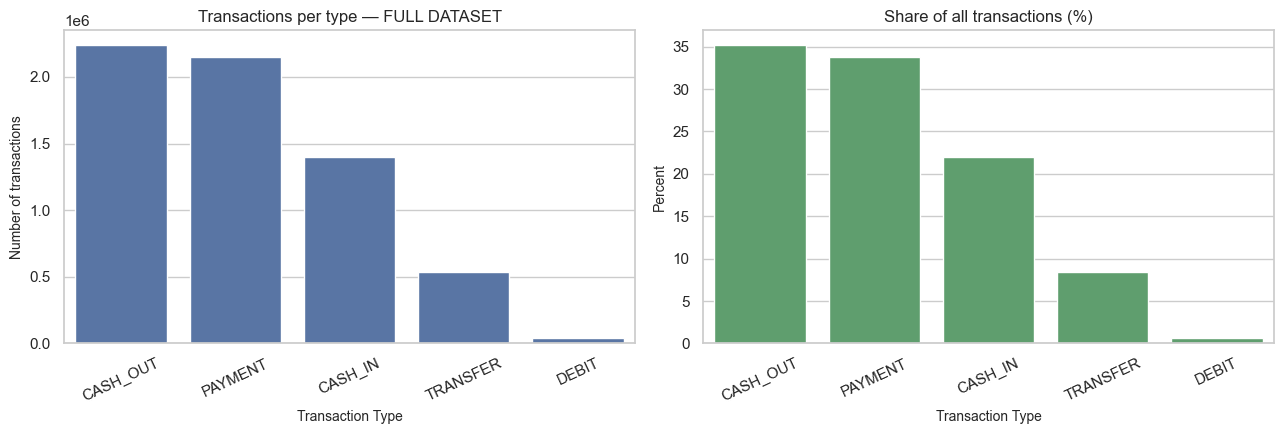

Figure saved -> reports\figures\03_fraud_rate_by_type.png


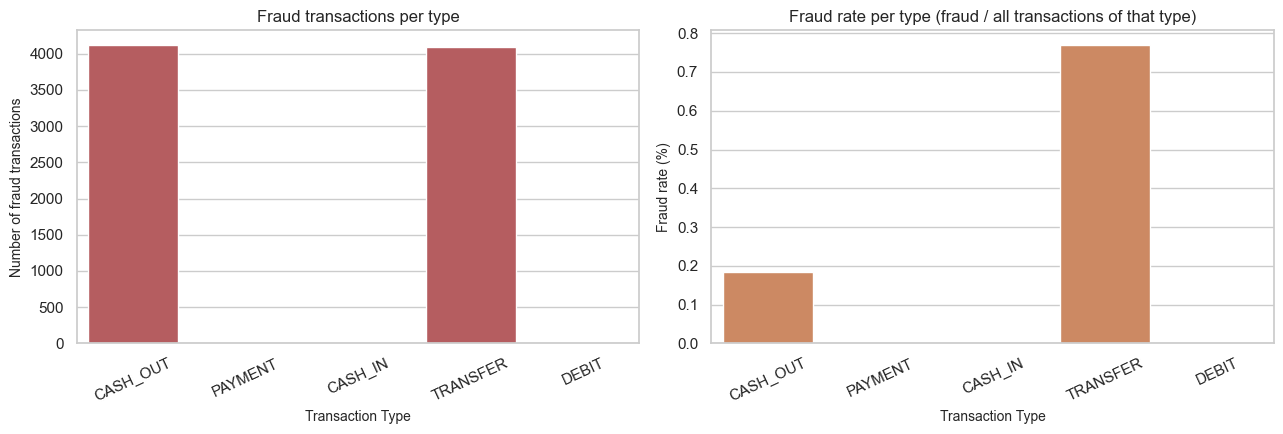


Observation (auto-generated): fraud is most concentrated in 'TRANSFER' (fraud rate 0.7688%).
Types that contain at least one fraud: ['CASH_OUT', 'TRANSFER']
Types with zero fraud in this file    : ['PAYMENT', 'CASH_IN', 'DEBIT']
These are descriptive associations, not causal statements.


In [8]:
def analyze_transaction_types(df):
    """Per-type counts, percentages, fraud counts and fraud rate."""
    total = len(df)
    if HAS_TARGET:
        g = df.groupby("type", observed=True)[TARGET].agg(["size", "sum"])
        tbl = pd.DataFrame({"Transaction Type": g.index.astype(str), "Total Transactions": g["size"].to_numpy(),
                            "Fraud Transactions": g["sum"].to_numpy().astype(int)})
        tbl["Legitimate Transactions"] = tbl["Total Transactions"] - tbl["Fraud Transactions"]
        tbl["Fraud Rate (%)"] = 100 * tbl["Fraud Transactions"] / tbl["Total Transactions"]
        tbl["Share of All Transactions (%)"] = 100 * tbl["Total Transactions"] / total
        tbl["Share of All Fraud (%)"] = 100 * tbl["Fraud Transactions"] / max(tbl["Fraud Transactions"].sum(), 1)
    else:
        vc = df["type"].value_counts()
        tbl = pd.DataFrame({"Transaction Type": vc.index.astype(str), "Total Transactions": vc.to_numpy()})
        tbl["Share of All Transactions (%)"] = 100 * tbl["Total Transactions"] / total
    return tbl.sort_values("Total Transactions", ascending=False).reset_index(drop=True)


if cols_present(df, ["type"], "Transaction-type analysis"):
    type_table = analyze_transaction_types(df)
    TABLES["transaction_type_analysis.csv"] = type_table
    FINDINGS["type_table"] = type_table
    display(type_table)
    print("Number of transaction types:", len(type_table))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.barplot(data=type_table, x="Transaction Type", y="Total Transactions", color="#4C72B0", ax=axes[0])
    axes[0].set_title("Transactions per type — FULL DATASET")
    axes[0].set_ylabel("Number of transactions")
    axes[0].tick_params(axis="x", rotation=25)
    sns.barplot(data=type_table, x="Transaction Type", y="Share of All Transactions (%)", color="#55A868", ax=axes[1])
    axes[1].set_title("Share of all transactions (%)")
    axes[1].set_ylabel("Percent")
    axes[1].tick_params(axis="x", rotation=25)
    plt.tight_layout()
    save_fig(fig, "02_transaction_type_distribution.png")
    plt.show()

    if HAS_TARGET:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
        sns.barplot(data=type_table, x="Transaction Type", y="Fraud Transactions", color=COLORS[1], ax=axes[0])
        axes[0].set_title("Fraud transactions per type")
        axes[0].set_ylabel("Number of fraud transactions")
        axes[0].tick_params(axis="x", rotation=25)
        sns.barplot(data=type_table, x="Transaction Type", y="Fraud Rate (%)", color="#DD8452", ax=axes[1])
        axes[1].set_title("Fraud rate per type (fraud / all transactions of that type)")
        axes[1].set_ylabel("Fraud rate (%)")
        axes[1].tick_params(axis="x", rotation=25)
        plt.tight_layout()
        save_fig(fig, "03_fraud_rate_by_type.png")
        plt.show()

        top = type_table.sort_values("Fraud Rate (%)", ascending=False).iloc[0]
        fraud_types = type_table[type_table["Fraud Transactions"] > 0]["Transaction Type"].tolist()
        no_fraud_types = type_table[type_table["Fraud Transactions"] == 0]["Transaction Type"].tolist()
        FINDINGS["fraud_types"] = fraud_types
        print(f"\nObservation (auto-generated): fraud is most concentrated in '{top['Transaction Type']}' "
              f"(fraud rate {top['Fraud Rate (%)']:.4f}%).")
        print(f"Types that contain at least one fraud: {fraud_types}")
        print(f"Types with zero fraud in this file    : {no_fraud_types}")
        print("These are descriptive associations, not causal statements.")

**Interpretation.** Compare the *volume* chart with the *fraud-rate* chart: a type can be very common yet contain little fraud, or rare yet fraud-heavy. If fraud only appears in a subset of types, that is a property of this (simulated) dataset.

**Relevance.** `type` will be a low-cardinality input feature (one-hot/native categorical in XGBoost), and the *type mix* is a natural drift-monitoring signal. If some types contain no fraud at all, Phase 3 may evaluate whether scoring only the fraud-bearing types is realistic — a modelling decision, not one made here.

## SECTION 9 — Transaction Amount Analysis

**Purpose:** Distribution of `amount`, and how it differs between fraudulent and legitimate transactions.
**Relevance:** `amount` is available at transaction time and is a core feature. Its heavy skew motivates a log transform in Phase 3.

*Statistics = FULL DATASET. Histograms = full-data binned counts (computed with `np.histogram`, no sampling). Box plots = drawn from full-data quantiles (whiskers at the 1.5×IQR fences, clipped to the data range).*

Extreme values are **kept** — unusually large or unusual-looking values can themselves be fraud signals.

,count,mean,median,std,min,Q1 (25%),Q3 (75%),max,IQR,skewness
All transactions,"6,362,620.0000","179,861.9035","74,871.9400","603,858.2315",0.0000,"13,389.5700","208,721.4775","92,445,516.6400","195,331.9075",30.9939
Legitimate (0),"6,354,407.0000","178,197.0417","74,684.7200","596,236.9813",0.0100,"13,368.3950","208,364.7600","92,445,516.6400","194,996.3650",31.8964
Fraud (1),"8,213.0000","1,467,967.2991","441,423.4400","2,404,252.9472",0.0000,"127,091.3300","1,517,771.4800","10,000,000.0000","1,390,680.1500",2.3851


99.9th percentile of amount: 8,956,797.68   |   maximum: 92,445,516.64


**10 largest transactions (kept in the data)**

,step,type,amount,nameOrig,nameDest,isFraud
3686583,276,TRANSFER,"92,445,516.6400",C1715283297,C439737079,0
4060598,300,TRANSFER,"73,823,490.3600",C2127282686,C753026640,0
4146397,303,TRANSFER,"71,172,480.4200",C2044643633,C84111522,0
3946920,286,TRANSFER,"69,886,731.3000",C1425667947,C167875008,0
3911956,284,TRANSFER,"69,337,316.2700",C1584456031,C1472140329,0
3937152,286,TRANSFER,"67,500,761.2900",C811810230,C1757599079,0
4105338,302,TRANSFER,"66,761,272.2100",C420748282,C1073241084,0
3892529,284,TRANSFER,"64,234,448.1900",C1139847449,C65111466,0
3991638,298,TRANSFER,"63,847,992.5800",C300140823,C514940761,0
4143801,303,TRANSFER,"63,294,839.6300",C372535854,C1871605747,0


Fraud rate among the top 0.1% largest amounts: 5.501%  (overall: 0.129%)
Figure saved -> reports\figures\04_amount_distribution.png


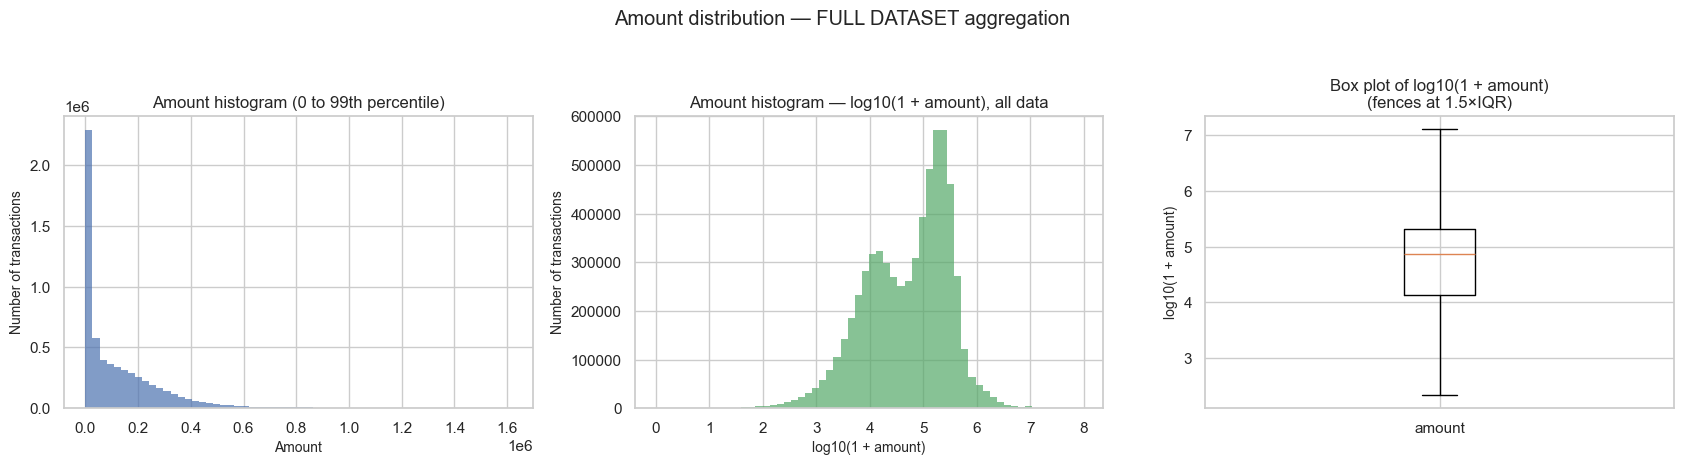

Figure saved -> reports\figures\05_amount_fraud_comparison.png


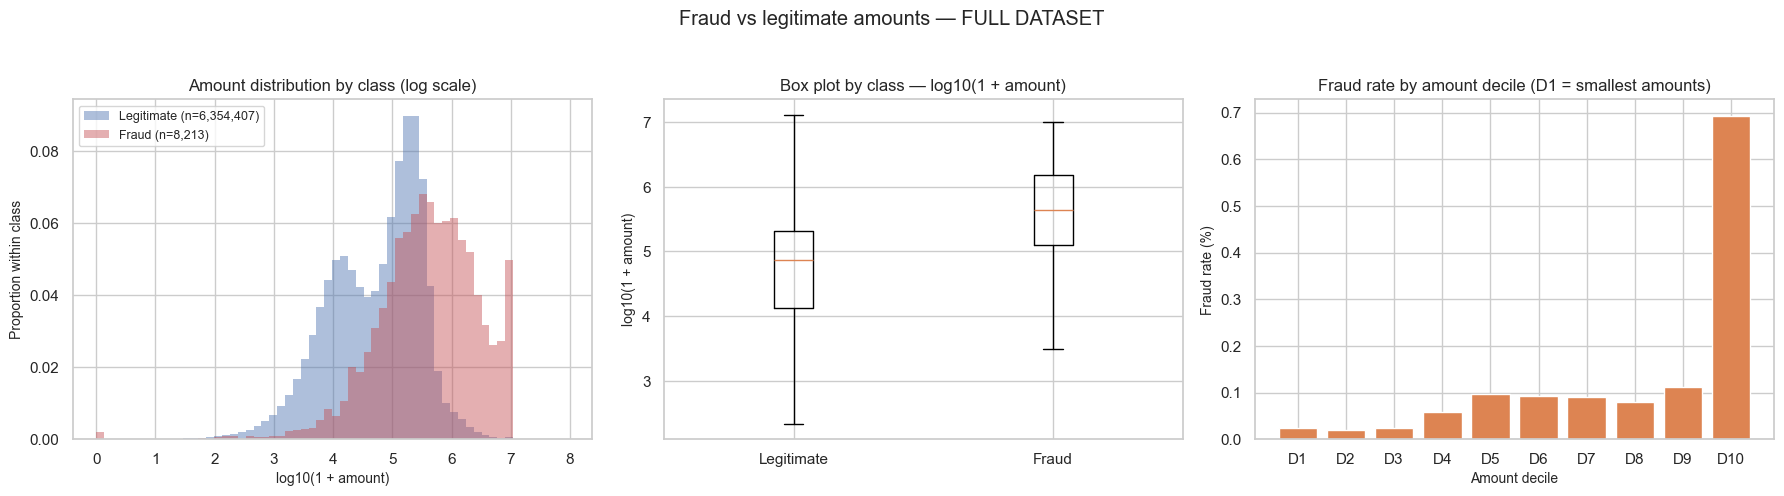

,Total Transactions,Fraud Transactions,Fraud Rate (%)
D1,636263,148,0.0233
D2,636261,128,0.0201
D3,636262,148,0.0233
D4,636262,365,0.0574
D5,636262,617,0.0970
D6,636262,592,0.0930
D7,636262,581,0.0913
D8,636262,503,0.0791
D9,636262,719,0.1130
D10,636262,4412,0.6934



Observation (auto-generated): median fraud amount = 441,423.44, median legitimate amount = 74,684.72 (ratio 5.91×).
This is a descriptive difference in distributions; it does not by itself prove predictive value.


In [9]:
def describe_series(s):
    """Descriptive statistics for one numeric Series."""
    s = s.dropna()
    q1, med, q3 = s.quantile([0.25, 0.5, 0.75])
    return {"count": int(s.count()), "mean": s.mean(), "median": med, "std": s.std(), "min": s.min(),
            "Q1 (25%)": q1, "Q3 (75%)": q3, "max": s.max(), "IQR": q3 - q1, "skewness": s.skew()}


def log_values(series):
    """log10(1 + x) of a numeric column as a float numpy array (negatives clipped to 0, NaN removed)."""
    v = series.to_numpy(dtype="float64")
    v = v[np.isfinite(v)]
    return np.log10(1.0 + np.clip(v, 0, None))


def box_stats(values, label, whis=1.5):
    """Box-plot statistics from full-data quantiles (no sampling). Whiskers = IQR fences clipped to data range."""
    v = values[np.isfinite(values)]
    q1, med, q3 = np.percentile(v, [25, 50, 75])
    iqr = q3 - q1
    return {"label": label, "q1": q1, "med": med, "q3": q3,
            "whislo": max(v.min(), q1 - whis * iqr), "whishi": min(v.max(), q3 + whis * iqr), "fliers": []}


def plot_hist_by_class(ax, df, col, bins=60, title=None):
    """Full-data histogram of log10(1+col); one normalised curve per class (class sizes differ enormously)."""
    top = log_values(df[col]).max()
    edges = np.linspace(0, top if top > 0 else 1, bins + 1)
    for cls in (0, 1):
        sub = log_values(df.loc[df[TARGET] == cls, col])
        if len(sub) == 0:
            continue
        counts, _ = np.histogram(sub, bins=edges)
        ax.stairs(counts / counts.sum(), edges, fill=True, alpha=0.45, color=COLORS[cls],
                  label=f"{CLASS_NAMES[cls]} (n={len(sub):,})")
    ax.set_xlabel(f"log10(1 + {col})")
    ax.set_ylabel("Proportion within class")
    ax.set_title(title or f"{col}: distribution by class")
    ax.legend()


if cols_present(df, ["amount"], "Amount analysis"):
    rows = {"All transactions": describe_series(df["amount"])}
    if HAS_TARGET:
        rows["Legitimate (0)"] = describe_series(df.loc[df[TARGET] == 0, "amount"])
        rows["Fraud (1)"] = describe_series(df.loc[df[TARGET] == 1, "amount"])
    amount_summary = pd.DataFrame(rows).T
    TABLES["amount_summary.csv"] = amount_summary
    display(amount_summary)

    amt_stats = rows["All transactions"]
    FINDINGS["amount_stats"] = amt_stats
    if HAS_TARGET:
        FINDINGS["amount_fraud_median"] = rows["Fraud (1)"]["median"]
        FINDINGS["amount_legit_median"] = rows["Legitimate (0)"]["median"]
        FINDINGS["amount_fraud_mean"] = rows["Fraud (1)"]["mean"]
        FINDINGS["amount_legit_mean"] = rows["Legitimate (0)"]["mean"]

    # Extreme values (kept, never removed)
    p999 = df["amount"].quantile(0.999)
    print(f"99.9th percentile of amount: {p999:,.2f}   |   maximum: {amt_stats['max']:,.2f}")
    show_cols = [c for c in ["step", "type", "amount", "nameOrig", "nameDest", TARGET] if c in df.columns]
    md("**10 largest transactions (kept in the data)**")
    display(df.nlargest(10, "amount")[show_cols])
    if HAS_TARGET:
        top_share = df.loc[df["amount"] >= p999, TARGET].mean() * 100
        print(f"Fraud rate among the top 0.1% largest amounts: {top_share:.3f}%  (overall: {FINDINGS['fraud_percentage']:.3f}%)")

    # ---- Figure 04: overall distribution ------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    p99 = df["amount"].quantile(0.99)
    counts, edges = np.histogram(df["amount"].to_numpy(), bins=60, range=(0, p99))
    axes[0].stairs(counts, edges, fill=True, color="#4C72B0", alpha=0.7)
    axes[0].set_title("Amount histogram (0 to 99th percentile)")
    axes[0].set_xlabel("Amount")
    axes[0].set_ylabel("Number of transactions")
    lv = log_values(df["amount"])
    counts, edges = np.histogram(lv, bins=60)
    axes[1].stairs(counts, edges, fill=True, color="#55A868", alpha=0.7)
    axes[1].set_title("Amount histogram — log10(1 + amount), all data")
    axes[1].set_xlabel("log10(1 + amount)")
    axes[1].set_ylabel("Number of transactions")
    bxp = box_stats(lv, "amount")
    axes[2].bxp([bxp], showfliers=False, vert=True)
    axes[2].set_title("Box plot of log10(1 + amount)\n(fences at 1.5×IQR)")
    axes[2].set_ylabel("log10(1 + amount)")
    fig.suptitle("Amount distribution — FULL DATASET aggregation", y=1.03)
    plt.tight_layout()
    save_fig(fig, "04_amount_distribution.png")
    plt.show()

    # ---- Figure 05: fraud vs legitimate ---------------------------------------------------
    if HAS_TARGET:
        fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
        plot_hist_by_class(axes[0], df, "amount", title="Amount distribution by class (log scale)")
        boxes = [box_stats(log_values(df.loc[df[TARGET] == c, "amount"]), CLASS_NAMES[c])
                 for c in (0, 1) if (df[TARGET] == c).any()]
        axes[1].bxp(boxes, showfliers=False)
        axes[1].set_title("Box plot by class — log10(1 + amount)")
        axes[1].set_ylabel("log10(1 + amount)")
        # fraud rate per amount decile
        dec = pd.qcut(df["amount"], 10, duplicates="drop")
        decile_tbl = df.groupby(dec, observed=True)[TARGET].agg(["size", "sum"])
        decile_tbl["Fraud Rate (%)"] = 100 * decile_tbl["sum"] / decile_tbl["size"]
        decile_tbl.index = [f"D{i + 1}" for i in range(len(decile_tbl))]
        axes[2].bar(decile_tbl.index, decile_tbl["Fraud Rate (%)"], color="#DD8452")
        axes[2].set_title("Fraud rate by amount decile (D1 = smallest amounts)")
        axes[2].set_xlabel("Amount decile")
        axes[2].set_ylabel("Fraud rate (%)")
        fig.suptitle("Fraud vs legitimate amounts — FULL DATASET", y=1.03)
        plt.tight_layout()
        save_fig(fig, "05_amount_fraud_comparison.png")
        plt.show()
        display(decile_tbl.rename(columns={"size": "Total Transactions", "sum": "Fraud Transactions"}))
        FINDINGS["amount_decile_table"] = decile_tbl

        med_ratio = FINDINGS["amount_fraud_median"] / FINDINGS["amount_legit_median"] if FINDINGS["amount_legit_median"] else np.nan
        print(f"\nObservation (auto-generated): median fraud amount = {FINDINGS['amount_fraud_median']:,.2f}, "
              f"median legitimate amount = {FINDINGS['amount_legit_median']:,.2f} (ratio {med_ratio:.2f}×).")
        print("This is a descriptive difference in distributions; it does not by itself prove predictive value.")

**Interpretation.** `amount` is typically strongly right-skewed (see the skewness value), so the raw histogram is dominated by small values while a few huge values stretch the axis; the log-scale plot is far more readable. Compare the two class curves: where they separate, `amount` may carry signal; where they overlap, it will not separate the classes on its own.

**Relevance.** A `log_amount` feature is a candidate for Phase 3. Very large amounts are **not deleted** — tree models such as XGBoost are robust to scale and the tail may be exactly where fraud lives.

## SECTION 10 — Temporal Analysis (`step`)

**Purpose:** Understand the time axis: range, volume and fraud over time.
**Relevance:** Everything in the final system is time-ordered: the train/validation/test split, the Kafka replay order, drift windows and retraining windows.

In PaySim, one `step` is documented as **one simulated hour** (so ≈ 744 steps ≈ 30 days). We treat `step` as an ordered temporal variable and derive **EDA-only** columns `eda_hour_of_day`, `eda_day`, `eda_week` (step 1 is assumed to be hour 0 of day 0). These are *relative to the simulation start*, not real clock times, and the raw `step` column is left untouched.

Minimum step : 1
Maximum step : 743
Unique steps : 743  (max - min + 1 = 743; gaps: 0)
Approximate simulated days: 31.0
Is the file already sorted by step? True


,count,mean,std,min,25%,50%,75%,max
step,743.0000,372.0000,214.6299,1.0000,186.5000,372.0000,557.5000,743.0000
Total Transactions,743.0000,"8,563.4186","13,388.6932",2.0000,12.0000,529.0000,"12,317.0000","51,352.0000"
Fraud Transactions,743.0000,11.0538,4.9986,0.0000,8.0000,10.0000,14.0000,40.0000
Fraud Rate (%),743.0000,43.9253,48.9562,0.0000,0.0749,1.9157,100.0000,100.0000


Transactions per step — mean: 8,563.4, min: 2, max: 51,352
Figure saved -> reports\figures\06_transaction_volume_over_time.png


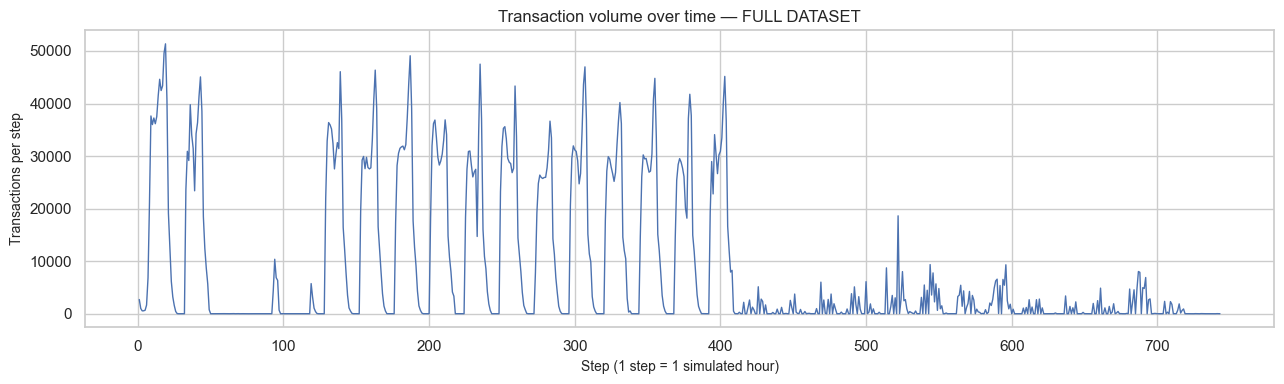

Figure saved -> reports\figures\07_fraud_volume_over_time.png


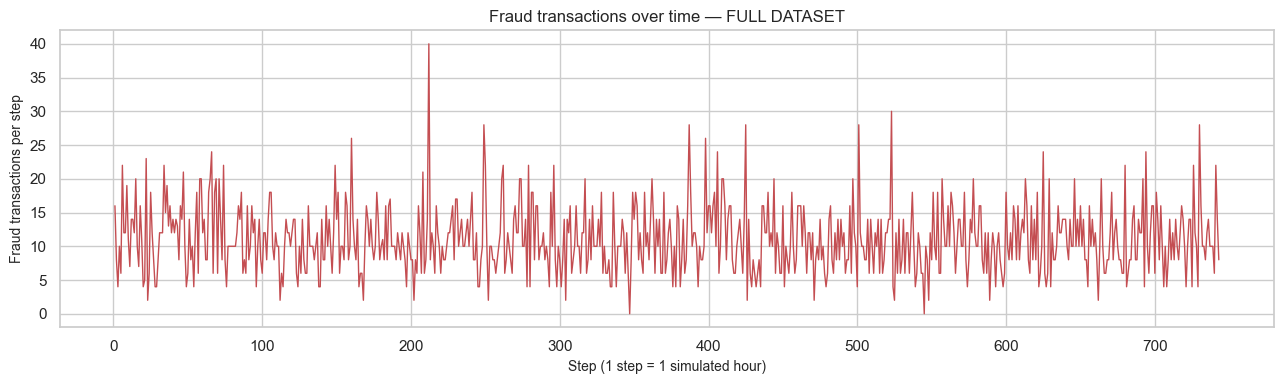

Figure saved -> reports\figures\08_fraud_rate_over_time.png


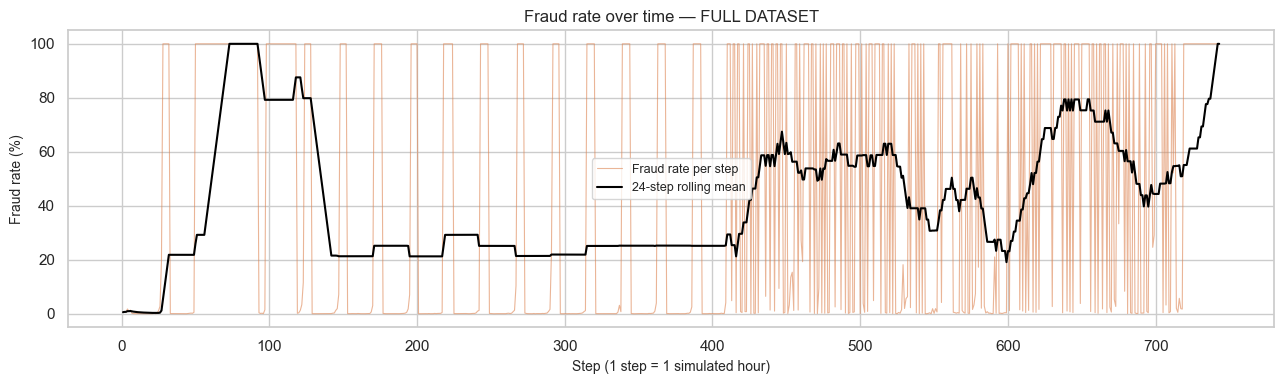

In [10]:
HOURS_PER_DAY = 24

if cols_present(df, ["step"], "Temporal analysis"):
    # EDA-only derived representations (small integer types; raw 'step' unchanged)
    df["eda_hour_of_day"] = ((df["step"] - 1) % HOURS_PER_DAY).astype("int8")
    df["eda_day"] = ((df["step"] - 1) // HOURS_PER_DAY).astype("int16")
    df["eda_week"] = (df["eda_day"] // 7).astype("int16")

    step_min, step_max = int(df["step"].min()), int(df["step"].max())
    n_steps = int(df["step"].nunique())
    is_sorted = bool(df["step"].is_monotonic_increasing)
    print(f"Minimum step : {step_min}")
    print(f"Maximum step : {step_max}")
    print(f"Unique steps : {n_steps}  (max - min + 1 = {step_max - step_min + 1}; gaps: {step_max - step_min + 1 - n_steps})")
    print(f"Approximate simulated days: {(step_max - step_min + 1) / HOURS_PER_DAY:.1f}")
    print(f"Is the file already sorted by step? {is_sorted}")
    FINDINGS.update(step_min=step_min, step_max=step_max, n_steps=n_steps, sorted_by_step=is_sorted)

    if HAS_TARGET:
        g = df.groupby("step")[TARGET].agg(["size", "sum"])
        step_tbl = pd.DataFrame({"step": g.index, "Total Transactions": g["size"].to_numpy(),
                                 "Fraud Transactions": g["sum"].to_numpy().astype(int)})
        step_tbl["Fraud Rate (%)"] = 100 * step_tbl["Fraud Transactions"] / step_tbl["Total Transactions"]
    else:
        vc = df["step"].value_counts().sort_index()
        step_tbl = pd.DataFrame({"step": vc.index, "Total Transactions": vc.to_numpy()})
    FINDINGS["step_table"] = step_tbl
    TABLES["temporal_analysis.csv"] = step_tbl
    display(step_tbl.describe().T)
    print(f"Transactions per step — mean: {step_tbl['Total Transactions'].mean():,.1f}, "
          f"min: {step_tbl['Total Transactions'].min():,}, max: {step_tbl['Total Transactions'].max():,}")

    # Figure 06: volume
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(step_tbl["step"], step_tbl["Total Transactions"], color="#4C72B0", lw=1)
    ax.set_title("Transaction volume over time — FULL DATASET")
    ax.set_xlabel("Step (1 step = 1 simulated hour)")
    ax.set_ylabel("Transactions per step")
    plt.tight_layout()
    save_fig(fig, "06_transaction_volume_over_time.png")
    plt.show()

    if HAS_TARGET:
        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(step_tbl["step"], step_tbl["Fraud Transactions"], color=COLORS[1], lw=1)
        ax.set_title("Fraud transactions over time — FULL DATASET")
        ax.set_xlabel("Step (1 step = 1 simulated hour)")
        ax.set_ylabel("Fraud transactions per step")
        plt.tight_layout()
        save_fig(fig, "07_fraud_volume_over_time.png")
        plt.show()

        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(step_tbl["step"], step_tbl["Fraud Rate (%)"], color="#DD8452", lw=0.8, alpha=0.6, label="Fraud rate per step")
        ax.plot(step_tbl["step"], step_tbl["Fraud Rate (%)"].rolling(HOURS_PER_DAY, min_periods=1).mean(), color="black",
                lw=1.5, label=f"{HOURS_PER_DAY}-step rolling mean")
        ax.set_title("Fraud rate over time — FULL DATASET")
        ax.set_xlabel("Step (1 step = 1 simulated hour)")
        ax.set_ylabel("Fraud rate (%)")
        ax.legend()
        plt.tight_layout()
        save_fig(fig, "08_fraud_rate_over_time.png")
        plt.show()

**Interpretation.** The volume plot shows whether the simulated activity has a repeating (e.g. daily) rhythm. The fraud-volume plot shows whether fraud follows that same rhythm or is spread differently. The fraud **rate** = fraud ÷ total in that step, so it can rise simply because total volume falls even when fraud volume is unchanged — always read the rate together with the two volume plots.

**Relevance.** The step range defines the simulated timeline that will be replayed through Kafka. Derived hour/day representations are only *candidate* features and are noted in Section 27.

## SECTION 11 — Temporal Fraud Patterns

**Purpose:** Summarise fraud by simulated day and by hour-of-day; look for spikes, unusual periods and changing concentration.
**Relevance:** Informs the choice of reference/recent windows for drift monitoring.

> **Important:** what follows are *exploratory temporal observations*. They are **not** a formal concept-drift finding. Statistical drift detection is implemented in a later phase.

**By simulated week**

,Time Period (week),Total Transactions,Fraud Transactions,Fraud Rate (%)
0,0,1930180,1904,0.0986
1,1,2854595,1863,0.0653
2,2,1279261,1854,0.1449
3,3,232135,1792,0.7720
4,4,66449,800,1.2039


**By simulated day**

,Time Period (day),Total Transactions,Fraud Transactions,Fraud Rate (%)
0,0,574255,271,0.0472
1,1,455238,309,0.0679
2,2,1070,310,28.9720
3,3,28240,262,0.9278
4,4,9789,252,2.5743
5,5,441005,228,0.0517
6,6,420583,272,0.0647
7,7,449637,278,0.0618
8,8,417919,255,0.0610
9,9,392945,282,0.0718


**By hour-of-day (relative to simulation start)**

,Hour of day (relative),Total Transactions,Fraud Transactions,Fraud Rate (%)
0,0,27111,358,1.3205
1,1,9018,372,4.1251
2,2,2007,326,16.2431
3,3,1241,274,22.0790
4,4,1641,366,22.3035
5,5,3420,358,10.4678
6,6,8988,328,3.6493
7,7,26915,368,1.3673
8,8,283518,341,0.1203
9,9,425729,375,0.0881


Figure saved -> reports\figures\13_temporal_fraud_patterns.png


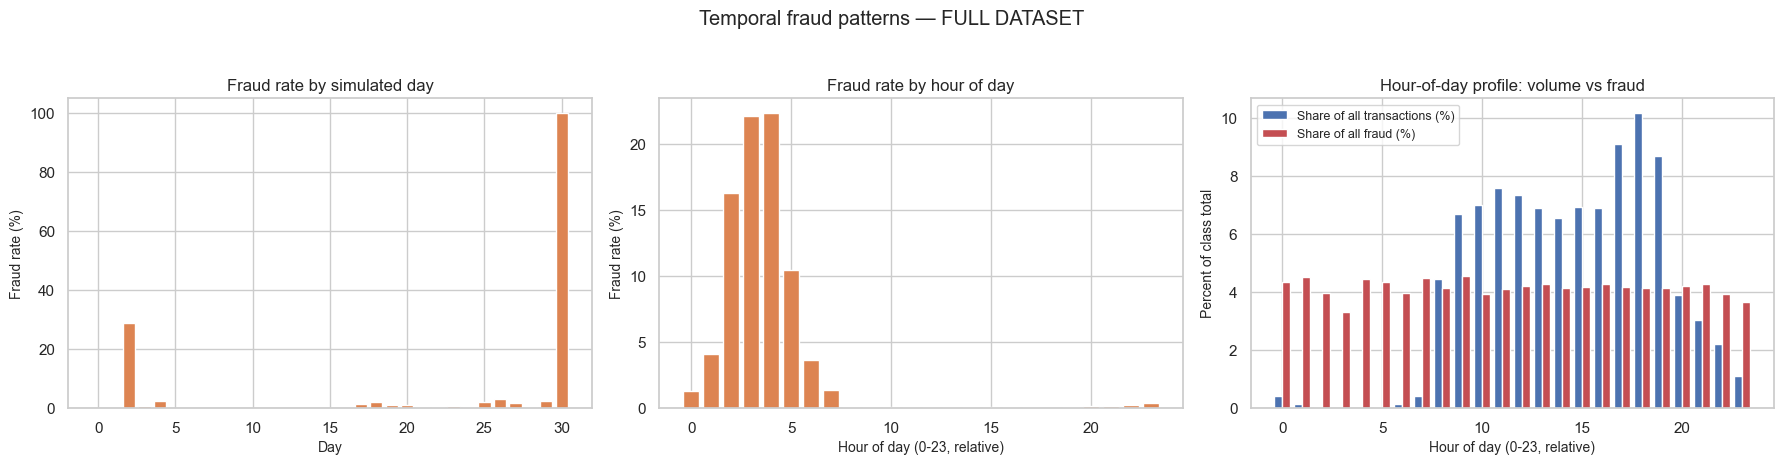


Steps whose fraud rate exceeds mean + 3·std of all steps (190.794%): 0
Highest hour-of-day fraud rate: hour 4 (22.303%);  lowest: hour 18 (0.053%).
These are exploratory observations, NOT a formal concept-drift finding.


In [12]:
if HAS["step"] and HAS_TARGET:
    g = df.groupby("eda_day")[TARGET].agg(["size", "sum"])
    day_tbl = pd.DataFrame({"Time Period (day)": g.index, "Total Transactions": g["size"].to_numpy(),
                            "Fraud Transactions": g["sum"].to_numpy().astype(int)})
    day_tbl["Fraud Rate (%)"] = 100 * day_tbl["Fraud Transactions"] / day_tbl["Total Transactions"]

    g = df.groupby("eda_hour_of_day")[TARGET].agg(["size", "sum"])
    hour_tbl = pd.DataFrame({"Hour of day (relative)": g.index, "Total Transactions": g["size"].to_numpy(),
                             "Fraud Transactions": g["sum"].to_numpy().astype(int)})
    hour_tbl["Fraud Rate (%)"] = 100 * hour_tbl["Fraud Transactions"] / hour_tbl["Total Transactions"]

    g = df.groupby("eda_week")[TARGET].agg(["size", "sum"])
    week_tbl = pd.DataFrame({"Time Period (week)": g.index, "Total Transactions": g["size"].to_numpy(),
                             "Fraud Transactions": g["sum"].to_numpy().astype(int)})
    week_tbl["Fraud Rate (%)"] = 100 * week_tbl["Fraud Transactions"] / week_tbl["Total Transactions"]

    FINDINGS.update(day_table=day_tbl, hour_table=hour_tbl, week_table=week_tbl)
    TABLES["temporal_analysis_by_day.csv"] = day_tbl
    TABLES["temporal_analysis_by_hour.csv"] = hour_tbl
    md("**By simulated week**")
    display(week_tbl)
    md("**By simulated day**")
    display(day_tbl)
    md("**By hour-of-day (relative to simulation start)**")
    display(hour_tbl)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    axes[0].bar(day_tbl["Time Period (day)"], day_tbl["Fraud Rate (%)"], color="#DD8452")
    axes[0].set_title("Fraud rate by simulated day")
    axes[0].set_xlabel("Day")
    axes[0].set_ylabel("Fraud rate (%)")
    axes[1].bar(hour_tbl["Hour of day (relative)"], hour_tbl["Fraud Rate (%)"], color="#DD8452")
    axes[1].set_title("Fraud rate by hour of day")
    axes[1].set_xlabel("Hour of day (0-23, relative)")
    axes[1].set_ylabel("Fraud rate (%)")
    ax2 = axes[2]
    ax2.bar(hour_tbl["Hour of day (relative)"] - 0.2, hour_tbl["Total Transactions"] / hour_tbl["Total Transactions"].sum() * 100,
            width=0.4, color=COLORS[0], label="Share of all transactions (%)")
    ax2.bar(hour_tbl["Hour of day (relative)"] + 0.2, hour_tbl["Fraud Transactions"] / max(hour_tbl["Fraud Transactions"].sum(), 1) * 100,
            width=0.4, color=COLORS[1], label="Share of all fraud (%)")
    ax2.set_title("Hour-of-day profile: volume vs fraud")
    ax2.set_xlabel("Hour of day (0-23, relative)")
    ax2.set_ylabel("Percent of class total")
    ax2.legend()
    fig.suptitle("Temporal fraud patterns — FULL DATASET", y=1.03)
    plt.tight_layout()
    save_fig(fig, "13_temporal_fraud_patterns.png")
    plt.show()

    # Simple, transparent "unusual period" flags (descriptive only): rate > mean + 3*std of the per-step rates
    r = FINDINGS["step_table"]["Fraud Rate (%)"]
    cutoff = r.mean() + 3 * r.std()
    spikes = FINDINGS["step_table"][r > cutoff]
    print(f"\nSteps whose fraud rate exceeds mean + 3·std of all steps ({cutoff:.3f}%): {len(spikes)}")
    if len(spikes):
        display(spikes.head(10))
    hi = hour_tbl.sort_values("Fraud Rate (%)", ascending=False).iloc[0]
    lo = hour_tbl.sort_values("Fraud Rate (%)").iloc[0]
    print(f"Highest hour-of-day fraud rate: hour {int(hi.iloc[0])} ({hi['Fraud Rate (%)']:.3f}%);  "
          f"lowest: hour {int(lo.iloc[0])} ({lo['Fraud Rate (%)']:.3f}%).")
    FINDINGS["hour_rate_max"] = float(hi["Fraud Rate (%)"])
    FINDINGS["hour_rate_min"] = float(lo["Fraud Rate (%)"])
    FINDINGS["peak_fraud_hour"] = int(hi.iloc[0])
    print("These are exploratory observations, NOT a formal concept-drift finding.")
else:
    print("[SKIPPED] Temporal fraud patterns: requires 'step' and 'isFraud'.")

**Interpretation.** Look for (a) days whose fraud rate stands out, (b) hours of the day where fraud's share is larger than the share of overall traffic (a sign that fraud does not follow legitimate traffic patterns), and (c) whether the fraud volume is stable over the whole timeline. The "mean + 3·std" line is only a simple descriptive marker for unusual steps — it is not a statistical test.

**Relevance.** If fraud is spread across the whole timeline, a chronological split will give all of train/validation/test some fraud (checked numerically in Section 26). Hour-of-day may be a useful (but simulator-specific) candidate feature. Formal distribution-shift tests come later.

## SECTION 12 — Transaction Type × Time

**Purpose:** See whether the type mix and the type-specific fraud rate change over time.
**Relevance:** Guides type-specific behavioural features and per-type drift monitoring.

Figure saved -> reports\figures\09_type_time_heatmap.png


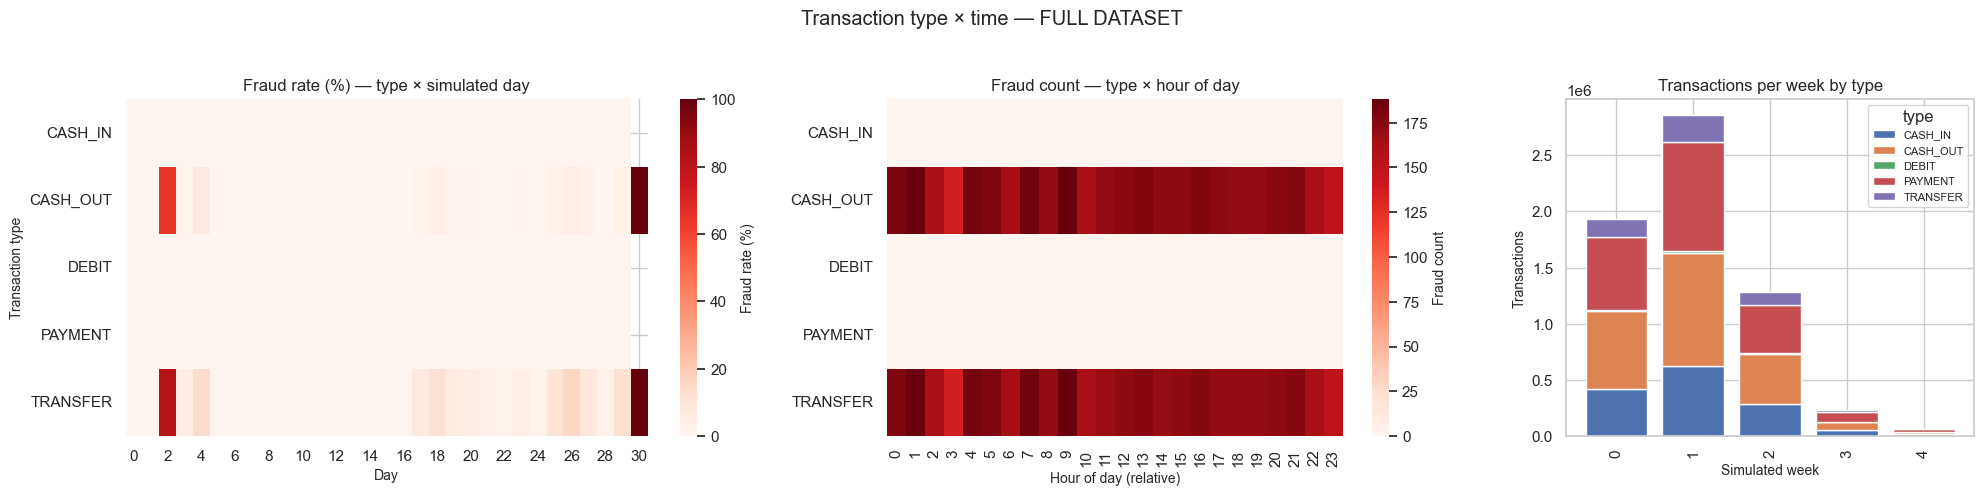

Types with fraud on at least one day: ['CASH_OUT', 'TRANSFER']
Days in which those types show fraud : 31 of 31

Descriptive pattern check: type share of traffic in the first vs last simulated week


type,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
eda_week,,,,,
0,21.9600,35.6550,0.6600,33.4560,8.2690
4,22.7260,33.3310,0.8830,33.2810,9.7790


In [13]:
if HAS["type"] and HAS["step"] and HAS_TARGET:
    g = df.groupby(["type", "eda_day"], observed=True)[TARGET].agg(["size", "sum"])
    g["rate"] = 100 * g["sum"] / g["size"]
    rate_day = g["rate"].unstack("eda_day")

    g2 = df.groupby(["type", "eda_hour_of_day"], observed=True)[TARGET].agg(["size", "sum"])
    fraud_hour = g2["sum"].unstack("eda_hour_of_day").fillna(0).astype(int)

    vol_week = df.groupby(["eda_week", "type"], observed=True).size().unstack("type").fillna(0)

    fig, axes = plt.subplots(1, 3, figsize=(20, 4.8), gridspec_kw={"width_ratios": [1.6, 1.4, 1]})
    sns.heatmap(rate_day, cmap="Reds", ax=axes[0], cbar_kws={"label": "Fraud rate (%)"})
    axes[0].set_title("Fraud rate (%) — type × simulated day")
    axes[0].set_xlabel("Day")
    axes[0].set_ylabel("Transaction type")
    sns.heatmap(fraud_hour, cmap="Reds", ax=axes[1], cbar_kws={"label": "Fraud count"})
    axes[1].set_title("Fraud count — type × hour of day")
    axes[1].set_xlabel("Hour of day (relative)")
    axes[1].set_ylabel("")
    vol_week.plot(kind="bar", stacked=True, ax=axes[2], width=0.8)
    axes[2].set_title("Transactions per week by type")
    axes[2].set_xlabel("Simulated week")
    axes[2].set_ylabel("Transactions")
    axes[2].legend(title="type", fontsize=8)
    fig.suptitle("Transaction type × time — FULL DATASET", y=1.03)
    plt.tight_layout()
    save_fig(fig, "09_type_time_heatmap.png")
    plt.show()

    type_time_tbl = g.reset_index().rename(columns={"size": "Total Transactions", "sum": "Fraud Transactions",
                                                    "rate": "Fraud Rate (%)"})
    TABLES["transaction_type_by_day.csv"] = type_time_tbl
    active = type_time_tbl[type_time_tbl["Fraud Transactions"] > 0]
    print("Types with fraud on at least one day:", sorted(active["type"].astype(str).unique().tolist()))
    print("Days in which those types show fraud :", int(active["eda_day"].nunique()), "of", int(df["eda_day"].nunique()))
    print("\nDescriptive pattern check: type share of traffic in the first vs last simulated week")
    first_w, last_w = vol_week.index.min(), vol_week.index.max()
    share = (vol_week.div(vol_week.sum(axis=1), axis=0) * 100).loc[[first_w, last_w]]
    display(share.round(3))
else:
    print("[SKIPPED] Type × time analysis: requires 'type', 'step' and 'isFraud'.")

**Interpretation.** In the heatmaps, empty/light cells mean little or no fraud for that type in that period. Identify (1) which types carry fraud at all, (2) whether their fraud rate is steady or bursty across days, and (3) whether the *type mix* of traffic shifts across weeks.

**Relevance to feature engineering.** If fraud is confined to a few types, interaction-style features (e.g. `type × amount ratio`) can be tested in Phase 3, and per-type behavioural profiles may matter more than global ones. These are hypotheses to test, not conclusions.

## SECTION 13 — Sender / Origin Account Analysis (`nameOrig`)

**Purpose:** Study sender behaviour: how many senders, how often they transact, how much, and how fraud is spread across them.
**Relevance:** Decides whether *behavioural history features* (velocity, average amount, time since previous transaction) are even feasible for this dataset.

**Why raw account IDs are not model features.** `nameOrig` is a *high-cardinality identifier*. One-hot encoding it would create millions of columns, and even label-encoding would only let a model memorise IDs it has already seen — useless for new accounts in a live stream. The right approach is to derive **behavioural features** from an account's *past* transactions (e.g. `transactions_last_1h`, `transactions_last_24h`, `average_amount`, `amount_deviation`, `transaction_frequency`, `time_since_previous_transaction`). Those are only *listed as candidates* here; they are not implemented.

*Implementation note (memory):* accounts are converted to integer codes with `pd.factorize` and aggregated with a single `groupby` on the integer codes. This is FULL-DATASET analysis and avoids grouping directly on millions of strings.

,Value
Unique senders,"6,353,307.0000"
senders with >1 transaction,"9,298.0000"
% of senders with >1 transaction,0.1463
Mean transactions per account,1.0015
Median transactions per account,1.0000
Max transactions by one account,3.0000
Mean of per-account mean amount,"179,857.0856"
Median of per-account median amount,"74,973.8100"
Max single-account max amount,"92,445,516.6400"
% of all transactions made by repeated accounts,0.2925


**Highest-frequency senders**

,txn_count,total_amount,max_amount,mean_amount,fraud_count,median_amount
nameOrig,,,,,,
C1902386530,3,"763,712.7900","487,055.2800","254,570.9300",0,"246,956.9500"
C363736674,3,"68,726.3300","43,108.6200","22,908.7767",0,"17,597.5700"
C545315117,3,"2,485,461.6400","2,299,195.7600","828,487.2133",0,"182,907.7100"
C724452879,3,"838,815.3000","346,225.5900","279,605.1000",0,"303,432.5400"
C1784010646,3,"436,700.2500","366,563.7300","145,566.7500",0,"51,324.7700"
C1677795071,3,"244,735.3800","226,611.9000","81,578.4600",0,"9,837.7700"
C1462946854,3,"166,791.4300","113,062.2500","55,597.1433",0,"34,253.4500"
C1999539787,3,"290,555.0100","242,801.7400","96,851.6700",0,"28,653.2500"
C2098525306,3,"378,102.2200","280,613.0500","126,034.0733",0,"49,605.5500"


**Highest total-value senders**

,txn_count,total_amount,max_amount,mean_amount,fraud_count,median_amount
nameOrig,,,,,,
C1715283297,1,"92,445,516.6400","92,445,516.6400","92,445,516.6400",0,"92,445,516.6400"
C2127282686,1,"73,823,490.3600","73,823,490.3600","73,823,490.3600",0,"73,823,490.3600"
C2044643633,1,"71,172,480.4200","71,172,480.4200","71,172,480.4200",0,"71,172,480.4200"
C1425667947,1,"69,886,731.3000","69,886,731.3000","69,886,731.3000",0,"69,886,731.3000"
C1584456031,1,"69,337,316.2700","69,337,316.2700","69,337,316.2700",0,"69,337,316.2700"
C811810230,1,"67,500,761.2900","67,500,761.2900","67,500,761.2900",0,"67,500,761.2900"
C420748282,1,"66,761,272.2100","66,761,272.2100","66,761,272.2100",0,"66,761,272.2100"
C1139847449,1,"64,234,448.1900","64,234,448.1900","64,234,448.1900",0,"64,234,448.1900"
C300140823,1,"63,847,992.5800","63,847,992.5800","63,847,992.5800",0,"63,847,992.5800"


**Senders with the most fraud transactions**

,txn_count,total_amount,max_amount,mean_amount,fraud_count,median_amount
nameOrig,,,,,,
C1498185758,2,"634,612.7600","566,156.4200","317,306.3800",1,"317,306.3800"
C686187434,2,"6,363,943.3600","6,188,514.8100","3,181,971.6800",1,"3,181,971.6800"
C803411135,2,"340,470.2000","176,257.0300","170,235.1000",1,"170,235.1000"
C1044518032,2,"98,996.5800","78,603.4600","49,498.2900",1,"49,498.2900"
C1885333477,2,"974,415.9300","815,297.9000","487,207.9650",1,"487,207.9650"
C432562518,2,"243,753.9700","171,788.8200","121,876.9850",1,"121,876.9850"
C1882162040,2,"261,285.5900","133,837.9100","130,642.7950",1,"130,642.7950"
C1118399210,2,"309,694.4600","157,652.3000","154,847.2300",1,"154,847.2300"
C431038121,2,"391,826.7300","328,202.6500","195,913.3650",1,"195,913.3650"


**Sender transaction-count distribution: senders that appear in fraud vs all senders**

,All senders,Senders involved in fraud
count,"6,353,307.0000","8,213.0000"
mean,1.0015,1.0034
std,0.0383,0.0583
min,1.0000,1.0000
25%,1.0000,1.0000
50%,1.0000,1.0000
75%,1.0000,1.0000
max,3.0000,2.0000


Figure saved -> reports\figures\14_sender_behavior.png


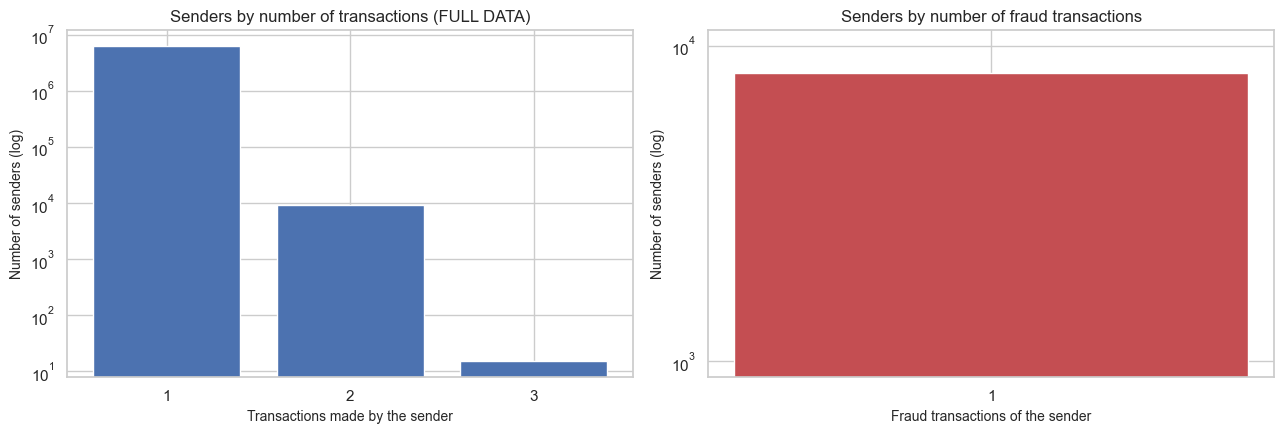

Observation (auto-generated): 0.146% of senders make more than one transaction; 0.293% of all transactions come from such senders.
This determines how much per-sender history is available for behavioural features.


In [14]:
def account_profile(df, id_col):
    """
    Aggregate transactions per account (full data).
    Returns (profile, per_txn_count):
      * profile        - one row per account (index = account ID)
      * per_txn_count  - numpy array aligned with df rows: how many transactions the row's account has in total
    """
    codes, uniques = pd.factorize(df[id_col])
    valid = codes >= 0
    data = {"code": codes[valid], "amount": df["amount"].to_numpy()[valid]}
    if HAS_TARGET:
        data["fraud"] = df[TARGET].to_numpy()[valid]
    tmp = pd.DataFrame(data)
    grp = tmp.groupby("code", sort=True)
    prof = grp["amount"].agg(txn_count="size", total_amount="sum", max_amount="max")
    prof["mean_amount"] = prof["total_amount"] / prof["txn_count"]
    if HAS_TARGET:
        prof["fraud_count"] = grp["fraud"].sum().astype(int)
    # median only for accounts with more than one transaction (single-transaction median = the amount itself)
    repeated_codes = prof.index[prof["txn_count"] > 1]
    prof["median_amount"] = prof["mean_amount"]        # exact for single-transaction accounts
    if len(repeated_codes):
        sub = tmp[tmp["code"].isin(repeated_codes)]
        prof.loc[repeated_codes, "median_amount"] = sub.groupby("code")["amount"].median()
    per_txn = np.zeros(len(df), dtype="int64")
    per_txn[valid] = prof["txn_count"].to_numpy()[codes[valid]]
    prof.index = uniques.take(prof.index.to_numpy())
    prof.index.name = id_col
    return prof, per_txn


def summarise_profile(prof, per_txn, label):
    """Summary metrics for an account profile."""
    n_acc = len(prof)
    repeated = int((prof["txn_count"] > 1).sum())
    out = {f"Unique {label}": n_acc,
           f"{label} with >1 transaction": repeated,
           f"% of {label} with >1 transaction": pct(repeated, n_acc),
           "Mean transactions per account": prof["txn_count"].mean(),
           "Median transactions per account": prof["txn_count"].median(),
           "Max transactions by one account": int(prof["txn_count"].max()),
           "Mean of per-account mean amount": prof["mean_amount"].mean(),
           "Median of per-account median amount": prof["median_amount"].median(),
           "Max single-account max amount": prof["max_amount"].max(),
           "% of all transactions made by repeated accounts": pct((per_txn > 1).sum(), len(per_txn))}
    if HAS_TARGET:
        fr = int((prof["fraud_count"] > 0).sum())
        out.update({f"{label} involved in fraud": fr,
                    f"% of {label} involved in fraud": pct(fr, n_acc),
                    f"{label} with >=2 fraud transactions": int((prof["fraud_count"] >= 2).sum()),
                    "Max fraud transactions by one account": int(prof["fraud_count"].max())})
    return out


if cols_present(df, ["nameOrig", "amount"], "Sender analysis"):
    sender_prof, sender_per_txn = account_profile(df, "nameOrig")
    sender_summary = pd.DataFrame(summarise_profile(sender_prof, sender_per_txn, "senders"), index=["Value"]).T
    TABLES["sender_analysis.csv"] = sender_summary
    FINDINGS["sender_summary"] = summarise_profile(sender_prof, sender_per_txn, "senders")
    display(sender_summary)

    md("**Highest-frequency senders**")
    display(sender_prof.sort_values("txn_count", ascending=False).head(10))
    md("**Highest total-value senders**")
    display(sender_prof.sort_values("total_amount", ascending=False).head(10))
    if HAS_TARGET and (sender_prof["fraud_count"] > 0).any():
        md("**Senders with the most fraud transactions**")
        display(sender_prof.sort_values(["fraud_count", "txn_count"], ascending=False).head(10))
    if HAS_TARGET:
        md("**Sender transaction-count distribution: senders that appear in fraud vs all senders**")
        display(pd.DataFrame({"All senders": sender_prof["txn_count"].describe(),
                              "Senders involved in fraud": sender_prof.loc[sender_prof["fraud_count"] > 0, "txn_count"].describe()}))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    vc = sender_prof["txn_count"].value_counts().sort_index()
    axes[0].bar(vc.index.astype(str), vc.values, color="#4C72B0")
    axes[0].set_yscale("log")
    axes[0].set_title("Senders by number of transactions (FULL DATA)")
    axes[0].set_xlabel("Transactions made by the sender")
    axes[0].set_ylabel("Number of senders (log)")
    if HAS_TARGET and (sender_prof["fraud_count"] > 0).any():
        vf = sender_prof.loc[sender_prof["fraud_count"] > 0, "fraud_count"].value_counts().sort_index()
        axes[1].bar(vf.index.astype(str), vf.values, color=COLORS[1])
        axes[1].set_yscale("log")
        axes[1].set_title("Senders by number of fraud transactions")
        axes[1].set_xlabel("Fraud transactions of the sender")
        axes[1].set_ylabel("Number of senders (log)")
    else:
        axes[1].text(0.5, 0.5, "No sender-level fraud data available", ha="center")
    plt.tight_layout()
    save_fig(fig, "14_sender_behavior.png")
    plt.show()
    s = FINDINGS["sender_summary"]
    print(f"Observation (auto-generated): {s['% of senders with >1 transaction']:.3f}% of senders make more than one transaction; "
          f"{s['% of all transactions made by repeated accounts']:.3f}% of all transactions come from such senders.")
    print("This determines how much per-sender history is available for behavioural features.")
else:
    sender_prof = None

**Interpretation.** The key number is the share of senders with **more than one** transaction. If almost every sender appears exactly once, then per-sender rolling windows (`transactions_last_24h`, `time_since_previous_transaction`, `amount_deviation`) have almost no history to work with in *this* dataset — even though they would be essential in a real bank. This finding directly sets feature-engineering priorities in Section 27.

**Relevance.** In the streaming design, per-account features require **stateful** processing in Spark (state keyed by account); if history is absent in PaySim, we must be explicit about it in the project report.

## SECTION 14 — Destination Account Analysis (`nameDest`)

**Purpose:** The same analysis for recipients, plus a comparison of destination behaviour for fraud vs legitimate transactions.
**Relevance:** Recipient-side behaviour (how often an account *receives* money, whether it is new) is a classic fraud signal in real systems; we test whether PaySim supports it.

We also inspect the **first character of the account name** (`nameOrig[0]`, `nameDest[0]`) as an *account-category* hint. This is only a descriptive check of what the file contains — its meaning is not assumed.

,Value
Unique destinations,"2,722,362.0000"
destinations with >1 transaction,"459,658.0000"
% of destinations with >1 transaction,16.8845
Mean transactions per account,2.3372
Median transactions per account,1.0000
Max transactions by one account,113.0000
Mean of per-account mean amount,"59,621.8552"
Median of per-account median amount,"12,965.8750"
Max single-account max amount,"92,445,516.6400"
% of all transactions made by repeated accounts,64.4375


**Highest-frequency destinations**

,txn_count,total_amount,max_amount,mean_amount,fraud_count,median_amount
nameDest,,,,,,
C1286084959,113,"77,428,943.3100","21,300,322.5800","685,211.8877",0,"246,795.7500"
C985934102,109,"42,422,887.9800","2,975,990.3700","389,200.8072",0,"205,368.7800"
C665576141,105,"88,749,384.3800","23,105,862.4400","845,232.2322",0,"278,809.4500"
C2083562754,102,"53,073,938.7600","8,190,228.6300","520,332.7329",0,"207,538.9750"
C248609774,101,"40,680,160.9900","3,207,507.6200","402,773.8712",0,"213,560.3300"
C1590550415,101,"43,206,101.5900","2,545,478.0100","427,783.1841",0,"239,378.9200"
C451111351,99,"37,453,031.3900","2,887,748.9000","378,313.4484",0,"219,060.8600"
C1789550256,99,"177,885,264.6000","45,372,634.6300","1,796,820.8545",0,"278,051.9200"
C1360767589,98,"35,121,289.2700","2,283,519.9400","358,380.5028",0,"188,731.6200"


**Destinations with the most fraud transactions**

,txn_count,total_amount,max_amount,mean_amount,fraud_count,median_amount
nameDest,,,,,,
C803116137,77,"119,151,662.2500","33,751,577.0400","1,547,424.1851",2,"238,300.3800"
C410033330,48,"24,450,707.1300","7,299,230.3200","509,389.7319",2,"153,878.5500"
C185805228,47,"13,847,068.9300","2,594,904.2900","294,618.4879",2,"184,081.6600"
C2020337583,41,"7,611,259.3900","691,849.3000","185,640.4729",2,"131,447.7800"
C1193568854,37,"10,871,154.9500","2,355,287.9900","293,814.9986",2,"219,338.3900"
C1013511446,35,"22,226,171.1300","2,657,484.8100","635,033.4609",2,"328,650.7400"
C1655359478,34,"8,081,120.8300","1,534,009.9100","237,680.0244",2,"148,427.2900"
C200064275,33,"6,601,096.8800","895,351.6000","200,033.2388",2,"150,952.4000"
C904300960,32,"11,303,482.4500","1,975,326.6900","353,233.8266",2,"235,247.0450"


...

**Same view for the sender account**

,count,mean,median,max
Legitimate,6354407,1.0029,1.0000,3
Fraud,8213,1.0034,1.0000,2


**Account-name prefix (first character) — descriptive check**

,Column,Prefix,Transactions,Share (%),Fraud Transactions,Fraud Rate (%)
0,nameOrig,C,6362620,100.0000,8213,0.1291
1,nameDest,C,4211125,66.1854,8213,0.1950
2,nameDest,M,2151495,33.8146,0,0.0000


Figure saved -> reports\figures\15_destination_behavior.png


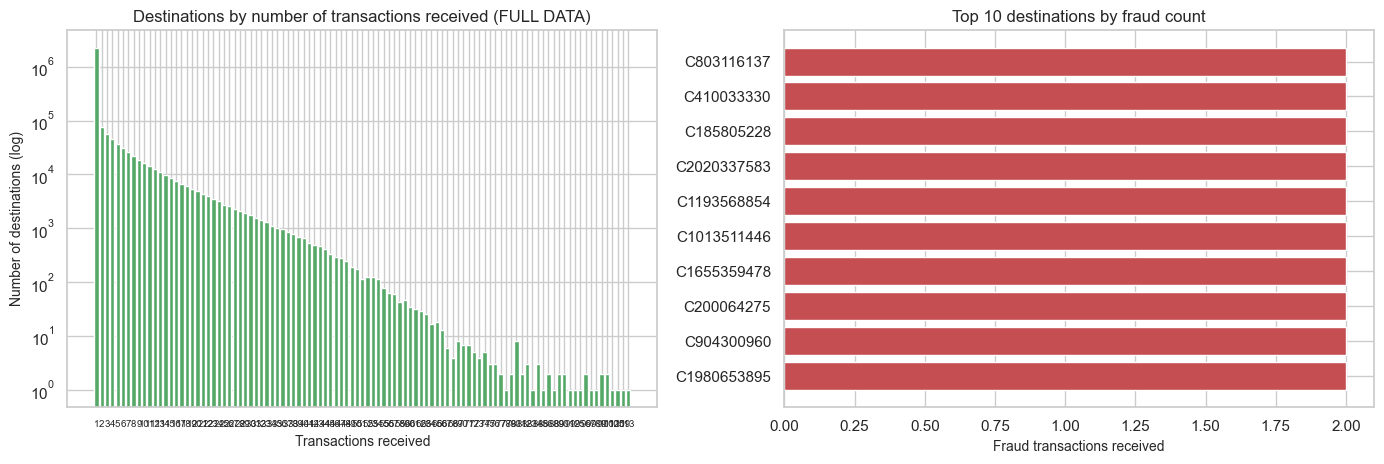

Observation (auto-generated): 16.885% of destinations receive more than one transaction; 64.438% of transactions go to such destinations.
Raw destination IDs are identifiers and must NOT be one-hot encoded.


In [15]:
if cols_present(df, ["nameDest", "amount"], "Destination analysis"):
    dest_prof, dest_per_txn = account_profile(df, "nameDest")
    dest_summary = pd.DataFrame(summarise_profile(dest_prof, dest_per_txn, "destinations"), index=["Value"]).T
    TABLES["destination_analysis.csv"] = dest_summary
    FINDINGS["dest_summary"] = summarise_profile(dest_prof, dest_per_txn, "destinations")
    display(dest_summary)

    md("**Highest-frequency destinations**")
    display(dest_prof.sort_values("txn_count", ascending=False).head(10))
    if HAS_TARGET and (dest_prof["fraud_count"] > 0).any():
        md("**Destinations with the most fraud transactions**")
        display(dest_prof.sort_values(["fraud_count", "txn_count"], ascending=False).head(10))

    if HAS_TARGET:
        # Destination frequency seen by each transaction (fraud vs legitimate) — uses the aligned per-row array
        cmp = pd.DataFrame({"dest_txn_count": dest_per_txn, "cls": df[TARGET].to_numpy()})
        comp_tbl = cmp.groupby("cls")["dest_txn_count"].agg(["count", "mean", "median", "max"])
        comp_tbl.index = [CLASS_NAMES.get(i, str(i)) for i in comp_tbl.index]
        rep_share = cmp.groupby("cls")["dest_txn_count"].apply(lambda s: 100 * (s > 1).mean())
        comp_tbl["% whose destination has >1 transaction"] = rep_share.to_numpy()
        md("**How busy is the destination account of each transaction? (fraud vs legitimate)**")
        display(comp_tbl)
        FINDINGS["dest_freq_by_class"] = comp_tbl
        del cmp
        # Sender equivalent
        if sender_prof is not None:
            cmp = pd.DataFrame({"c": sender_per_txn, "cls": df[TARGET].to_numpy()})
            comp_s = cmp.groupby("cls")["c"].agg(["count", "mean", "median", "max"])
            comp_s.index = [CLASS_NAMES.get(i, str(i)) for i in comp_s.index]
            FINDINGS["sender_freq_by_class"] = comp_s
            md("**Same view for the sender account**")
            display(comp_s)
            del cmp

    # Account-name prefix (descriptive)
    md("**Account-name prefix (first character) — descriptive check**")
    pref_rows = []
    for col in ("nameOrig", "nameDest"):
        if HAS[col]:
            p = df[col].astype("string").str[:1]
            vc = p.value_counts()
            for k, v in vc.items():
                row = {"Column": col, "Prefix": k, "Transactions": int(v), "Share (%)": pct(v, len(df))}
                if HAS_TARGET:
                    fr = int(df[TARGET].to_numpy()[(p == k).to_numpy(na_value=False)].sum())
                    row.update({"Fraud Transactions": fr, "Fraud Rate (%)": pct(fr, v)})
                pref_rows.append(row)
            del p
    prefix_tbl = pd.DataFrame(pref_rows)
    FINDINGS["prefix_table"] = prefix_tbl
    TABLES["account_prefix_analysis.csv"] = prefix_tbl
    display(prefix_tbl)

    if HAS_TARGET:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
        vc = dest_prof["txn_count"].value_counts().sort_index()
        axes[0].bar(vc.index.astype(str), vc.values, color="#55A868")
        axes[0].set_yscale("log")
        axes[0].set_title("Destinations by number of transactions received (FULL DATA)")
        axes[0].set_xlabel("Transactions received")
        axes[0].set_ylabel("Number of destinations (log)")
        axes[0].tick_params(axis="x", labelsize=7)
        topf = dest_prof.sort_values(["fraud_count", "txn_count"], ascending=False).head(10)
        if len(topf) and topf["fraud_count"].max() > 0:
            axes[1].barh(topf.index.astype(str)[::-1], topf["fraud_count"].to_numpy()[::-1], color=COLORS[1])
            axes[1].set_title("Top 10 destinations by fraud count")
            axes[1].set_xlabel("Fraud transactions received")
        else:
            axes[1].text(0.5, 0.5, "No destination-level fraud", ha="center")
        plt.tight_layout()
        save_fig(fig, "15_destination_behavior.png")
        plt.show()

    d = FINDINGS["dest_summary"]
    print(f"Observation (auto-generated): {d['% of destinations with >1 transaction']:.3f}% of destinations receive more than one "
          f"transaction; {d['% of all transactions made by repeated accounts']:.3f}% of transactions go to such destinations.")
    print("Raw destination IDs are identifiers and must NOT be one-hot encoded.")
else:
    dest_prof = None

**Interpretation.** Compare how "busy" the destination is for fraudulent vs legitimate transactions and inspect whether the account-name prefix separates account categories (and whether fraud appears in all of them). Note that recipient-side counts computed over the *entire* file use future transactions — they are for **understanding** only. Any production feature must be computed from **past** transactions only (Section 24).

**Relevance.** Recipient-side candidates (`recipient_frequency`, `new_recipient`) are prioritised in Section 27 according to how much repeated-destination behaviour this file really contains.

## SECTION 15 — Account Behaviour and Fraud Concentration

**Purpose:** Is fraud concentrated in a few accounts, or spread thinly? How is transaction volume concentrated across accounts?
**Relevance:** Determines whether account-level (graph/behaviour) features could work, and how much of the fraud any account-level rule could ever touch.

Statements below are descriptive only.

In [16]:
def concentration_metrics(prof, label):
    """Volume and fraud concentration for one role (sender/destination)."""
    n = len(prof)
    top1_n = max(int(np.ceil(0.01 * n)), 1)
    top_counts = prof["txn_count"].sort_values(ascending=False)
    out = {"Role": label, "Accounts": n,
           "Transactions from the top 1% busiest accounts (%)": pct(top_counts.head(top1_n).sum(), top_counts.sum()),
           "Busiest account: transactions": int(top_counts.iloc[0]),
           "Busiest account: share of all transactions (%)": pct(top_counts.iloc[0], top_counts.sum())}
    if HAS_TARGET:
        total_fraud = prof["fraud_count"].sum()
        fraud_acc = prof[prof["fraud_count"] > 0]
        out.update({"Accounts involved in fraud": len(fraud_acc),
                    "Accounts involved in fraud (% of accounts)": pct(len(fraud_acc), n),
                    "Fraud transactions carried by accounts with >=2 frauds (%)": pct(fraud_acc.loc[fraud_acc["fraud_count"] >= 2, "fraud_count"].sum(), total_fraud),
                    "Fraud share of the top 10 fraud accounts (%)": pct(fraud_acc["fraud_count"].sort_values(ascending=False).head(10).sum(), total_fraud),
                    "Fraud share of the top 1% fraud accounts (%)": pct(fraud_acc["fraud_count"].sort_values(ascending=False).head(max(int(np.ceil(0.01 * len(fraud_acc))), 1)).sum(), total_fraud) if len(fraud_acc) else 0.0})
    return out


conc_rows = []
if sender_prof is not None:
    conc_rows.append(concentration_metrics(sender_prof, "Sender (nameOrig)"))
if dest_prof is not None:
    conc_rows.append(concentration_metrics(dest_prof, "Destination (nameDest)"))

if conc_rows:
    conc_tbl = pd.DataFrame(conc_rows).set_index("Role").T
    TABLES["account_concentration.csv"] = conc_tbl
    FINDINGS["concentration"] = conc_tbl
    display(conc_tbl)

    if sender_prof is not None and dest_prof is not None:
        both = sender_prof.index.intersection(dest_prof.index)
        print(f"Accounts that appear both as a sender and as a destination: {len(both):,}")
        FINDINGS["accounts_in_both_roles"] = len(both)
        if HAS_TARGET:
            fraud_dest = dest_prof.index[dest_prof["fraud_count"] > 0]
            fraud_dest_also_sender = fraud_dest.intersection(sender_prof.index)
            print(f"Destination accounts that received fraud: {len(fraud_dest):,}; of these, "
                  f"{len(fraud_dest_also_sender):,} also appear as a sender in the file.")
            FINDINGS["fraud_dest_also_sender"] = len(fraud_dest_also_sender)
        del both

    print("\nObservation (auto-generated): the table above shows whether volume and fraud are concentrated in few accounts "
          "or spread widely. These are descriptive statements, not causal ones.")
else:
    print("[SKIPPED] Account behaviour: neither 'nameOrig' nor 'nameDest' analysis was available.")

Role,Sender (nameOrig),Destination (nameDest)
Accounts,"6,353,307.0000","2,722,362.0000"
Transactions from the top 1% busiest accounts (%),1.1449,14.3477
Busiest account: transactions,3.0000,113.0000
Busiest account: share of all transactions (%),0.0000,0.0018
Accounts involved in fraud,"8,213.0000","8,169.0000"
Accounts involved in fraud (% of accounts),0.1293,0.3001
Fraud transactions carried by accounts with >=2 frauds (%),0.0000,1.0715
Fraud share of the top 10 fraud accounts (%),0.1218,0.2435
Fraud share of the top 1% fraud accounts (%),1.0106,1.5342


Accounts that appear both as a sender and as a destination: 1,769
Destination accounts that received fraud: 8,169; of these, 18 also appear as a sender in the file.

Observation (auto-generated): the table above shows whether volume and fraud are concentrated in few accounts or spread widely. These are descriptive statements, not causal ones.


**Interpretation.** If fraud accounts each carry only one fraud transaction (small "≥2 frauds" share), then "repeat-offender" account features cannot be learned from this file. If a few destinations attract many frauds, recipient-side features may matter.

**Relevance.** This decides which account-level behavioural features deserve engineering effort in Phase 3, and whether they will be realistic when the stream is replayed.

## SECTION 16 — Balance Analysis

**Purpose:** Study `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest` and the balance changes.
**Relevance:** Balance fields look highly informative, but some describe the account **after** the transaction and may not be available when the prediction must be made (see Sections 24–25).

> **Do not treat balance fields as automatically safe model features.** "Old" balances describe the state before the transaction; "new" balances describe the state after it. A real-time model that scores a transaction *before* it completes cannot use post-transaction values.

*Statistics = FULL DATASET. Histograms/box plots = full-data aggregation (log10(1+x) scale).*

,count,mean,median,std,min,Q1 (25%),Q3 (75%),max,IQR,skewness,zero (%),missing (%)
column,,,,,,,,,,,,
oldbalanceOrg,6362620,"833,883.1041","14,208.0000","2,888,242.6730",0.0000,0.0000,"107,315.1750","59,585,040.3700","107,315.1750",5.2491,33.0438,0.0000
newbalanceOrig,6362620,"855,113.6686",0.0000,"2,924,048.5030",0.0000,0.0000,"144,258.4100","49,585,040.3700","144,258.4100",5.1769,56.7308,0.0000
oldbalanceDest,6362620,"1,100,701.6665","132,705.6650","3,399,180.1130",0.0000,0.0000,"943,036.7075","356,015,889.3500","943,036.7075",19.9218,42.5043,0.0000
newbalanceDest,6362620,"1,224,996.3982","214,661.4400","3,674,128.9421",0.0000,0.0000,"1,111,909.2500","356,179,278.9200","1,111,909.2500",19.3523,38.3401,0.0000


**Balance change: `newbalanceOrig - oldbalanceOrg`**

,count,mean,median,std,min,Q1 (25%),Q3 (75%),max,IQR,skewness
All,"6,362,620.0000","21,230.5645",0.0000,"146,643.2865","-10,000,000.0000","-10,150.4350",0.0000,"1,915,267.9000","10,150.4350",-24.6305
Legitimate (0),"6,354,407.0000","23,141.5164",0.0000,"106,223.3015","-4,164,236.3100","-10,102.1250",0.0000,"1,915,267.9000","10,102.1250",1.5568
Fraud (1),"8,213.0000","-1,457,274.9739","-436,317.4900","2,396,099.2020","-10,000,000.0000","-1,503,034.8600","-124,582.5800",0.0000,"1,378,452.2800",-2.3976


**Balance change: `newbalanceDest - oldbalanceDest`**

,count,mean,median,std,min,Q1 (25%),Q3 (75%),max,IQR,skewness
All,"6,362,620.0000","124,294.7317",0.0000,"812,939.0811","-13,060,826.2100",0.0000,"149,105.4250","105,687,838.8200","149,105.4250",32.9163
Legitimate (0),"6,354,407.0000","123,504.8100",0.0000,"810,422.2721","-13,060,826.2100",0.0000,"148,982.6400","105,687,838.8200","148,982.6400",33.1973
Fraud (1),"8,213.0000","735,457.9981",0.0000,"1,856,983.8560","-315,226.0700",0.0000,"445,257.4300","14,915,111.4700","445,257.4300",3.6423


Figure saved -> reports\figures\10_balance_distribution.png


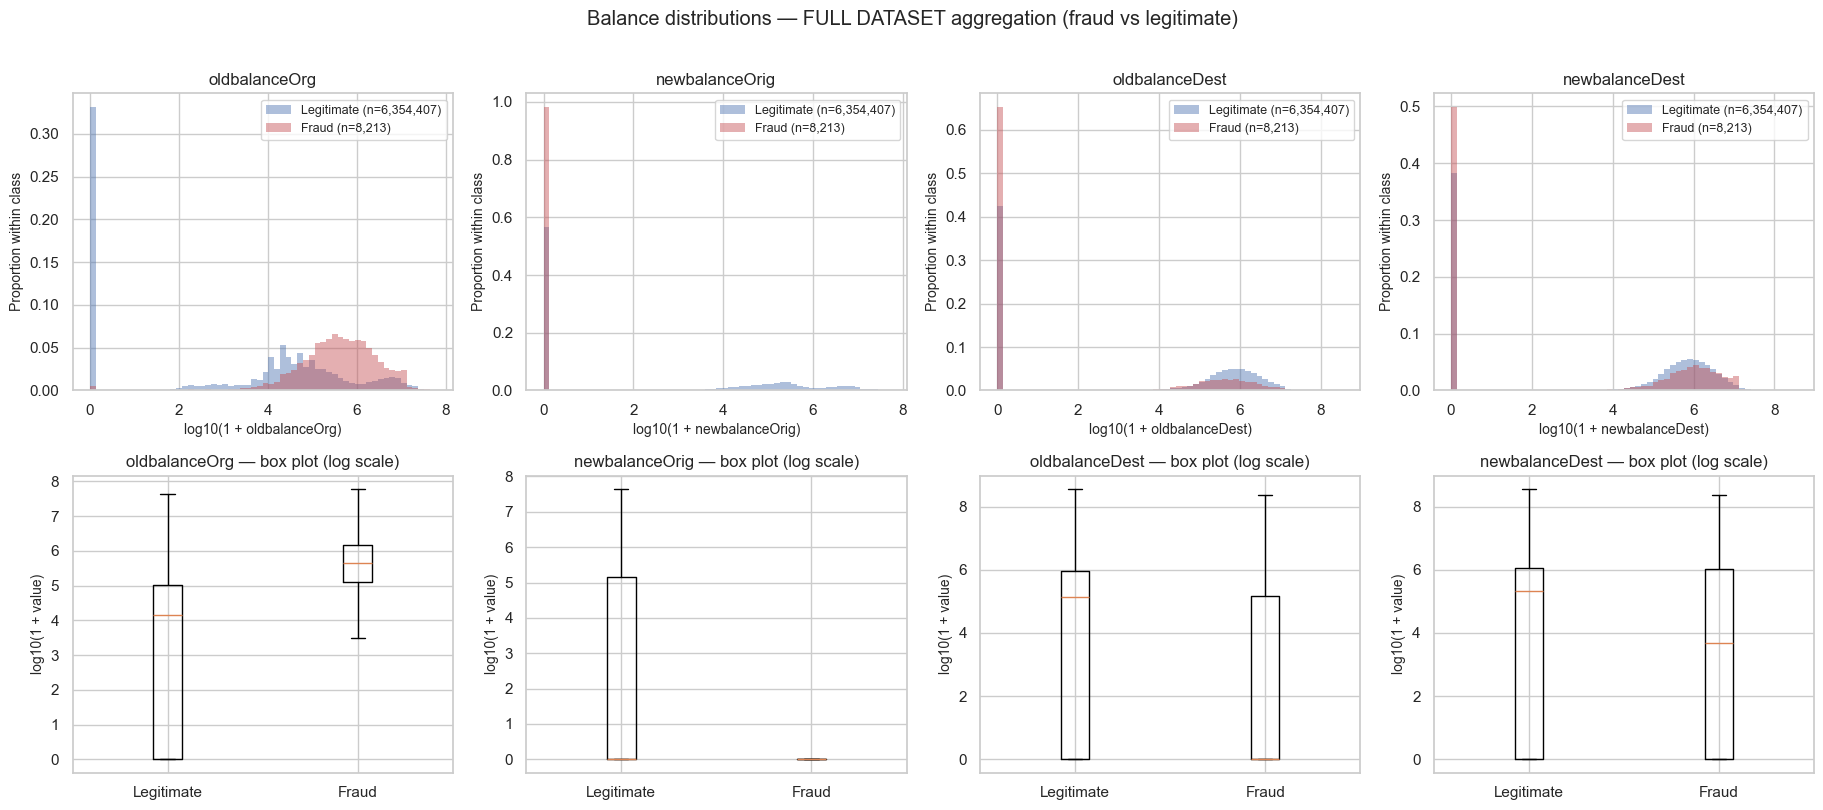

Observation (auto-generated): the highest share of exact-zero values is in 'newbalanceOrig' (56.73%). A large zero share may mean 'empty/untracked balance' rather than a true zero - a data-semantics question this EDA flags but does not assume.


In [17]:
present_bal = [c for c in BALANCE_COLS if HAS[c]]
if not present_bal:
    print("[SKIPPED] Balance analysis: none of the balance columns were found.")
else:
    rows = []
    for c in present_bal:
        st = describe_series(df[c])
        st.update({"column": c, "zero (%)": pct(int((df[c] == 0).sum()), len(df)), "missing (%)": pct(int(df[c].isna().sum()), len(df))})
        rows.append(st)
    balance_summary = pd.DataFrame(rows).set_index("column")
    TABLES["balance_analysis.csv"] = balance_summary
    FINDINGS["balance_summary"] = balance_summary
    display(balance_summary)

    # Balance change (mathematically meaningful for old/new pairs of the same account)
    delta_tbl_rows = []
    if HAS["oldbalanceOrg"] and HAS["newbalanceOrig"]:
        d = (df["newbalanceOrig"] - df["oldbalanceOrg"])
        delta_tbl_rows.append(("newbalanceOrig - oldbalanceOrg", d))
    if HAS["oldbalanceDest"] and HAS["newbalanceDest"]:
        d = (df["newbalanceDest"] - df["oldbalanceDest"])
        delta_tbl_rows.append(("newbalanceDest - oldbalanceDest", d))
    for name, d in delta_tbl_rows:
        md(f"**Balance change: `{name}`**")
        out = {"All": describe_series(d)}
        if HAS_TARGET:
            out["Legitimate (0)"] = describe_series(d[df[TARGET] == 0])
            out["Fraud (1)"] = describe_series(d[df[TARGET] == 1])
        tbl = pd.DataFrame(out).T
        display(tbl)
        TABLES[f"balance_change_{'orig' if 'Orig' in name else 'dest'}.csv"] = tbl
        FINDINGS.setdefault("balance_change_tables", {})[name] = tbl
    del delta_tbl_rows

    # Figure 10: log histograms by class + box plots
    n = len(present_bal)
    fig, axes = plt.subplots(2, n, figsize=(4.6 * n, 8), squeeze=False)
    for i, c in enumerate(present_bal):
        if HAS_TARGET:
            plot_hist_by_class(axes[0][i], df, c, title=f"{c}")
        else:
            cnt, edg = np.histogram(log_values(df[c]), bins=60)
            axes[0][i].stairs(cnt, edg, fill=True, color="#4C72B0", alpha=0.7)
            axes[0][i].set_title(c)
        if HAS_TARGET:
            boxes = [box_stats(log_values(df.loc[df[TARGET] == k, c]), CLASS_NAMES[k]) for k in (0, 1) if (df[TARGET] == k).any()]
        else:
            boxes = [box_stats(log_values(df[c]), "all")]
        axes[1][i].bxp(boxes, showfliers=False)
        axes[1][i].set_title(f"{c} — box plot (log scale)")
        axes[1][i].set_ylabel("log10(1 + value)")
    fig.suptitle("Balance distributions — FULL DATASET aggregation (fraud vs legitimate)", y=1.01)
    plt.tight_layout()
    save_fig(fig, "10_balance_distribution.png")
    plt.show()

    zc = balance_summary["zero (%)"].idxmax()
    print(f"Observation (auto-generated): the highest share of exact-zero values is in '{zc}' ({balance_summary.loc[zc, 'zero (%)']:.2f}%). "
          "A large zero share may mean 'empty/untracked balance' rather than a true zero - a data-semantics question this EDA flags but does not assume.")

**Interpretation.** Watch for (1) large zero shares, (2) very different distributions for fraud vs legitimate, and (3) whether balance *changes* behave differently from raw balances. A difference is a descriptive observation — whether a feature is **usable** depends on prediction-time availability (Section 25).

**Relevance.** Pre-transaction balances (`oldbalance*`) may support ratio features such as `amount / oldbalanceOrg`. Post-transaction balances (`newbalance*`) and anything derived from them are treated as **leakage-suspect** until proven available before prediction.

## SECTION 17 — Balance Consistency Analysis

**Purpose:** Test whether balances, amount and transaction type are logically consistent.
**Relevance:** Reveals simulator artifacts and possible leakage. **The data is not modified.**

**Definitions (all computed with a tolerance of 0.01 currency units):**
* `orig_debit_ok` : `oldbalanceOrg − amount == newbalanceOrig` (sender balance decreased by the amount)
* `orig_credit_ok`: `oldbalanceOrg + amount == newbalanceOrig` (sender balance increased by the amount — expected e.g. for deposits)
* `dest_credit_ok`: `oldbalanceDest + amount == newbalanceDest` (recipient balance increased by the amount)
* `dest_debit_ok` : `oldbalanceDest − amount == newbalanceDest`

Which relationship is "expected" depends on the transaction type, so we report them per type instead of assuming one rule.

In [18]:
TOL = 0.01
CONS = {}   # boolean numpy arrays describing consistency (kept small: one byte per row)

have_orig = cols_present(df, ["oldbalanceOrg", "newbalanceOrig", "amount"], "Origin balance consistency")
have_dest = cols_present(df, ["oldbalanceDest", "newbalanceDest", "amount"], "Destination balance consistency")

amt = df["amount"].to_numpy() if HAS["amount"] else None
if have_orig:
    o_old, o_new = df["oldbalanceOrg"].to_numpy(), df["newbalanceOrig"].to_numpy()
    CONS["orig_debit_ok"] = np.abs(o_old - amt - o_new) <= TOL
    CONS["orig_credit_ok"] = np.abs(o_old + amt - o_new) <= TOL
    CONS["orig_consistent_any"] = CONS["orig_debit_ok"] | CONS["orig_credit_ok"]
    CONS["amount_gt_oldbalance_orig"] = amt > o_old + TOL
    CONS["orig_emptied"] = (o_old > 0) & (o_new == 0)
    CONS["orig_old_zero"] = o_old == 0
if have_dest:
    d_old, d_new = df["oldbalanceDest"].to_numpy(), df["newbalanceDest"].to_numpy()
    CONS["dest_credit_ok"] = np.abs(d_old + amt - d_new) <= TOL
    CONS["dest_debit_ok"] = np.abs(d_old - amt - d_new) <= TOL
    CONS["dest_consistent_any"] = CONS["dest_credit_ok"] | CONS["dest_debit_ok"]
    CONS["dest_both_zero"] = (d_old == 0) & (d_new == 0) & (amt > 0)
    CONS["dest_old_zero"] = d_old == 0

if CONS:
    overall = pd.DataFrame({"Check": list(CONS.keys()),
                            "Count": [int(v.sum()) for v in CONS.values()],
                            "Percentage": [pct(int(v.sum()), len(df)) for v in CONS.values()]})
    md("**Overall consistency checks (FULL DATASET)**")
    display(overall)
    TABLES["balance_consistency_overall.csv"] = overall
    FINDINGS["consistency_overall"] = overall

    # Per type (and per class) — pct of rows for which each check holds
    by = pd.DataFrame({k: v.astype("int8") for k, v in CONS.items()})
    if HAS["type"]:
        by["type"] = df["type"].to_numpy()
        per_type = by.groupby("type", observed=True).mean(numeric_only=True) * 100
        per_type.insert(0, "n_transactions", by.groupby("type", observed=True).size())
        md("**Percentage of rows satisfying each check, per transaction type**")
        display(per_type)
        TABLES["balance_consistency_by_type.csv"] = per_type.reset_index()
        FINDINGS["consistency_by_type"] = per_type
        by = by.drop(columns="type")
    if HAS_TARGET:
        by["cls"] = df[TARGET].to_numpy()
        per_cls = by.groupby("cls").mean() * 100
        per_cls.index = [CLASS_NAMES.get(i, str(i)) for i in per_cls.index]
        md("**Percentage of rows satisfying each check, fraud vs legitimate**")
        display(per_cls)
        TABLES["balance_consistency_by_class.csv"] = per_cls.reset_index().rename(columns={"index": "Class"})
        FINDINGS["consistency_by_class"] = per_cls
    del by

    if "orig_consistent_any" in CONS:
        md("**Examples: sender balance change matches neither `-amount` nor `+amount`**")
        display(df.loc[~CONS["orig_consistent_any"], [c for c in ["step", "type", "amount", "oldbalanceOrg", "newbalanceOrig", TARGET] if c in df.columns]].head(8))
    if "dest_consistent_any" in CONS:
        md("**Examples: recipient balance change matches neither `+amount` nor `-amount`**")
        display(df.loc[~CONS["dest_consistent_any"], [c for c in ["step", "type", "amount", "oldbalanceDest", "newbalanceDest", TARGET] if c in df.columns]].head(8))
else:
    print("[SKIPPED] Balance consistency: required balance columns not available.")

**Overall consistency checks (FULL DATASET)**

,Check,Count,Percentage
0,orig_debit_ok,1284929,20.1950
1,orig_credit_ok,1298205,20.4036
2,orig_consistent_any,2583117,40.5983
3,amount_gt_oldbalance_orig,4079079,64.1101
4,orig_emptied,1520581,23.8987
5,orig_old_zero,2102449,33.0438
6,dest_credit_ok,2173973,34.1679
7,dest_debit_ok,873641,13.7308
8,dest_consistent_any,3047598,47.8985
9,dest_both_zero,2317276,36.4202


**Percentage of rows satisfying each check, per transaction type**

,n_transactions,orig_debit_ok,orig_credit_ok,orig_consistent_any,amount_gt_oldbalance_orig,orig_emptied,orig_old_zero,dest_credit_ok,dest_debit_ok,dest_consistent_any,dest_both_zero,dest_old_zero
type,,,,,,,,,,,,
CASH_IN,1399284,0.0000,92.7752,92.7752,34.1272,0.0000,0.9622,0.0000,62.4337,62.4337,11.4348,11.6898
CASH_OUT,2237500,11.0047,0.0008,11.0047,88.5417,42.8787,45.8458,77.3217,0.0007,77.3217,0.0716,14.4888
DEBIT,41432,69.9218,0.0000,69.9218,28.4466,13.5837,14.8629,76.7547,0.0000,76.7547,0.0000,0.0000
PAYMENT,2151495,45.8101,0.0000,45.8101,51.1795,15.1931,35.9864,0.0000,0.0000,0.0000,100.0000,100.0000
TRANSFER,532909,4.5274,0.0000,4.5274,95.2343,42.9083,53.0640,77.3299,0.0000,77.3299,0.7832,12.2222


**Percentage of rows satisfying each check, fraud vs legitimate**

,orig_debit_ok,orig_credit_ok,orig_consistent_any,amount_gt_oldbalance_orig,orig_emptied,orig_old_zero,dest_credit_ok,dest_debit_ok,dest_consistent_any,dest_both_zero,dest_old_zero
Legitimate,20.0925,20.4297,40.5223,64.1925,23.8035,33.0858,34.1558,13.7483,47.9042,36.4032,42.4750
Fraud,99.4521,0.1948,99.4521,0.3531,97.5527,0.4992,43.5042,0.1948,43.5042,49.5556,65.1528


**Examples: sender balance change matches neither `-amount` nor `+amount`**

,step,type,amount,oldbalanceOrg,newbalanceOrig,isFraud
8,1,PAYMENT,"4,024.3600","2,671.0000",0.0000,0
10,1,DEBIT,"9,644.9400","4,465.0000",0.0000,0
13,1,PAYMENT,"11,633.7600","10,127.0000",0.0000,0
15,1,CASH_OUT,"229,133.9400","15,325.0000",0.0000,0
16,1,PAYMENT,"1,563.8200",450.0000,0.0000,0
19,1,TRANSFER,"215,310.3000",705.0000,0.0000,0
24,1,TRANSFER,"311,685.8900","10,835.0000",0.0000,0
25,1,PAYMENT,"6,061.1300",443.0000,0.0000,0


**Examples: recipient balance change matches neither `+amount` nor `-amount`**

,step,type,amount,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,"9,839.6400",0.0000,0.0000,0
1,1,PAYMENT,"1,864.2800",0.0000,0.0000,0
2,1,TRANSFER,181.0000,0.0000,0.0000,1
3,1,CASH_OUT,181.0000,"21,182.0000",0.0000,1
4,1,PAYMENT,"11,668.1400",0.0000,0.0000,0
5,1,PAYMENT,"7,817.7100",0.0000,0.0000,0
6,1,PAYMENT,"7,107.7700",0.0000,0.0000,0
7,1,PAYMENT,"7,861.6400",0.0000,0.0000,0


**How to interpret.**
* A low percentage for `orig_debit_ok` in a given type means the sender's recorded balance does **not** simply drop by the transaction amount for that type.
* Differences between the fraud and legitimate rows show that the *consistency itself* differs by class.

Possible explanations (to be judged from the numbers above, not assumed): properties of how the simulator generates balances, artifacts, genuine data-quality issues, or **leakage** (e.g. if the inconsistency exists *because* a transaction is fraudulent, then a feature derived from it would hand the model the answer).

**Relevance.** Any engineered balance-error feature (e.g. `oldbalanceOrg − amount − newbalanceOrig`) uses **post-transaction** information and must be flagged high-risk in Phase 3, even if it appears extremely predictive.

## SECTION 18 — `isFlaggedFraud` Analysis

**Purpose:** Understand the pre-existing flag and how it relates to the ground truth.
**Relevance:** `isFlaggedFraud` appears to be an **existing rule-based flag** (PaySim documents it as a rule on very large transfers — we verify below what the data actually shows). If it is used as a model input, the model could simply learn to **reproduce that rule** instead of learning fraud patterns.

The tables below are purely *descriptive* rates of an existing flag against the label; nothing is being trained or evaluated.

In [19]:
if cols_present(df, [FLAG_COL, TARGET], "isFlaggedFraud analysis"):
    n = len(df)
    flag_ct = pd.crosstab(df[FLAG_COL], df[TARGET])
    for k in (0, 1):
        if k not in flag_ct.index:
            flag_ct.loc[k] = 0
        if k not in flag_ct.columns:
            flag_ct[k] = 0
    flag_ct = flag_ct.sort_index().sort_index(axis=1)
    flag_tbl = pd.DataFrame({
        "Flagged": [1, 1, 0, 0],
        "Actual Fraud": [1, 0, 1, 0],
        "Count": [int(flag_ct.loc[1, 1]), int(flag_ct.loc[1, 0]), int(flag_ct.loc[0, 1]), int(flag_ct.loc[0, 0])],
        "Meaning": ["Flagged and fraud", "Flagged but legitimate", "Fraud NOT flagged", "Not flagged and legitimate"]})
    flag_tbl["Percentage of all"] = 100 * flag_tbl["Count"] / n
    display(flag_tbl)
    TABLES["isflaggedfraud_analysis.csv"] = flag_tbl

    flagged = int(df[FLAG_COL].sum())
    fraud_total = int(df[TARGET].sum())
    caught = int(flag_ct.loc[1, 1])
    print(f"Flagged transactions           : {flagged:,} ({pct(flagged, n):.5f}% of all)")
    print(f"Flagged AND fraud              : {caught:,}")
    print(f"Fraud NOT flagged              : {fraud_total - caught:,}")
    print(f"Flagged but NOT fraud          : {flagged - caught:,}")
    print(f"Share of flagged that are fraud (descriptive 'precision' of the rule): {pct(caught, flagged):.2f}%")
    print(f"Share of all fraud that the flag covers (descriptive 'recall' of the rule): {pct(caught, fraud_total):.4f}%")
    FINDINGS.update(flagged_count=flagged, flag_caught=caught, flag_coverage_pct=pct(caught, fraud_total))

    if flagged:
        cols_show = [c for c in ["type", "amount", "oldbalanceOrg", "newbalanceOrig"] if c in df.columns]
        md("**Profile of flagged transactions (what does the rule appear to key on?)**")
        fl = df[df[FLAG_COL] == 1]
        display(fl[cols_show].describe(include="all").T)
        if HAS["amount"]:
            nonflag_big = int(((df[FLAG_COL] == 0) & (df["amount"] >= fl["amount"].min())).sum())
            print(f"Smallest flagged amount: {fl['amount'].min():,.2f}. Non-flagged transactions with amount >= that value: {nonflag_big:,} "
                  "(so amount alone does not fully determine the flag).")
        del fl
    print("\nModelling status: **Requires modeling decision after further investigation.** "
          "It is NOT automatically included or excluded here.")
else:
    print("Modelling status for isFlaggedFraud: cannot be assessed (column or target missing).")

,Flagged,Actual Fraud,Count,Meaning,Percentage of all
0,1,1,16,Flagged and fraud,0.0003
1,1,0,0,Flagged but legitimate,0.0000
2,0,1,8197,Fraud NOT flagged,0.1288
3,0,0,6354407,Not flagged and legitimate,99.8709


Flagged transactions           : 16 (0.00025% of all)
Flagged AND fraud              : 16
Fraud NOT flagged              : 8,197
Flagged but NOT fraud          : 0
Share of flagged that are fraud (descriptive 'precision' of the rule): 100.00%
Share of all fraud that the flag covers (descriptive 'recall' of the rule): 0.1948%


**Profile of flagged transactions (what does the rule appear to key on?)**

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
type,16,1,TRANSFER,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,16.0000,NaN,NaN,NaN,"4,861,597.7306","3,572,499.1023","353,874.2200","2,242,748.7225","4,234,245.0950","7,883,451.3800","10,000,000.0000"
oldbalanceOrg,16.0000,NaN,NaN,NaN,"7,817,869.0119","6,972,668.5331","353,874.2200","3,013,980.2600","4,923,043.0850","12,128,347.5725","19,585,040.3700"
newbalanceOrig,16.0000,NaN,NaN,NaN,"7,817,869.0119","6,972,668.5331","353,874.2200","3,013,980.2600","4,923,043.0850","12,128,347.5725","19,585,040.3700"


Smallest flagged amount: 353,874.22. Non-flagged transactions with amount >= that value: 678,146 (so amount alone does not fully determine the flag).

Modelling status: **Requires modeling decision after further investigation.** It is NOT automatically included or excluded here.


**Interpretation.** Compare the flagged count with the total number of frauds. If the flag covers only a tiny fraction of fraud (or none of it), it is not a reliable stand-alone detector; if it is almost perfectly aligned with a few extreme transactions, the model may learn to mimic the rule.

**Relevance.** **Decision status: "Requires modeling decision after further investigation."** Phase 3/4 should test model behaviour with and without this flag and document the reasoning.

## SECTION 19 — Numerical Feature Analysis

**Purpose:** Systematic distribution summary of every numeric column of the original CSV.
**Relevance:** Shows which numeric variables are skewed (candidates for log transforms), binary, or constant.

To avoid an unreadable wall of plots, one compact grid is drawn for the continuous columns only (binary columns such as the target and the flag are summarised in tables). Histograms are FULL-DATA binned counts; columns with only non-negative values use `log10(1 + x)`.

,n_unique,mean,median,std,min,max,skewness,kurtosis,is_binary,is_constant
column,,,,,,,,,,
step,743,243.3972,239.0000,142.3320,1.0000,743.0000,0.3752,0.3291,False,False
amount,5316900,"179,861.9035","74,871.9400","603,858.2315",0.0000,"92,445,516.6400",30.9939,"1,797.9567",False,False
oldbalanceOrg,1845844,"833,883.1041","14,208.0000","2,888,242.6730",0.0000,"59,585,040.3700",5.2491,32.9649,False,False
newbalanceOrig,2682586,"855,113.6686",0.0000,"2,924,048.5030",0.0000,"49,585,040.3700",5.1769,32.0670,False,False
oldbalanceDest,3614697,"1,100,701.6665","132,705.6650","3,399,180.1130",0.0000,"356,015,889.3500",19.9218,948.6741,False,False
newbalanceDest,3555499,"1,224,996.3982","214,661.4400","3,674,128.9421",0.0000,"356,179,278.9200",19.3523,862.1565,False,False
isFraud,2,0.0013,0.0000,0.0359,0.0000,1.0000,27.7795,769.7030,True,False
isFlaggedFraud,2,0.0000,0.0000,0.0016,0.0000,1.0000,630.6036,"397,659.0625",True,False


Strongly skewed continuous columns (|skewness| > 1): ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
Figure saved -> reports\figures\16_numeric_feature_distributions.png


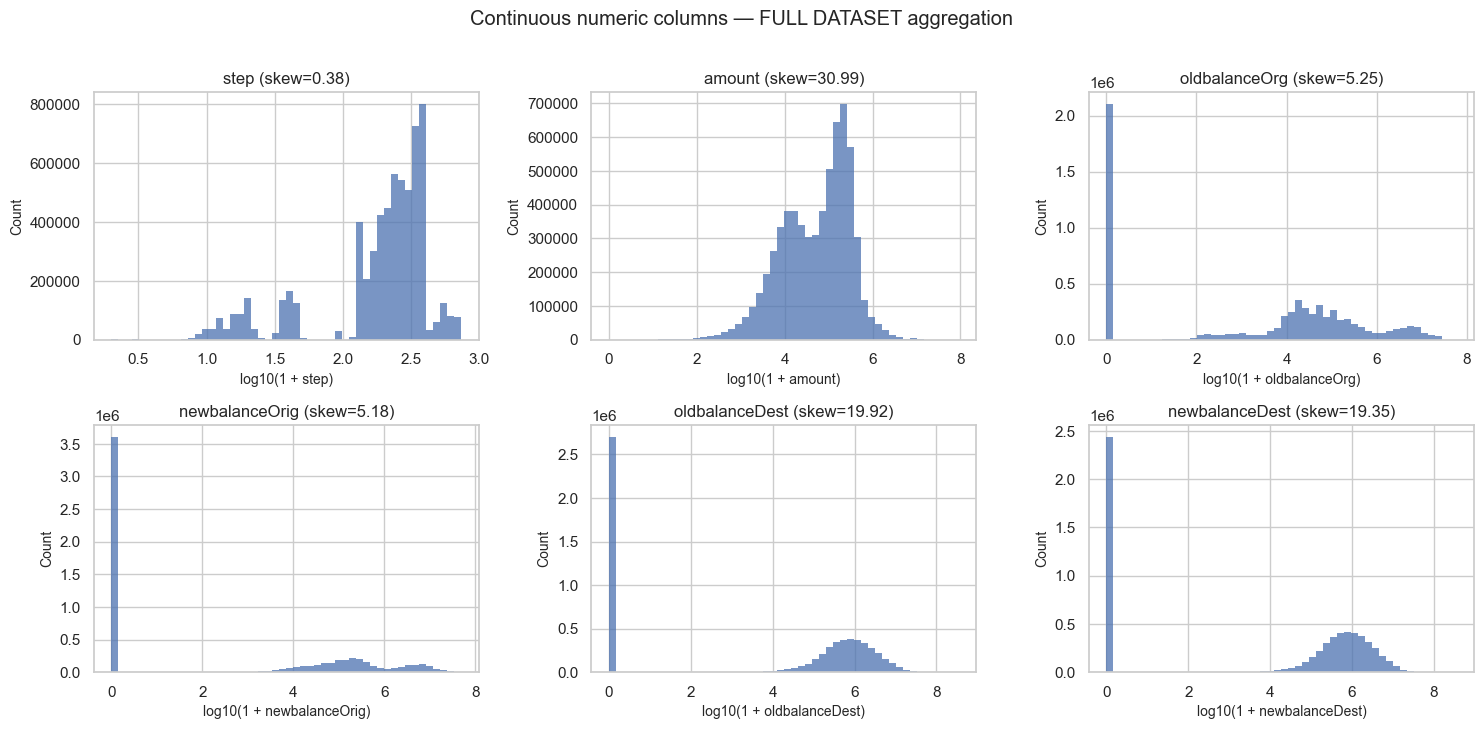

In [20]:
def numeric_feature_table(df, cols):
    """Distribution summary for each numeric column."""
    rows = []
    for c in cols:
        s = df[c]
        rows.append({"column": c, "n_unique": int(s.nunique()), "mean": s.mean(), "median": s.median(), "std": s.std(),
                     "min": s.min(), "max": s.max(), "skewness": s.skew(), "kurtosis": s.kurt(),
                     "is_binary": bool(s.nunique() <= 2), "is_constant": bool(s.nunique() <= 1)})
    return pd.DataFrame(rows).set_index("column")


if numeric_cols:
    num_feat_tbl = numeric_feature_table(df, numeric_cols)
    TABLES["numeric_feature_analysis.csv"] = num_feat_tbl
    display(num_feat_tbl)
    constant_cols = num_feat_tbl.index[num_feat_tbl["is_constant"]].tolist()
    if constant_cols:
        print("WARNING - constant numeric columns (no information):", constant_cols)
    high_skew = num_feat_tbl[(num_feat_tbl["skewness"].abs() > 1) & (~num_feat_tbl["is_binary"])].index.tolist()
    print("Strongly skewed continuous columns (|skewness| > 1):", high_skew if high_skew else "none")
    FINDINGS["high_skew_cols"] = high_skew

    cont_cols = [c for c in numeric_cols if not num_feat_tbl.loc[c, "is_binary"]]
    if cont_cols:
        ncol = 3
        nrow = int(np.ceil(len(cont_cols) / ncol))
        fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.6 * nrow), squeeze=False)
        for ax, c in zip(axes.ravel(), cont_cols):
            vals = df[c].to_numpy(dtype="float64")
            vals = vals[np.isfinite(vals)]
            if vals.min() >= 0 and vals.max() > 100:
                cnt, edg = np.histogram(np.log10(1 + vals), bins=50)
                ax.set_xlabel(f"log10(1 + {c})")
            else:
                cnt, edg = np.histogram(vals, bins=50)
                ax.set_xlabel(c)
            ax.stairs(cnt, edg, fill=True, color="#4C72B0", alpha=0.75)
            ax.set_ylabel("Count")
            ax.set_title(f"{c} (skew={num_feat_tbl.loc[c, 'skewness']:.2f})")
        for ax in axes.ravel()[len(cont_cols):]:
            ax.axis("off")
        fig.suptitle("Continuous numeric columns — FULL DATASET aggregation", y=1.01)
        plt.tight_layout()
        save_fig(fig, "16_numeric_feature_distributions.png")
        plt.show()
else:
    print("[SKIPPED] No numeric columns found.")

**Interpretation.** Large positive skewness together with a max far above the 75th percentile means a heavy right tail — typical for money amounts. Binary columns (target/flag) have only two unique values and are analysed as classes, not distributions.

**Relevance.** Skewed columns are candidates for log transforms in Phase 3 (tree models like XGBoost do not require scaling, but log-scaled features help linear baselines, plots and some drift statistics).

## SECTION 20 — Correlation Analysis

**Purpose:** Pearson correlations between numeric columns, and with `isFraud`.
**Relevance:** Reveals redundant features (e.g. a balance and its post-transaction counterpart) and features associated with the label.

**Correlation ≠ causation.** A high correlation with `isFraud` is only a linear association in this dataset; it can also indicate leakage or a simulator artifact. Only Pearson is computed (FULL DATASET, in `float32` to save memory). The balance-change columns are EDA-only derived quantities.

Figure saved -> reports\figures\11_correlation_heatmap.png


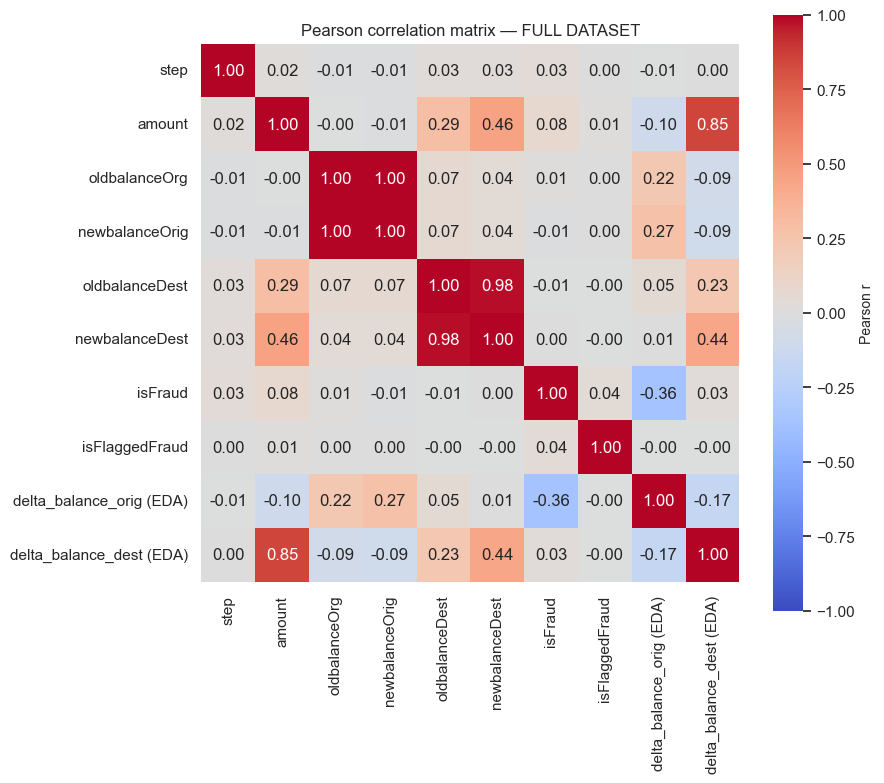

Highly correlated pairs (|r| >= 0.9):


,Variable A,Variable B,Pearson r
0,oldbalanceOrg,newbalanceOrig,0.9988
1,oldbalanceDest,newbalanceDest,0.9766


**Pearson correlation of each numeric column with `isFraud`** (sorted by absolute value)

,Pearson r with isFraud
delta_balance_orig (EDA),-0.3625
amount,0.0767
isFlaggedFraud,0.0441
step,0.0316
delta_balance_dest (EDA),0.0270
oldbalanceOrg,0.0102
newbalanceOrig,-0.0081
oldbalanceDest,-0.0059
newbalanceDest,0.0005


Reminder: these are linear associations only. They neither prove causation nor guarantee usefulness (and a strong association with a post-transaction column may signal leakage).


In [21]:
if len(numeric_cols) >= 2:
    corr_df = df[numeric_cols].astype("float32")
    if HAS["oldbalanceOrg"] and HAS["newbalanceOrig"]:
        corr_df["delta_balance_orig (EDA)"] = (df["newbalanceOrig"] - df["oldbalanceOrg"]).astype("float32")
    if HAS["oldbalanceDest"] and HAS["newbalanceDest"]:
        corr_df["delta_balance_dest (EDA)"] = (df["newbalanceDest"] - df["oldbalanceDest"]).astype("float32")
    corr = corr_df.corr(method="pearson")
    del corr_df
    gc.collect()
    TABLES["correlation_matrix.csv"] = corr
    FINDINGS["corr"] = corr

    fig, ax = plt.subplots(figsize=(max(7, 0.9 * len(corr)), max(6, 0.8 * len(corr))))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
                cbar_kws={"label": "Pearson r"}, ax=ax)
    ax.set_title("Pearson correlation matrix — FULL DATASET")
    plt.tight_layout()
    save_fig(fig, "11_correlation_heatmap.png")
    plt.show()

    THRESH = 0.90   # transparent threshold for "highly correlated"
    pairs = []
    cols_c = corr.columns.tolist()
    for i in range(len(cols_c)):
        for j in range(i + 1, len(cols_c)):
            r = corr.iloc[i, j]
            if pd.notna(r) and abs(r) >= THRESH:
                pairs.append({"Variable A": cols_c[i], "Variable B": cols_c[j], "Pearson r": r})
    high_pairs = pd.DataFrame(pairs)
    FINDINGS["high_corr_pairs"] = high_pairs
    print(f"Highly correlated pairs (|r| >= {THRESH}):")
    display(high_pairs if len(high_pairs) else pd.DataFrame({"result": ["none"]}))

    if HAS_TARGET:
        target_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
        FINDINGS["target_corr"] = target_corr
        md(f"**Pearson correlation of each numeric column with `{TARGET}`** (sorted by absolute value)")
        display(target_corr.to_frame("Pearson r with isFraud"))
        print("Reminder: these are linear associations only. They neither prove causation nor guarantee usefulness "
              "(and a strong association with a post-transaction column may signal leakage).")
else:
    print("[SKIPPED] Correlation analysis: fewer than two numeric columns.")

**Interpretation.** Very high correlation between an "old" and "new" balance (or between a balance and its delta) means these columns carry largely redundant information. Weak *linear* correlation with `isFraud` does not mean a column is useless — fraud is rare and often non-linear/interaction-driven, which tree models can capture.

**Relevance.** Redundant features will be reviewed in Phase 3; strongly target-correlated but post-transaction columns will be scrutinised in the leakage audit (Section 24).

## SECTION 21 — Outlier Analysis (IQR method)

**Purpose:** Quantify extreme values with the standard 1.5×IQR rule.
**Relevance:** In fraud detection, unusual observations may **contain** the fraud signal — so outliers are **measured, never removed**.

Bounds: `lower = Q1 − 1.5·IQR`, `upper = Q3 + 1.5·IQR`. Because most money columns contain many zeros and are heavily skewed, a very large "outlier" share is expected and does not by itself indicate bad data.

,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,outlier_pct,outlier_pct_among_fraud,outlier_pct_among_legit,fraud_rate_within_outliers_pct
column,,,,,,,,,,
amount,"13,389.5700","208,721.4775","195,331.9075","-279,608.2913","501,719.3387",338078,5.3135,46.9256,5.2597,1.1400
oldbalanceOrg,0.0000,"107,315.1750","107,315.1750","-160,972.7625","268,287.9375",1112507,17.4850,60.4651,17.4295,0.4464
newbalanceOrig,0.0000,"144,258.4100","144,258.4100","-216,387.6150","360,646.0250",1053391,16.5559,1.8873,16.5749,0.0147
oldbalanceDest,0.0000,"943,036.7075","943,036.7075","-1,414,555.0613","2,357,591.7687",786135,12.3555,5.6739,12.3642,0.0593
newbalanceDest,0.0000,"1,111,909.2500","1,111,909.2500","-1,667,863.8750","2,779,773.1250",738527,11.6073,13.3812,11.6050,0.1488


Figure saved -> reports\figures\12_outlier_analysis.png


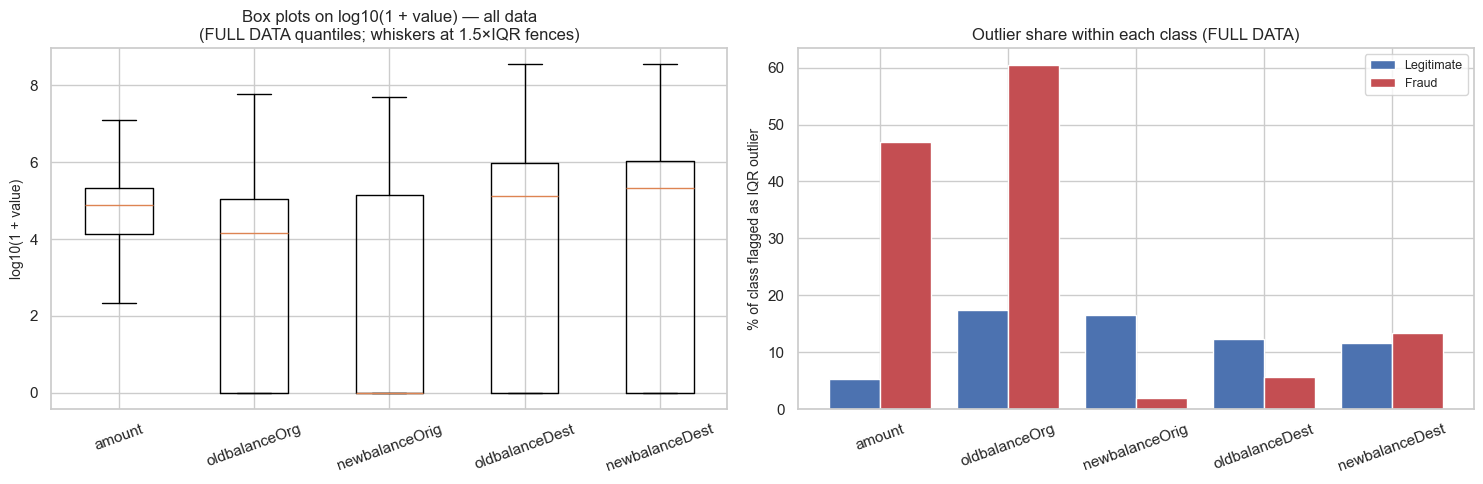

Observation (auto-generated): the column with the largest IQR-outlier share is 'oldbalanceOrg' (17.49%). No outlier was removed or modified.


In [22]:
def analyze_outliers(df, cols):
    """IQR outlier statistics (full data) including how outliers relate to the fraud label."""
    rows = []
    for c in cols:
        s = df[c].to_numpy(dtype="float64")
        ok = np.isfinite(s)
        q1, q3 = np.percentile(s[ok], [25, 75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = ok & ((s < lo) | (s > hi))
        row = {"column": c, "Q1": q1, "Q3": q3, "IQR": iqr, "lower_bound": lo, "upper_bound": hi,
               "n_outliers": int(mask.sum()), "outlier_pct": pct(int(mask.sum()), int(ok.sum()))}
        if HAS_TARGET:
            y = df[TARGET].to_numpy() == 1
            row["outlier_pct_among_fraud"] = pct(int((mask & y).sum()), int(y.sum()))
            row["outlier_pct_among_legit"] = pct(int((mask & ~y).sum()), int((~y).sum()))
            row["fraud_rate_within_outliers_pct"] = pct(int((mask & y).sum()), int(mask.sum()))
        rows.append(row)
    return pd.DataFrame(rows).set_index("column")


outlier_cols = [c for c in ["amount"] + BALANCE_COLS if HAS[c]]
if outlier_cols:
    outlier_tbl = analyze_outliers(df, outlier_cols)
    TABLES["outlier_summary.csv"] = outlier_tbl
    FINDINGS["outlier_table"] = outlier_tbl
    display(outlier_tbl)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    boxes = [box_stats(log_values(df[c]), c) for c in outlier_cols]
    axes[0].bxp(boxes, showfliers=False)
    axes[0].set_title("Box plots on log10(1 + value) — all data\n(FULL DATA quantiles; whiskers at 1.5×IQR fences)")
    axes[0].set_ylabel("log10(1 + value)")
    axes[0].tick_params(axis="x", rotation=20)
    if HAS_TARGET:
        x = np.arange(len(outlier_cols))
        axes[1].bar(x - 0.2, outlier_tbl["outlier_pct_among_legit"], width=0.4, color=COLORS[0], label="Legitimate")
        axes[1].bar(x + 0.2, outlier_tbl["outlier_pct_among_fraud"], width=0.4, color=COLORS[1], label="Fraud")
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(outlier_cols, rotation=20)
        axes[1].set_ylabel("% of class flagged as IQR outlier")
        axes[1].set_title("Outlier share within each class (FULL DATA)")
        axes[1].legend()
    else:
        axes[1].axis("off")
    plt.tight_layout()
    save_fig(fig, "12_outlier_analysis.png")
    plt.show()
    worst = outlier_tbl["outlier_pct"].idxmax()
    print(f"Observation (auto-generated): the column with the largest IQR-outlier share is '{worst}' "
          f"({outlier_tbl.loc[worst, 'outlier_pct']:.2f}%). No outlier was removed or modified.")
else:
    print("[SKIPPED] Outlier analysis: none of the target columns exist.")

**Interpretation.** Compare the outlier share among fraud vs legitimate rows. If fraud rows are outliers much more often, the tail is informative; if the reverse, fraud hides in the "normal" range. Both are important design facts.

**Relevance.** No trimming or winsorising will be applied blindly in Phase 3; any capping must be justified and applied identically in training and streaming inference.

## SECTION 22 — Fraud vs Legitimate Comparison

**Purpose:** One consolidated side-by-side table of the differences found so far.
**Relevance:** Converts EDA into concrete feature-engineering hypotheses.

The "What the EDA shows" column is generated from the numbers; the "What this might mean" column is a *hypothesis* only — an observed difference does not guarantee predictive usefulness.

In [23]:
def compare_classes():
    """Build the fraud vs legitimate comparison table from actual data."""
    if not HAS_TARGET:
        return pd.DataFrame()
    y = df[TARGET].to_numpy() == 1
    rows = []

    def add(metric, legit, fraud, implication):
        ratio = (fraud / legit) if (legit not in (0, None) and pd.notna(legit)) else np.nan
        shows = f"Fraud {fraud:,.4g} vs legitimate {legit:,.4g}" + (f" (×{ratio:,.2f})" if pd.notna(ratio) else "")
        rows.append({"Metric": metric, "Legitimate": legit, "Fraud": fraud, "Ratio (Fraud/Legit)": ratio,
                     "What the EDA shows": shows, "What this might mean for feature engineering": implication})

    if HAS["amount"]:
        a = df["amount"].to_numpy()
        add("Median amount", float(np.median(a[~y])), float(np.median(a[y])), "log_amount, amount relative to balance / customer history")
        add("Mean amount", float(a[~y].mean()), float(a[y].mean()), "Check tail behaviour; consider amount-based bands")
    if HAS["type"]:
        t = df["type"].astype(str).to_numpy()
        top_f = pd.Series(t[y]).value_counts(normalize=True)
        top_l = pd.Series(t[~y]).value_counts(normalize=True)
        tname = top_f.index[0] if len(top_f) else None
        if tname:
            add(f"Share of class in type '{tname}' (%)", 100 * float(top_l.get(tname, 0)), 100 * float(top_f.get(tname, 0)),
                "One-hot/native categorical type; possible type × amount interactions")
    if HAS["step"]:
        add("Median step", float(np.median(df["step"].to_numpy()[~y])),
            float(np.median(df["step"].to_numpy()[y])), "Absolute step is a poor feature (does not generalise); prefer hour-of-day style features")
        if "eda_hour_of_day" in df.columns:
            h = df["eda_hour_of_day"].to_numpy()
            add("Mean hour-of-day (relative)", float(h[~y].mean()), float(h[y].mean()), "Cyclic hour-of-day feature may capture time-of-day behaviour")
    for c in [b for b in BALANCE_COLS if HAS[b]]:
        v = df[c].to_numpy()
        add(f"Median {c}", float(np.median(v[~y])), float(np.median(v[y])), "Balance-based ratios (pre-transaction only)" if "old" in c else "POST-transaction value: leakage-suspect")
        add(f"% zero {c}", pct(int((v[~y] == 0).sum()), int((~y).sum())), pct(int((v[y] == 0).sum()), int(y.sum())),
            "Zero-balance indicators (check whether zero means 'unknown')" if "Dest" in c else "Account-emptied indicators (check timing)")
    if sender_prof is not None:
        add("Mean transactions of the sender account", float(sender_per_txn[~y].mean()), float(sender_per_txn[y].mean()), "Sender-history features (use PAST data only)")
    if dest_prof is not None:
        add("Mean transactions of the destination account", float(dest_per_txn[~y].mean()), float(dest_per_txn[y].mean()), "Recipient-frequency / new-recipient features (PAST data only)")
    if HAS[FLAG_COL]:
        f = df[FLAG_COL].to_numpy()
        add("% flagged by isFlaggedFraud", pct(int(f[~y].sum()), int((~y).sum())), pct(int(f[y].sum()), int(y.sum())),
            "Existing rule: requires modeling decision (risk of reproducing the rule)")
    return pd.DataFrame(rows)


if HAS_TARGET:
    comparison_tbl = compare_classes()
    FINDINGS["comparison_table"] = comparison_tbl
    TABLES["fraud_vs_legitimate_comparison.csv"] = comparison_tbl
    display(comparison_tbl)
    print("Observed differences are descriptive; none guarantees predictive usefulness.")
else:
    print("[SKIPPED] Fraud vs legitimate comparison: target column missing.")

,Metric,Legitimate,Fraud,Ratio (Fraud/Legit),What the EDA shows,What this might mean for feature engineering
0,Median amount,"74,684.7200","441,423.4400",5.9105,Fraud 4.414e+05 vs legitimate 7.468e+04 (×5.91),"log_amount, amount relative to balance / custo..."
1,Mean amount,"178,197.0417","1,467,967.2991",8.2379,Fraud 1.468e+06 vs legitimate 1.782e+05 (×8.24),Check tail behaviour; consider amount-based bands
2,Share of class in type 'CASH_OUT' (%),35.1470,50.1157,1.4259,Fraud 50.12 vs legitimate 35.15 (×1.43),One-hot/native categorical type; possible type...
3,Median step,239.0000,367.0000,1.5356,Fraud 367 vs legitimate 239 (×1.54),Absolute step is a poor feature (does not gene...
4,Mean hour-of-day (relative),14.5956,11.4231,0.7826,Fraud 11.42 vs legitimate 14.6 (×0.78),Cyclic hour-of-day feature may capture time-of...
5,Median oldbalanceOrg,"14,069.0000","438,983.4500",31.2022,Fraud 4.39e+05 vs legitimate 1.407e+04 (×31.20),Balance-based ratios (pre-transaction only)
6,% zero oldbalanceOrg,33.0858,0.4992,0.0151,Fraud 0.4992 vs legitimate 33.09 (×0.02),Account-emptied indicators (check timing)
7,Median newbalanceOrig,0.0000,0.0000,NaN,Fraud 0 vs legitimate 0,POST-transaction value: leakage-suspect
8,% zero newbalanceOrig,56.6774,98.0519,1.7300,Fraud 98.05 vs legitimate 56.68 (×1.73),Account-emptied indicators (check timing)
9,Median oldbalanceDest,"133,311.8000",0.0000,0.0000,Fraud 0 vs legitimate 1.333e+05 (×0.00),Balance-based ratios (pre-transaction only)


Observed differences are descriptive; none guarantees predictive usefulness.


**Interpretation.** Rows with a ratio far from 1 are where the classes differ most. Treat each as a *hypothesis*: e.g., "fraud transactions appear to involve larger amounts" suggests testing a log-amount feature; it does not prove that amount alone can separate fraud.

**Relevance.** This table is the bridge between EDA and the candidate list in Section 27.

## SECTION 23 — Cardinality Analysis

**Purpose:** Decide how each categorical/string column can be encoded later.
**Relevance:** Determines encoding strategy and which columns need behavioural aggregation.

**Transparent threshold used here**
* **Low cardinality:** ≤ 50 unique values
* **High cardinality:** > 1,000 unique values **or** cardinality ratio (unique ÷ rows) ≥ 5%
* **Medium cardinality:** everything in between

Columns whose cardinality ratio is ≥ 50% are additionally marked as **identifier-like**. The thresholds are conventions chosen for readability, not statistical laws.

In [25]:
LOW_MAX, HIGH_MIN, HIGH_RATIO, ID_RATIO = 50, 1000, 0.05, 0.50


def analyze_cardinality(df, cols):
    rows = []
    n = len(df)
    for c in cols:
        nu = int(df[c].nunique(dropna=True))
        ratio = nu / n if n else 0
        level = "High Cardinality" if (nu > HIGH_MIN or ratio >= HIGH_RATIO) else ("Low Cardinality" if nu <= LOW_MAX else "Medium Cardinality")
        is_id = ratio >= ID_RATIO
        if level == "Low Cardinality":
            action = "Suitable for one-hot / native categorical encoding"
        elif is_id:
            action = "Identifier: do NOT encode directly; derive behavioural (aggregate) features from past transactions or drop"
        elif level == "High Cardinality":
            action = "Do not one-hot; consider frequency/behavioural aggregation"
        else:
            action = "Consider frequency or target-style encoding with strict temporal care"
        rows.append({"column": c, "unique_values": nu, "cardinality_ratio": ratio, "level": level,
                     "identifier_like": is_id, "recommended_handling": action})
    return pd.DataFrame(rows).set_index("column")


if categorical_cols:
    card_tbl = analyze_cardinality(df, categorical_cols)
    TABLES["cardinality_analysis.csv"] = card_tbl
    FINDINGS["cardinality_table"] = card_tbl
    display(card_tbl)
    FINDINGS["high_cardinality_columns"] = card_tbl.index[card_tbl["level"] == "High Cardinality"].tolist()
    FINDINGS["identifier_columns"] = card_tbl.index[card_tbl["identifier_like"]].tolist()
    print("One-hot candidates          :", card_tbl.index[card_tbl["level"] == "Low Cardinality"].tolist())
    print("Need behavioural aggregation:", FINDINGS["high_cardinality_columns"])
    print("Identifier-like columns     :", FINDINGS["identifier_columns"])
    print("No preprocessing is performed here.")
else:
    FINDINGS["high_cardinality_columns"] = []
    FINDINGS["identifier_columns"] = []
    print("[SKIPPED] No categorical/string columns found.")

,unique_values,cardinality_ratio,level,identifier_like,recommended_handling
column,,,,,
type,5,0.0000,Low Cardinality,False,Suitable for one-hot / native categorical enco...
nameOrig,6353307,0.9985,High Cardinality,True,Identifier: do NOT encode directly; derive beh...
nameDest,2722362,0.4279,High Cardinality,False,Do not one-hot; consider frequency/behavioural...


One-hot candidates          : ['type']
Need behavioural aggregation: ['nameOrig', 'nameDest']
Identifier-like columns     : ['nameOrig']
No preprocessing is performed here.


**Interpretation.** Low-cardinality columns can be encoded directly. High-cardinality identifiers are neither safe nor useful as raw inputs; they become useful only as *keys* for computing historical behaviour.

**Relevance.** In Spark Structured Streaming, identifier columns are the **state keys** for windowed/stateful features.

## SECTION 24 — Data Leakage Audit  ⚠️ CRITICAL

**Purpose:** For every column decide *when* the information exists relative to the moment the model must predict.
**Relevance:** A model that uses information unavailable at prediction time will look excellent offline and fail (or be impossible to deploy) in the real-time system.

**Three kinds of information**
* **Pre-transaction:** state known before the transaction occurs (e.g. the balance before the payment).
* **Transaction-time:** properties of the transaction request itself (amount, type, time, parties).
* **Post-transaction:** outcomes produced by the transaction (e.g. the balance after it) or the later-confirmed label.

`isFraud` **MUST NOT** be used as an input feature — it is the ground-truth label and, in the final system, arrives *after* the prediction (delayed ground truth).

The classification below is based on the **documented meaning** of the PaySim columns plus the empirical probes computed from the actual CSV. Entries marked *Needs Investigation* are deliberately not decided here.

In [28]:
KNOWN_COLUMNS = {
    "isFraud": ("Label (post-event)", "Ground-truth label: 1 = fraudulent, 0 = legitimate.", "No", "Yes",
                "It IS the answer. In a live system the label is confirmed later (delayed ground truth).",
                "Use ONLY as target y; never in the feature matrix; store NULL at prediction time and fill later."),
    "isFlaggedFraud": ("Rule-derived (timing unknown)", "Flag from a pre-existing business rule.", "Needs Investigation", "Needs Investigation",
                       "May encode an existing rule (model could reproduce it) and the moment it is set relative to prediction is not documented.",
                       "Requires modeling decision after further investigation (train with and without; document)."),
    "amount": ("Transaction-time", "Value of the transaction request.", "Yes", "No",
               "Part of the transaction event itself.", "Use (e.g. log_amount, ratios to PAST/pre-transaction state)."),
    "type": ("Transaction-time", "Category of the transaction (payment, transfer, cash-out, ...).", "Yes", "No",
             "Part of the transaction event itself.", "Use as a low-cardinality categorical feature."),
    "step": ("Transaction-time", "Simulated hour of the transaction (time axis).", "Yes", "No",
             "Known at event time; but the raw absolute index will not generalise to future periods.",
             "Use for ordering/splitting; derive hour-of-day style features; avoid raw step as a predictor unless justified."),
    "nameOrig": ("Pre-transaction (identifier)", "Sender account identifier.", "Yes", "No",
                 "Known at event time. Leakage arises only if history features use FUTURE rows.",
                 "Do not encode raw; use as key for PAST-only behavioural aggregates."),
    "nameDest": ("Pre-transaction (identifier)", "Recipient account identifier.", "Yes", "No",
                 "Known at event time. Leakage arises only if history features use FUTURE rows.",
                 "Do not encode raw; use as key for PAST-only recipient behaviour."),
    "oldbalanceOrg": ("Pre-transaction", "Sender balance before the transaction.", "Yes", "Needs Investigation",
                      "Should exist before execution, but the snapshot timing inside the simulator is not documented in the data.",
                      "Candidate for ratio features (e.g. amount / oldbalanceOrg) after confirming timing."),
    "newbalanceOrig": ("Post-transaction", "Sender balance after the transaction.", "No", "Yes",
                       "Produced by the transaction outcome; unavailable to a model scoring before execution.",
                       "Exclude from real-time features; do not derive features from it without a documented rationale."),
    "oldbalanceDest": ("Pre-transaction", "Recipient balance before the transaction.", "Yes", "Needs Investigation",
                       "Should exist before execution, but zeros may mean 'unknown/untracked' (see Section 16/17).",
                       "Candidate after investigating what zero means."),
    "newbalanceDest": ("Post-transaction", "Recipient balance after the transaction.", "No", "Yes",
                       "Produced by the transaction outcome; unavailable to a model scoring before execution.",
                       "Exclude from real-time features."),
}


def build_probe_table():
    """Descriptive fraud rates inside simple conditions derived from post-/pre-transaction fields."""
    if not HAS_TARGET:
        return pd.DataFrame()
    y = df[TARGET].to_numpy() == 1
    base = y.mean() * 100
    conds = {}
    if "orig_emptied" in CONS:
        conds["Sender balance goes from >0 to exactly 0 (uses newbalanceOrig)"] = CONS["orig_emptied"]
        conds["Sender balance change matches neither -amount nor +amount"] = ~CONS["orig_consistent_any"]
        conds["amount > oldbalanceOrg"] = CONS["amount_gt_oldbalance_orig"]
        conds["oldbalanceOrg == 0"] = CONS["orig_old_zero"]
    if "dest_both_zero" in CONS:
        conds["Recipient old AND new balance both 0 (uses newbalanceDest)"] = CONS["dest_both_zero"]
        conds["Recipient balance change matches neither +amount nor -amount"] = ~CONS["dest_consistent_any"]
        conds["oldbalanceDest == 0"] = CONS["dest_old_zero"]
    if HAS[FLAG_COL]:
        conds["isFlaggedFraud == 1"] = df[FLAG_COL].to_numpy() == 1
    rows = []
    for name, m in conds.items():
        cnt = int(m.sum())
        fr = int((m & y).sum())
        rate = pct(fr, cnt)
        rows.append({"Condition": name, "Rows": cnt, "Fraud rows": fr, "Fraud rate in condition (%)": rate,
                     "Lift vs overall rate": (rate / base) if base else np.nan,
                     "% of all fraud inside condition": pct(fr, int(y.sum()))})
    return pd.DataFrame(rows)


def perform_leakage_audit(columns):
    rows = []
    for c in columns:
        if c in KNOWN_COLUMNS:
            timing, what, known, leak, why, action = KNOWN_COLUMNS[c]
        else:
            timing, what, known, leak = "Unknown", "Not part of the documented PaySim schema.", "Needs Investigation", "Needs Investigation"
            why, action = "Unknown origin/timing.", "Investigate before any use."
        rows.append({"Column": c, "Information timing": timing, "What it represents": what,
                     "Potentially known at prediction time?": known, "Potential leakage?": leak, "Why?": why,
                     "Recommended future action": action})
    return pd.DataFrame(rows)


leakage_audit = perform_leakage_audit(ORIGINAL_COLUMNS)
FINDINGS["leakage_audit"] = leakage_audit
TABLES["leakage_audit.csv"] = leakage_audit
FINDINGS["potential_leakage_columns"] = leakage_audit.loc[leakage_audit["Potential leakage?"] == "Yes", "Column"].tolist()
FINDINGS["leakage_investigate_columns"] = leakage_audit.loc[leakage_audit["Potential leakage?"] == "Needs Investigation", "Column"].tolist()
with pd.option_context("display.max_colwidth", 120):
    display(leakage_audit)

print("\n!!! isFraud must NEVER be used as an input feature. !!!")
print("Definite leakage columns   :", FINDINGS["potential_leakage_columns"])
print("Needs investigation        :", FINDINGS["leakage_investigate_columns"])

probe_tbl = build_probe_table()
if len(probe_tbl):
    md("**Empirical leakage probes (descriptive; computed from the data)** — how strongly do simple conditions built from pre-/post-transaction fields concentrate fraud?")
    display(probe_tbl)
    TABLES["leakage_probes.csv"] = probe_tbl
    FINDINGS["probe_table"] = probe_tbl
    print("A condition with a very high lift that depends on a POST-transaction column is a leakage warning: "
          "it would look powerful offline but cannot be known before the transaction completes.")
else:
    print("(No empirical probes available - target or balance columns missing.)")

,Column,Information timing,What it represents,Potentially known at prediction time?,Potential leakage?,Why?,Recommended future action
0,step,Transaction-time,Simulated hour of the transaction (time axis).,Yes,No,Known at event time; but the raw absolute index will not generalise to future periods.,Use for ordering/splitting; derive hour-of-day style features; avoid raw step as a predictor unless justified.
1,type,Transaction-time,"Category of the transaction (payment, transfer, cash-out, ...).",Yes,No,Part of the transaction event itself.,Use as a low-cardinality categorical feature.
2,amount,Transaction-time,Value of the transaction request.,Yes,No,Part of the transaction event itself.,"Use (e.g. log_amount, ratios to PAST/pre-transaction state)."
3,nameOrig,Pre-transaction (identifier),Sender account identifier.,Yes,No,Known at event time. Leakage arises only if history features use FUTURE rows.,Do not encode raw; use as key for PAST-only behavioural aggregates.
4,oldbalanceOrg,Pre-transaction,Sender balance before the transaction.,Yes,Needs Investigation,"Should exist before execution, but the snapshot timing inside the simulator is not documented in the data.",Candidate for ratio features (e.g. amount / oldbalanceOrg) after confirming timing.
5,newbalanceOrig,Post-transaction,Sender balance after the transaction.,No,Yes,Produced by the transaction outcome; unavailable to a model scoring before execution.,Exclude from real-time features; do not derive features from it without a documented rationale.
6,nameDest,Pre-transaction (identifier),Recipient account identifier.,Yes,No,Known at event time. Leakage arises only if history features use FUTURE rows.,Do not encode raw; use as key for PAST-only recipient behaviour.
7,oldbalanceDest,Pre-transaction,Recipient balance before the transaction.,Yes,Needs Investigation,"Should exist before execution, but zeros may mean 'unknown/untracked' (see Section 16/17).",Candidate after investigating what zero means.
8,newbalanceDest,Post-transaction,Recipient balance after the transaction.,No,Yes,Produced by the transaction outcome; unavailable to a model scoring before execution.,Exclude from real-time features.
9,isFraud,Label (post-event),"Ground-truth label: 1 = fraudulent, 0 = legitimate.",No,Yes,It IS the answer. In a live system the label is confirmed later (delayed ground truth).,Use ONLY as target y; never in the feature matrix; store NULL at prediction time and fill later.



!!! isFraud must NEVER be used as an input feature. !!!
Definite leakage columns   : ['newbalanceOrig', 'newbalanceDest', 'isFraud']
Needs investigation        : ['oldbalanceOrg', 'oldbalanceDest', 'isFlaggedFraud']


**Empirical leakage probes (descriptive; computed from the data)** — how strongly do simple conditions built from pre-/post-transaction fields concentrate fraud?

,Condition,Rows,Fraud rows,Fraud rate in condition (%),Lift vs overall rate,% of all fraud inside condition
0,Sender balance goes from >0 to exactly 0 (uses...,1520581,8012,0.5269,4.0819,97.5527
1,Sender balance change matches neither -amount ...,3779503,45,0.0012,0.0092,0.5479
2,amount > oldbalanceOrg,4079079,29,0.0007,0.0055,0.3531
3,oldbalanceOrg == 0,2102449,41,0.0020,0.0151,0.4992
4,Recipient old AND new balance both 0 (uses new...,2317276,4070,0.1756,1.3607,49.5556
5,Recipient balance change matches neither +amou...,3315022,4640,0.1400,1.0843,56.4958
6,oldbalanceDest == 0,2704388,5351,0.1979,1.5329,65.1528
7,isFlaggedFraud == 1,16,16,100.0000,774.7011,0.1948


A condition with a very high lift that depends on a POST-transaction column is a leakage warning: it would look powerful offline but cannot be known before the transaction completes.


**Interpretation.** The static table records *when* each field exists; the probe table shows *how much* an apparently harmless condition can reveal about the label. When a probe involving a post-transaction field shows a huge lift, the corresponding feature would leak the outcome — in the real-time system it simply would not exist yet.

**Relevance.** This audit drives the Phase 3 rule: *only features computable from information available at prediction time enter the feature matrix*, and SHAP explanations later are only meaningful if that rule holds.

## SECTION 25 — Prediction-Time Availability

**Purpose:** Answer one question: *what information would realistically exist at the moment the model has to predict?*
**Relevance:** In the final Kafka → Spark → XGBoost pipeline, the message that is scored can only contain fields available at that moment. Anything else can only be used *afterwards* (analysis, delayed-label joins, retraining targets).

Classification used:
1. **Likely available before/during the transaction**
2. **Potentially available only after the transaction**
3. **Unclear / requires investigation**

In [30]:
def analyze_prediction_time_availability(audit):
    """Group columns by when their information exists, and state the consequence for the streaming design."""
    rows = []
    for _, r in audit.iterrows():
        known = r["Potentially known at prediction time?"]
        col = r["Column"]
        if known == "Yes":
            cat = "1. Likely available before/during transaction"
            impl = ("Can be carried in the Kafka event and used by Spark (row-level; or as a STATE KEY for history features).")
            if r["Potential leakage?"] == "Needs Investigation":
                impl += " Confirm the exact snapshot timing first."
        elif known == "No":
            cat = "2. Potentially available only after transaction"
            impl = ("Must NOT be part of the scoring message. Keep separately for later analysis"
                    + (" / delayed ground-truth join." if col == TARGET else "."))
        else:
            cat = "3. Unclear / requires investigation"
            impl = "Hold out of the Phase 3 baseline until investigated; decide and document."
        rows.append({"Column": col, "Availability category": cat, "Information timing": r["Information timing"],
                     "Why it matters for the Kafka/Spark design": impl})
    return pd.DataFrame(rows)


availability_tbl = analyze_prediction_time_availability(leakage_audit)
TABLES["prediction_time_availability.csv"] = availability_tbl
FINDINGS["availability_table"] = availability_tbl
FINDINGS["prediction_time_risk_columns"] = availability_tbl.loc[
    ~availability_tbl["Availability category"].str.startswith("1."), "Column"].tolist()
with pd.option_context("display.max_colwidth", 110):
    display(availability_tbl)
print("Columns that must not be in the real-time scoring feature set (categories 2 and 3):", FINDINGS["prediction_time_risk_columns"])

,Column,Availability category,Information timing,Why it matters for the Kafka/Spark design
0,step,1. Likely available before/during transaction,Transaction-time,Can be carried in the Kafka event and used by Spark (row-level; or as a STATE KEY for history features).
1,type,1. Likely available before/during transaction,Transaction-time,Can be carried in the Kafka event and used by Spark (row-level; or as a STATE KEY for history features).
2,amount,1. Likely available before/during transaction,Transaction-time,Can be carried in the Kafka event and used by Spark (row-level; or as a STATE KEY for history features).
3,nameOrig,1. Likely available before/during transaction,Pre-transaction (identifier),Can be carried in the Kafka event and used by Spark (row-level; or as a STATE KEY for history features).
4,oldbalanceOrg,1. Likely available before/during transaction,Pre-transaction,Can be carried in the Kafka event and used by Spark (row-level; or as a STATE KEY for history features). C...
5,newbalanceOrig,2. Potentially available only after transaction,Post-transaction,Must NOT be part of the scoring message. Keep separately for later analysis.
6,nameDest,1. Likely available before/during transaction,Pre-transaction (identifier),Can be carried in the Kafka event and used by Spark (row-level; or as a STATE KEY for history features).
7,oldbalanceDest,1. Likely available before/during transaction,Pre-transaction,Can be carried in the Kafka event and used by Spark (row-level; or as a STATE KEY for history features). C...
8,newbalanceDest,2. Potentially available only after transaction,Post-transaction,Must NOT be part of the scoring message. Keep separately for later analysis.
9,isFraud,2. Potentially available only after transaction,Label (post-event),Must NOT be part of the scoring message. Keep separately for later analysis / delayed ground-truth join.


Columns that must not be in the real-time scoring feature set (categories 2 and 3): ['newbalanceOrig', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


**Interpretation.** Only category 1 columns may be placed in the event that Kafka delivers to Spark for scoring. Category 2 fields are what the *system observes later* (outcome balances, the confirmed label). Category 3 fields need a documented decision.

**Relevance.** This table will become the **input schema** of the Kafka topic in the streaming phase and the "allowed features" list of Phase 3.

## SECTION 26 — Temporal Train / Validation / Test Strategy (plan only — no model)

Because the target system is a **real-time** system, evaluation must respect the direction of time:

```
Earlier transactions  →  TRAINING
Later transactions    →  VALIDATION   (threshold / hyper-parameter decisions)
Latest transactions   →  TEST         (final, untouched, simulated "future")
```

**Why a random split is unrealistic for temporal transaction data**
* **Temporal leakage:** a random split places later transactions in training and earlier ones in test, so the model can "learn from the future".
* **Future information in features:** behaviour aggregates computed over the whole file would use rows that, in production, do not exist yet.
* **Distribution change:** in production the model always faces data *newer* than its training data; a random split hides any shift.
* **Realism:** a chronological split mimics deployment: train on the past, score the future.

**Below:** a *plan* (not a model) — chronological cut-offs at ≈70% / 15% / 15% of transactions, and a check that each period contains fraud.

In [31]:
SPLIT_FRACTIONS = (0.70, 0.15, 0.15)


def plan_temporal_split(step_table, fractions=SPLIT_FRACTIONS):
    """Choose step cut-offs by cumulative transaction share and summarise each period."""
    st = step_table.sort_values("step").reset_index(drop=True)
    total = st["Total Transactions"].sum()
    cum = st["Total Transactions"].cumsum() / total
    train_end = int(st.loc[cum >= fractions[0], "step"].iloc[0])
    val_end = int(st.loc[cum >= fractions[0] + fractions[1], "step"].iloc[0])
    period = np.where(st["step"] <= train_end, "Train (earliest)", np.where(st["step"] <= val_end, "Validation", "Test (latest)"))
    st["period"] = period
    agg = {"Total Transactions": "sum"}
    if "Fraud Transactions" in st.columns:
        agg["Fraud Transactions"] = "sum"
    out = st.groupby("period").agg({**agg, "step": ["min", "max"]})
    out.columns = ["Total Transactions"] + (["Fraud Transactions"] if "Fraud Transactions" in st.columns else []) + ["First step", "Last step"]
    out = out.reindex(["Train (earliest)", "Validation", "Test (latest)"])
    out["Share of all transactions (%)"] = 100 * out["Total Transactions"] / total
    if "Fraud Transactions" in out.columns:
        out["Fraud Rate (%)"] = 100 * out["Fraud Transactions"] / out["Total Transactions"]
        out["Share of all fraud (%)"] = 100 * out["Fraud Transactions"] / max(out["Fraud Transactions"].sum(), 1)
    return out.reset_index().rename(columns={"period": "Period"}), train_end, val_end


if "step_table" in FINDINGS:
    split_tbl, TRAIN_END_STEP, VAL_END_STEP = plan_temporal_split(FINDINGS["step_table"])
    FINDINGS.update(split_table=split_tbl, train_end_step=TRAIN_END_STEP, val_end_step=VAL_END_STEP)
    TABLES["temporal_split_plan.csv"] = split_tbl
    display(split_tbl)
    print(f"Proposed cut-offs: train = steps <= {TRAIN_END_STEP}, validation = steps {TRAIN_END_STEP + 1}..{VAL_END_STEP}, "
          f"test = steps > {VAL_END_STEP}")
    if "Fraud Transactions" in split_tbl.columns:
        empty = split_tbl.loc[split_tbl["Fraud Transactions"] == 0, "Period"].tolist()
        if empty:
            print("WARNING: these periods contain NO fraud, so evaluation on them would be impossible:", empty)
        else:
            print("Every proposed period contains fraud transactions, so precision/recall/PR-AUC can be computed on each.")
else:
    print("[SKIPPED] Temporal split plan: 'step' analysis unavailable.")

,Period,Total Transactions,Fraud Transactions,First step,Last step,Share of all transactions (%),Fraud Rate (%),Share of all fraud (%)
0,Train (earliest),4463587,3643,1,323,70.1533,0.0816,44.3565
1,Validation,980416,564,324,378,15.4090,0.0575,6.8672
2,Test (latest),918617,4006,379,743,14.4377,0.4361,48.7763


Proposed cut-offs: train = steps <= 323, validation = steps 324..378, test = steps > 378
Every proposed period contains fraud transactions, so precision/recall/PR-AUC can be computed on each.


**Interpretation.** The table shows whether a chronological split leaves enough fraud examples in every period. If the fraud rate differs a lot between periods, that is itself a reason to evaluate on the latest period only (as production would).

**Relevance.** This chronological cut-off becomes the boundary between "historical" and "future/streamed" data (Sections 28–29) and the basis of the later retraining windows. **No model is trained here.**

## SECTION 27 — Future Feature Engineering Candidates (Phase 3 input)

**Purpose:** Turn the EDA findings into a *candidate* feature list.
**Relevance:** Only features that make sense for **this** dataset and that can be computed from information available at prediction time are recommended.

**Priority rules (transparent, not arbitrary)**
* History-based features (velocity, averages, time since previous, new-recipient): **High** if ≥ 20% of transactions come from accounts with more than one transaction, **Medium** if 5–20%, **Low** if < 5% — because such features need history to exist.
* `log_amount`: **High** if |skewness| > 1, otherwise Medium.
* Balance-derived features that rely on *post-transaction* fields: always **Low** priority with **High** leakage risk.
* Time-of-day style features: **Medium** only if the highest hourly fraud rate is ≥ 2× the lowest; otherwise Low.

Priority is used only to order Phase 3 work; it is **not** a ranking of the dataset or a model.

In [32]:
def priority_from_history(share_pct):
    if share_pct >= 20:
        return "High"
    if share_pct >= 5:
        return "Medium"
    return "Low"


def generate_feature_candidates():
    rows = []

    def add(feature, sources, reason, use, avail, leak, priority, evidence):
        if all(s in df.columns for s in sources):
            rows.append({"Feature": feature, "Source Columns": ", ".join(sources), "Reason": reason, "Expected Use": use,
                         "Prediction-Time Availability": avail, "Leakage Risk": leak, "Priority": priority,
                         "EDA Evidence": evidence})
        else:
            print(f"[not proposed] {feature}: needs missing column(s) {[s for s in sources if s not in df.columns]}")

    # ---- evidence computed from the data ----
    skew = FINDINGS.get("amount_stats", {}).get("skewness", np.nan)
    s_share = FINDINGS.get("sender_summary", {}).get("% of all transactions made by repeated accounts", np.nan)
    d_share = FINDINGS.get("dest_summary", {}).get("% of all transactions made by repeated accounts", np.nan)
    hmax, hmin = FINDINGS.get("hour_rate_max", np.nan), FINDINGS.get("hour_rate_min", np.nan)
    fraud_types = FINDINGS.get("fraud_types", [])
    n_types = df["type"].nunique() if HAS["type"] else 0

    # amount / oldbalanceOrg evidence
    ratio_ev, ratio_prio = "n/a", "Medium"
    if HAS["amount"] and HAS["oldbalanceOrg"] and HAS_TARGET:
        y = df[TARGET].to_numpy() == 1
        full = df["amount"].to_numpy() >= 0.99 * df["oldbalanceOrg"].to_numpy()
        pos = df["oldbalanceOrg"].to_numpy() > 0
        f_share, l_share = pct(int((full & pos & y).sum()), int(y.sum())), pct(int((full & pos & ~y).sum()), int((~y).sum()))
        ratio_ev = f"amount >= 99% of oldbalanceOrg: {f_share:.2f}% of fraud vs {l_share:.2f}% of legitimate"
        ratio_prio = "High" if (l_share == 0 and f_share > 0) or (l_share > 0 and (f_share / l_share >= 2 or f_share / l_share <= 0.5)) else "Medium"

    # dest prefix evidence
    pref_ev, pref_prio = "n/a", "Low"
    pt = FINDINGS.get("prefix_table")
    if pt is not None and len(pt) and "Fraud Rate (%)" in pt.columns:
        dp = pt[pt["Column"] == "nameDest"]
        if len(dp) >= 2:
            pref_ev = "; ".join(f"'{r['Prefix']}': {r['Fraud Rate (%)']:.4f}% fraud ({int(r['Transactions']):,} txns)" for _, r in dp.iterrows())
            rates = dp["Fraud Rate (%)"].to_numpy()
            pref_prio = "Medium" if (rates.min() == 0 and rates.max() > 0) or (rates.min() > 0 and rates.max() / rates.min() >= 2) else "Low"

    zero_ev = "n/a"
    if HAS["oldbalanceDest"] and HAS_TARGET:
        y = df[TARGET].to_numpy() == 1
        z = df["oldbalanceDest"].to_numpy() == 0
        zero_ev = f"oldbalanceDest == 0: {pct(int((z & y).sum()), int(y.sum())):.2f}% of fraud vs {pct(int((z & ~y).sum()), int((~y).sum())):.2f}% of legitimate"

    hist_prio_s = priority_from_history(s_share) if pd.notna(s_share) else "Low"
    hist_prio_d = priority_from_history(d_share) if pd.notna(d_share) else "Low"
    hist_ev_s = f"{s_share:.3f}% of transactions come from senders with >1 transaction" if pd.notna(s_share) else "sender analysis unavailable"
    hist_ev_d = f"{d_share:.3f}% of transactions go to destinations with >1 transaction" if pd.notna(d_share) else "destination analysis unavailable"

    add("log_amount", ["amount"], "Amount is heavily skewed; log compresses the tail.", "Model input; drift monitoring",
        "Yes", "None", "High" if (pd.notna(skew) and abs(skew) > 1) else "Medium", f"amount skewness = {skew:,.2f}")
    add("transaction_type (one-hot / categorical)", ["type"], "Low-cardinality; fraud is not spread evenly over types.", "Model input; drift monitoring",
        "Yes", "None", "High" if (fraud_types and len(fraud_types) < n_types) else "Medium",
        f"types with fraud: {fraud_types} of {n_types} types")
    add("amount_ratio = amount / oldbalanceOrg", ["amount", "oldbalanceOrg"], "Relates the transaction to the sender's PRE-transaction balance.",
        "Model input (after confirming snapshot timing)", "Yes (needs confirmation)", "Low-Medium (timing to confirm)", ratio_prio, ratio_ev)
    add("transaction_hour_of_day (cyclic encoding)", ["step"], "Tests whether fraud follows a time-of-day pattern different from legitimate traffic.",
        "Model input; drift monitoring", "Yes", "Low (simulator-specific pattern)",
        "Medium" if (pd.notna(hmax) and pd.notna(hmin) and hmin > 0 and hmax / hmin >= 2) or (pd.notna(hmax) and hmin == 0 and hmax > 0) else "Low",
        f"hourly fraud rate: max {hmax:.4f}% / min {hmin:.4f}%" if pd.notna(hmax) else "n/a")
    add("transaction_day", ["step"], "Absolute day index would not generalise beyond the simulated month.", "Analysis only (not recommended as input)",
        "Yes", "Low (temporal over-fitting)", "Low", "absolute time trend is not reusable in production")
    add("sender_frequency / transactions_last_1h / transactions_last_24h", ["nameOrig", "step"], "Velocity of the sender account.",
        "Model input (stateful Spark feature, PAST rows only)", "Yes (from past events)", "Medium if future rows are used by mistake", hist_prio_s, hist_ev_s)
    add("average_customer_amount and amount_deviation", ["nameOrig", "amount", "step"], "Compares the current amount with the sender's own past behaviour.",
        "Model input (PAST rows only)", "Yes (from past events)", "Medium if future rows are used by mistake", hist_prio_s, hist_ev_s)
    add("time_since_previous_transaction", ["nameOrig", "step"], "Time gap between consecutive transactions of the sender.",
        "Model input (PAST rows only)", "Yes (from past events)", "Medium if future rows are used by mistake", hist_prio_s, hist_ev_s)
    add("recipient_frequency", ["nameDest", "step"], "How often the recipient has received money (past).",
        "Model input (PAST rows only)", "Yes (from past events)", "Medium if future rows are used by mistake", hist_prio_d, hist_ev_d)
    add("new_recipient (first time sender -> recipient)", ["nameOrig", "nameDest", "step"], "Needs a history of sender-recipient pairs.",
        "Model input (PAST rows only)", "Yes (from past events)", "Medium if future rows are used by mistake",
        hist_prio_s if hist_prio_s != "High" else "Medium", hist_ev_s)
    add("recipient_account_category (name prefix)", ["nameDest"], "First character of the account name may denote an account category (meaning must be confirmed).",
        "Model input after confirming meaning", "Yes (identifier is known)", "Low (needs meaning confirmation)", pref_prio, pref_ev)
    add("recipient_old_balance_is_zero", ["oldbalanceDest"], "Zero may mean 'empty or untracked' recipient balance (to be clarified).",
        "Model input after clarifying zero-semantics", "Yes (pre-transaction)", "Low-Medium", "Medium", zero_ev)
    add("sender_balance_error = oldbalanceOrg - amount - newbalanceOrig", ["oldbalanceOrg", "amount", "newbalanceOrig"],
        "Captures balance inconsistency but uses a POST-transaction field.", "NOT for real-time model (offline analysis only)",
        "No (post-transaction)", "HIGH", "Low", "see Section 17/24 probes")
    add("recipient_balance_error = oldbalanceDest + amount - newbalanceDest", ["oldbalanceDest", "amount", "newbalanceDest"],
        "Captures balance inconsistency but uses a POST-transaction field.", "NOT for real-time model (offline analysis only)",
        "No (post-transaction)", "HIGH", "Low", "see Section 17/24 probes")
    add("isFlaggedFraud (as input)", [FLAG_COL], "Existing rule-based flag; model could reproduce the rule.", "Requires modeling decision after further investigation",
        "Needs Investigation", "Needs Investigation", "Low",
        f"flagged rows: {FINDINGS.get('flagged_count', 'n/a')}; covers {FINDINGS.get('flag_coverage_pct', float('nan')):.4f}% of fraud"
        if "flagged_count" in FINDINGS else "n/a")
    return pd.DataFrame(rows)


feature_candidates = generate_feature_candidates()
TABLES["feature_candidates.csv"] = feature_candidates
FINDINGS["feature_candidates"] = feature_candidates["Feature"].tolist()
with pd.option_context("display.max_colwidth", 90):
    display(feature_candidates)
print("Priority counts:", feature_candidates["Priority"].value_counts().to_dict())
print("\nThese are CANDIDATES for Phase 3 only. Nothing has been engineered or trained.")

,Feature,Source Columns,Reason,Expected Use,Prediction-Time Availability,Leakage Risk,Priority,EDA Evidence
0,log_amount,amount,Amount is heavily skewed; log compresses the tail.,Model input; drift monitoring,Yes,None,High,amount skewness = 30.99
1,transaction_type (one-hot / categorical),type,Low-cardinality; fraud is not spread evenly over types.,Model input; drift monitoring,Yes,None,High,"types with fraud: ['CASH_OUT', 'TRANSFER'] of 5 types"
2,amount_ratio = amount / oldbalanceOrg,"amount, oldbalanceOrg",Relates the transaction to the sender's PRE-transaction balance.,Model input (after confirming snapshot timing),Yes (needs confirmation),Low-Medium (timing to confirm),High,amount >= 99% of oldbalanceOrg: 97.67% of fraud vs 31.18% of legitimate
3,transaction_hour_of_day (cyclic encoding),step,Tests whether fraud follows a time-of-day pattern different from legitimate traffic.,Model input; drift monitoring,Yes,Low (simulator-specific pattern),Medium,hourly fraud rate: max 22.3035% / min 0.0528%
4,transaction_day,step,Absolute day index would not generalise beyond the simulated month.,Analysis only (not recommended as input),Yes,Low (temporal over-fitting),Low,absolute time trend is not reusable in production
5,sender_frequency / transactions_last_1h / transactions_last_24h,"nameOrig, step",Velocity of the sender account.,"Model input (stateful Spark feature, PAST rows only)",Yes (from past events),Medium if future rows are used by mistake,Low,0.293% of transactions come from senders with >1 transaction
6,average_customer_amount and amount_deviation,"nameOrig, amount, step",Compares the current amount with the sender's own past behaviour.,Model input (PAST rows only),Yes (from past events),Medium if future rows are used by mistake,Low,0.293% of transactions come from senders with >1 transaction
7,time_since_previous_transaction,"nameOrig, step",Time gap between consecutive transactions of the sender.,Model input (PAST rows only),Yes (from past events),Medium if future rows are used by mistake,Low,0.293% of transactions come from senders with >1 transaction
8,recipient_frequency,"nameDest, step",How often the recipient has received money (past).,Model input (PAST rows only),Yes (from past events),Medium if future rows are used by mistake,High,64.438% of transactions go to destinations with >1 transaction
9,new_recipient (first time sender -> recipient),"nameOrig, nameDest, step",Needs a history of sender-recipient pairs.,Model input (PAST rows only),Yes (from past events),Medium if future rows are used by mistake,Low,0.293% of transactions come from senders with >1 transaction


Priority counts: {'Low': 8, 'High': 4, 'Medium': 3}

These are CANDIDATES for Phase 3 only. Nothing has been engineered or trained.


**Interpretation.** Compare the *EDA Evidence* column with the *Priority*: history-based features are only worthwhile if the dataset actually contains repeated accounts, and balance-error features look attractive but rely on post-transaction values.

**Relevance.** Phase 3 will implement the High/Medium candidates with **past-only** computation and evaluate them with the chronological split from Section 26.

## SECTION 28 — Future Streaming Simulation Plan (conceptual — nothing is implemented)

```
Historical transactions
        ↓
Sort by time (step)
        ↓
Split historical period vs. "future" period   (cut-offs from Section 26)
        ↓
Send future transactions sequentially (one step at a time)
        ↓
Kafka topic  (event = only category-1 fields, Section 25)
        ↓
Spark Structured Streaming  (real-time feature engineering, stateful for history features)
        ↓
XGBoost prediction  →  probability / risk score / risk level
```

**Simulating delayed ground truth**
* At prediction time: `actual_label = NULL` (the event carries no label).
* The prediction is stored with an event ID and timestamp.
* Later (after a configurable delay measured in `step`s): `actual_label = original isFraud value` is joined back to the stored prediction.
* Only then can live precision/recall and drift-with-labels be computed, and only labelled recent data can feed retraining.

PaySim has no transaction ID, so the replay process must create one (e.g. the row index after sorting by `step`).

The table below gives *measured* replay characteristics of the proposed "future" period (validation + test).

In [33]:
if "split_table" in FINDINGS and "step_table" in FINDINGS:
    st = FINDINGS["step_table"]
    fut = st[st["step"] > FINDINGS["train_end_step"]]
    replay = pd.DataFrame({
        "Metric": ["First streamed step", "Last streamed step", "Number of steps to replay", "Transactions to stream",
                   "Mean transactions per step", "Peak transactions in one step", "Minimum transactions in one step"],
        "Value": [int(fut["step"].min()), int(fut["step"].max()), int(len(fut)), int(fut["Total Transactions"].sum()),
                  float(fut["Total Transactions"].mean()), int(fut["Total Transactions"].max()), int(fut["Total Transactions"].min())]})
    if "Fraud Transactions" in fut.columns:
        replay.loc[len(replay)] = ["Fraud transactions in streamed period (labels to be delayed)", int(fut["Fraud Transactions"].sum())]
    TABLES["streaming_replay_plan.csv"] = replay
    FINDINGS["replay_plan"] = replay
    display(replay)
    ok_fields = availability_tbl.loc[availability_tbl["Availability category"].str.startswith("1."), "Column"].tolist()
    print("Fields that may appear in the Kafka event (category 1):", ok_fields)
    print("Fields withheld from the event:", FINDINGS["prediction_time_risk_columns"])
else:
    print("[SKIPPED] Replay plan requires the temporal analysis.")

,Metric,Value
0,First streamed step,324.0000
1,Last streamed step,743.0000
2,Number of steps to replay,420.0000
3,Transactions to stream,"1,899,033.0000"
4,Mean transactions per step,"4,521.5071"
5,Peak transactions in one step,"45,155.0000"
6,Minimum transactions in one step,2.0000
7,Fraud transactions in streamed period (labels ...,"4,570.0000"


Fields that may appear in the Kafka event (category 1): ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'nameDest', 'oldbalanceDest']
Fields withheld from the event: ['newbalanceOrig', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


**Relevance.** The peak/mean transactions per step give a first idea of the *simulated* throughput the Kafka producer must reproduce; the producer can replay each step with a configurable sleep to emulate real time.

## SECTION 29 — Future Drift Monitoring Plan (conceptual — nothing is implemented)

**Reference distribution vs recent distribution.** Drift monitoring compares a **reference window** (data the model was trained on) with a **recent window** (data it is currently scoring). Differences in *inputs* (data drift), in the *model's outputs* (prediction drift) or in the *input–label relationship* (concept drift, only checkable once delayed labels arrive) can then be tested.

**Variables suggested by this EDA**
| Variable | Why |
|---|---|
| `amount` (log scale) | Skewed numeric input; distribution shape can shift |
| `type` mix | Low-cardinality categorical; share of each type can shift |
| Transaction volume per step | Traffic level changes |
| Sender/recipient frequency features | Behavioural shift (if history exists) |
| Hour-of-day profile | Time patterns |
| Model's predicted fraud rate (future) | Prediction drift without needing labels |
| Fraud rate among confirmed labels (future) | Concept drift, only after label delay |

**On thresholds.** No numeric alert thresholds are fixed here. They should be **calibrated from data**, e.g. by measuring how much a statistic naturally varies between equal-length windows *inside* the reference period, and choosing alert levels relative to that baseline. The table below shows such natural variability descriptively. It is **not** a drift test.

In [34]:
if all(k in FINDINGS for k in ("train_end_step", "val_end_step")) and HAS["step"] and HAS["amount"]:
    tr_mask = (df["step"] <= FINDINGS["train_end_step"]).to_numpy()
    rc_mask = (df["step"] > FINDINGS["val_end_step"]).to_numpy()
    la = np.log1p(df["amount"].to_numpy())
    rows = [{"Statistic": "Mean log(1+amount)", "Reference (train period)": la[tr_mask].mean(), "Recent (test period)": la[rc_mask].mean()},
            {"Statistic": "Transactions per step (mean)",
             "Reference (train period)": tr_mask.sum() / max(df.loc[tr_mask, "step"].nunique(), 1),
             "Recent (test period)": rc_mask.sum() / max(df.loc[rc_mask, "step"].nunique(), 1)}]
    if HAS_TARGET:
        y = df[TARGET].to_numpy()
        rows.append({"Statistic": "Fraud rate (%)", "Reference (train period)": 100 * y[tr_mask].mean(), "Recent (test period)": 100 * y[rc_mask].mean()})
    if HAS["type"]:
        t = df["type"].astype(str).to_numpy()
        for name in sorted(np.unique(t)):
            rows.append({"Statistic": f"Share of type {name} (%)", "Reference (train period)": 100 * (t[tr_mask] == name).mean(),
                         "Recent (test period)": 100 * (t[rc_mask] == name).mean()})
    drift_ref = pd.DataFrame(rows)
    TABLES["drift_reference_vs_recent.csv"] = drift_ref
    display(drift_ref)

    # Natural variability: per-day statistics inside the reference period
    if "eda_day" in df.columns:
        days = df["eda_day"].to_numpy()[tr_mask]
        s = pd.DataFrame({"day": days, "la": la[tr_mask]}).groupby("day")["la"].mean()
        print(f"Natural variability inside the reference period: daily mean log(1+amount) has std = {s.std():.4f} "
              f"(range {s.min():.4f} .. {s.max():.4f}) across {len(s)} days.")
        FINDINGS["daily_amount_std_reference"] = float(s.std())
    print("This table is descriptive only. Formal drift tests and calibrated thresholds belong to a later phase.")
    del tr_mask, rc_mask, la
else:
    print("[SKIPPED] Drift reference table requires the split plan, 'step' and 'amount'.")

,Statistic,Reference (train period),Recent (test period)
0,Mean log(1+amount),10.8216,10.8197
1,Transactions per step (mean),"13,819.1548","2,516.7589"
2,Fraud rate (%),0.0816,0.4361
3,Share of type CASH_IN (%),21.8966,22.2148
4,Share of type CASH_OUT (%),35.4568,33.7793
5,Share of type DEBIT (%),0.6220,0.7172
6,Share of type PAYMENT (%),33.7520,34.5560
7,Share of type TRANSFER (%),8.2724,8.7328


Natural variability inside the reference period: daily mean log(1+amount) has std = 0.3211 (range 10.0140 .. 11.1311) across 14 days.
This table is descriptive only. Formal drift tests and calibrated thresholds belong to a later phase.


**Interpretation.** Compare the two columns and the natural variability line to see how large a "normal" fluctuation is. A future alert should be raised only when a change clearly exceeds what naturally happens *within* the reference period.

**Relevance.** These become the reference statistics stored alongside model V1 (in the model registry) for the drift-monitoring phase.

## SECTION 30 — Dataset Limitations

PaySim is a *simulated* dataset generated from aggregated transaction logs of a mobile-money service. It is very useful for a controlled academic system, but conclusions must be phrased carefully.

In [35]:
def build_limitations():
    lim = [
        "PaySim is synthetic: transactions and fraud were produced by a simulator, so patterns may reflect the simulator's rules rather than real customer behaviour.",
        "Fraud labels are simulated; they do not include real investigation outcomes, label noise, or disputed cases.",
        "Results (model performance, drift behaviour) will not automatically generalise to real banking data; the project demonstrates architecture and methodology.",
        "The simulation has no real-world context: no device, location, merchant category, customer profile, channel or session data.",
        "Account identifiers are anonymised strings; their structure (e.g. name prefix) is not documented in the file itself.",
        "Balance fields may follow simulator-specific rules (e.g. zero balances, inconsistent updates); they must not be assumed to behave like real ledger data.",
        "Time is a simulated hourly step over a short horizon; there are no real calendar effects (weekends, holidays, seasons).",
        "There is no transaction ID; the streaming simulation needs to create event identifiers.",
        "Delayed labels do not exist in the file; label delay has to be simulated.",
    ]
    if "sender_summary" in FINDINGS:
        s = FINDINGS["sender_summary"]
        lim.append(f"Measured: only {s['% of senders with >1 transaction']:.3f}% of senders make more than one transaction, so per-customer behavioural history is limited in this file.")
    if "dest_summary" in FINDINGS:
        d = FINDINGS["dest_summary"]
        lim.append(f"Measured: {d['% of destinations with >1 transaction']:.3f}% of destinations receive more than one transaction.")
    if "fraud_types" in FINDINGS and "type_table" in FINDINGS:
        no_fraud = FINDINGS["type_table"].loc[FINDINGS["type_table"]["Fraud Transactions"] == 0, "Transaction Type"].tolist()
        if no_fraud:
            lim.append(f"Measured: no fraud appears in transaction types {no_fraud}; fraud is confined to {FINDINGS['fraud_types']}.")
    if HAS_TARGET and FINDINGS.get("fraud_count", 0) < 5000:
        lim.append(f"Measured: only {FINDINGS.get('fraud_count', 0):,} fraud examples, which limits stratified evaluation.")
    if FINDINGS.get("duplicate_count", 0) > 0:
        lim.append(f"Measured: {FINDINGS['duplicate_count']:,} exact duplicate rows exist.")
    return lim


limitations = build_limitations()
FINDINGS["limitations"] = limitations
for i, t in enumerate(limitations, 1):
    print(f"{i:>2}. {t}")

 1. PaySim is synthetic: transactions and fraud were produced by a simulator, so patterns may reflect the simulator's rules rather than real customer behaviour.
 2. Fraud labels are simulated; they do not include real investigation outcomes, label noise, or disputed cases.
 3. Results (model performance, drift behaviour) will not automatically generalise to real banking data; the project demonstrates architecture and methodology.
 4. The simulation has no real-world context: no device, location, merchant category, customer profile, channel or session data.
 5. Account identifiers are anonymised strings; their structure (e.g. name prefix) is not documented in the file itself.
 6. Balance fields may follow simulator-specific rules (e.g. zero balances, inconsistent updates); they must not be assumed to behave like real ledger data.
 7. Time is a simulated hourly step over a short horizon; there are no real calendar effects (weekends, holidays, seasons).
 8. There is no transaction ID; the

**Relevance.** These limitations must be stated in the project report and viva. They do not invalidate the work: the goal is a correct, explainable, monitored fraud-detection *system*, and PaySim lets us build and test every component safely and reproducibly.

## SECTION 31 — Automatic Final EDA Summary

Every value below is computed from the actual CSV in the cells above (nothing is hardcoded).

In [37]:
def generate_final_summary():
    F = FINDINGS
    L = []
    add = L.append
    add("=" * 78)
    add("PHASE 2 — FINAL EDA SUMMARY (auto-generated from the CSV)")
    add("=" * 78)
    add("\nDATASET")
    add(f"  Rows: {F['n_rows']:,} | Columns: {F['n_cols']} (original) | Memory: {F['memory_mb']:,.1f} MB")
    if MISSING_EXPECTED:
        add(f"  Expected columns MISSING: {MISSING_EXPECTED}")
    add("\nDATA QUALITY")
    add(f"  Missing cells: {F['missing_cells']:,} | Duplicate rows: {F['duplicate_count']:,}")
    add(f"  Checks with invalid values found: {F['invalid_value_checks'] if F['invalid_value_checks'] else 'none'}")
    if HAS_TARGET:
        add("\nFRAUD")
        add(f"  Fraud: {F['fraud_count']:,} | Legitimate: {F['legitimate_count']:,} | Fraud %: {F['fraud_percentage']:.4f}%")
        add(f"  Imbalance ratio: 1 : {F['imbalance_ratio']:,.1f}")
    if "type_table" in F:
        tt = F["type_table"]
        add("\nTRANSACTION BEHAVIOUR")
        add(f"  Most common type: {tt.iloc[0]['Transaction Type']} ({tt.iloc[0]['Share of All Transactions (%)']:.2f}% of transactions)")
        if "Fraud Rate (%)" in tt.columns:
            for _, r in tt.iterrows():
                add(f"    {r['Transaction Type']:<10} fraud rate {r['Fraud Rate (%)']:.4f}%  ({int(r['Fraud Transactions']):,} of {int(r['Total Transactions']):,})")
    if "amount_stats" in F:
        a = F["amount_stats"]
        add("\nAMOUNT")
        add(f"  Mean {a['mean']:,.2f} | Median {a['median']:,.2f} | Min {a['min']:,.2f} | Max {a['max']:,.2f} | Skewness {a['skewness']:.2f}")
        if "amount_fraud_median" in F:
            add(f"  Median fraud amount {F['amount_fraud_median']:,.2f} vs legitimate {F['amount_legit_median']:,.2f}; "
                f"mean fraud {F['amount_fraud_mean']:,.2f} vs legitimate {F['amount_legit_mean']:,.2f}")
    if "step_min" in F:
        add("\nTIME")
        add(f"  Steps {F['step_min']}..{F['step_max']} ({F['n_steps']} unique; sorted in file: {F['sorted_by_step']})")
        if "peak_fraud_hour" in F:
            add(f"  Highest hour-of-day fraud rate at hour {F['peak_fraud_hour']} ({F['hour_rate_max']:.4f}%), lowest {F['hour_rate_min']:.4f}%")
    add("\nACCOUNTS")
    if "sender_summary" in F:
        s = F["sender_summary"]
        add(f"  Unique senders: {s['Unique senders']:,} ({s['% of senders with >1 transaction']:.3f}% with >1 transaction)")
    if "dest_summary" in F:
        d = F["dest_summary"]
        add(f"  Unique destinations: {d['Unique destinations']:,} ({d['% of destinations with >1 transaction']:.3f}% with >1 transaction)")
        if "destinations involved in fraud" in d:
            add(f"  Destinations involved in fraud: {d['destinations involved in fraud']:,}; with >=2 frauds: {d['destinations with >=2 fraud transactions']:,}")
    if "outlier_table" in F:
        o = F["outlier_table"]
        add("\nOUTLIERS (IQR rule, none removed)")
        for c, r in o.iterrows():
            add(f"  {c:<15} {r['outlier_pct']:.2f}% outliers")
    add("\nLEAKAGE")
    add(f"  Definite leakage columns: {F['potential_leakage_columns']}")
    add(f"  Needs investigation     : {F['leakage_investigate_columns']}")
    add(f"  Not available at prediction time / unclear: {F['prediction_time_risk_columns']}")
    if "flagged_count" in F:
        add(f"  isFlaggedFraud: {F['flagged_count']:,} flagged; covers {F['flag_coverage_pct']:.4f}% of fraud -> requires modeling decision")
    add("\nFEATURE ENGINEERING")
    add(f"  Candidates: {F.get('feature_candidates', [])}")
    if "split_table" in F:
        add("\nTEMPORAL SPLIT PLAN")
        add(f"  Train <= step {F['train_end_step']}; validation <= step {F['val_end_step']}; test after")
    add("\nLIMITATIONS")
    for t in F["limitations"][:5]:
        add(f"  - {t}")
    add(f"  (+ {max(len(F['limitations']) - 5, 0)} more in Section 30)")
    return "\n".join(L)


FINAL_SUMMARY_TEXT = generate_final_summary()
print(FINAL_SUMMARY_TEXT)

PHASE 2 — FINAL EDA SUMMARY (auto-generated from the CSV)

DATASET
  Rows: 6,362,620 | Columns: 11 (original) | Memory: 509.5 MB

DATA QUALITY
  Missing cells: 0 | Duplicate rows: 0
  Checks with invalid values found: none

FRAUD
  Fraud: 8,213 | Legitimate: 6,354,407 | Fraud %: 0.1291%
  Imbalance ratio: 1 : 773.7

TRANSACTION BEHAVIOUR
  Most common type: CASH_OUT (35.17% of transactions)
    CASH_OUT   fraud rate 0.1840%  (4,116 of 2,237,500)
    PAYMENT    fraud rate 0.0000%  (0 of 2,151,495)
    CASH_IN    fraud rate 0.0000%  (0 of 1,399,284)
    TRANSFER   fraud rate 0.7688%  (4,097 of 532,909)
    DEBIT      fraud rate 0.0000%  (0 of 41,432)

AMOUNT
  Mean 179,861.90 | Median 74,871.94 | Min 0.00 | Max 92,445,516.64 | Skewness 30.99
  Median fraud amount 441,423.44 vs legitimate 74,684.72; mean fraud 1,467,967.30 vs legitimate 178,197.04

TIME
  Steps 1..743 (743 unique; sorted in file: True)
  Highest hour-of-day fraud rate at hour 4 (22.3035%), lowest 0.0528%

ACCOUNTS
  Uniqu

## SECTION 32 — Export Results

All tables collected in `TABLES` are written to `reports/tables/`. Tables that could not be produced (because a required column was missing) are **not** created and are reported below.

In [38]:
REQUIRED_TABLES = ["dataset_summary.csv", "data_types.csv", "missing_values.csv", "duplicate_summary.csv", "fraud_distribution.csv",
                   "transaction_type_analysis.csv", "amount_summary.csv", "temporal_analysis.csv", "sender_analysis.csv",
                   "destination_analysis.csv", "balance_analysis.csv", "correlation_matrix.csv", "outlier_summary.csv",
                   "cardinality_analysis.csv", "leakage_audit.csv", "prediction_time_availability.csv", "feature_candidates.csv"]


def export_results():
    written = []
    for name, tbl in TABLES.items():
        if tbl is None or len(tbl) == 0:
            continue
        keep_index = not isinstance(tbl.index, pd.RangeIndex)
        tbl.to_csv(TABLES_DIR / name, index=keep_index, index_label=(tbl.index.name or "index") if keep_index else None)
        written.append(name)
    missing = [n for n in REQUIRED_TABLES if n not in written]
    print(f"Tables written to {rel(TABLES_DIR)}: {len(written)}")
    for n in sorted(written):
        print("  ✓", n)
    if missing:
        print("\nRequired tables NOT created (source column/analysis unavailable):")
        for n in missing:
            print("  ✗", n)
    return written, missing


TABLES_WRITTEN, TABLES_MISSING = export_results()

Tables written to reports\tables: 36
  ✓ account_concentration.csv
  ✓ account_prefix_analysis.csv
  ✓ amount_summary.csv
  ✓ balance_analysis.csv
  ✓ balance_change_dest.csv
  ✓ balance_change_orig.csv
  ✓ balance_consistency_by_class.csv
  ✓ balance_consistency_by_type.csv
  ✓ balance_consistency_overall.csv
  ✓ cardinality_analysis.csv
  ✓ correlation_matrix.csv
  ✓ data_quality_audit.csv
  ✓ data_types.csv
  ✓ dataset_summary.csv
  ✓ destination_analysis.csv
  ✓ drift_reference_vs_recent.csv
  ✓ duplicate_summary.csv
  ✓ feature_candidates.csv
  ✓ fraud_distribution.csv
  ✓ fraud_vs_legitimate_comparison.csv
  ✓ isflaggedfraud_analysis.csv
  ✓ leakage_audit.csv
  ✓ leakage_probes.csv
  ✓ missing_values.csv
  ✓ numeric_feature_analysis.csv
  ✓ numeric_summary.csv
  ✓ outlier_summary.csv
  ✓ prediction_time_availability.csv
  ✓ sender_analysis.csv
  ✓ streaming_replay_plan.csv
  ✓ temporal_analysis.csv
  ✓ temporal_analysis_by_day.csv
  ✓ temporal_analysis_by_hour.csv
  ✓ temporal_sp

## SECTION 33 — Export Figures

Figures were saved immediately after each plot with `save_fig`. Below is a verification list.

In [39]:
EXPECTED_FIGURES = ["01_fraud_distribution.png", "02_transaction_type_distribution.png", "03_fraud_rate_by_type.png",
                    "04_amount_distribution.png", "05_amount_fraud_comparison.png", "06_transaction_volume_over_time.png",
                    "07_fraud_volume_over_time.png", "08_fraud_rate_over_time.png", "09_type_time_heatmap.png",
                    "10_balance_distribution.png", "11_correlation_heatmap.png", "12_outlier_analysis.png"]
existing_figs = sorted(p.name for p in FIGURES_DIR.glob("*.png"))
print(f"Figures in {rel(FIGURES_DIR)}: {len(existing_figs)}")
for f in existing_figs:
    print("  ✓", f)
FIGURES_MISSING = [f for f in EXPECTED_FIGURES if f not in existing_figs]
if FIGURES_MISSING:
    print("\nExpected figures not created (required column/analysis unavailable):", FIGURES_MISSING)

Figures in reports\figures: 16
  ✓ 01_fraud_distribution.png
  ✓ 02_transaction_type_distribution.png
  ✓ 03_fraud_rate_by_type.png
  ✓ 04_amount_distribution.png
  ✓ 05_amount_fraud_comparison.png
  ✓ 06_transaction_volume_over_time.png
  ✓ 07_fraud_volume_over_time.png
  ✓ 08_fraud_rate_over_time.png
  ✓ 09_type_time_heatmap.png
  ✓ 10_balance_distribution.png
  ✓ 11_correlation_heatmap.png
  ✓ 12_outlier_analysis.png
  ✓ 13_temporal_fraud_patterns.png
  ✓ 14_sender_behavior.png
  ✓ 15_destination_behavior.png
  ✓ 16_numeric_feature_distributions.png


## SECTION 34 — EDA JSON Summary

Writes `reports/eda_summary.json`. All values are generated from the real dataset.

In [41]:
def to_jsonable(obj):
    """Convert numpy/pandas types and non-finite floats into plain JSON-compatible values."""
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating, float)):
        return None if not np.isfinite(obj) else float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, pd.DataFrame):
        return json.loads(obj.to_json(orient="records"))
    return obj


def build_summary_json():
    F = FINDINGS
    out = {
        "dataset_shape": {"rows": F["n_rows"], "columns": F["n_cols"]},
        "memory_usage_mb": F["memory_mb"],
        "source_file": str(rel(DATA_PATH)),
        "fraud_count": F.get("fraud_count"),
        "legitimate_count": F.get("legitimate_count"),
        "fraud_percentage": F.get("fraud_percentage"),
        "imbalance_ratio": F.get("imbalance_ratio"),
        "missing_columns": MISSING_EXPECTED,
        "extra_columns": UNEXPECTED_EXTRA,
        "missing_value_cells": F["missing_cells"],
        "duplicate_count": F["duplicate_count"],
        "invalid_value_checks_failed": F["invalid_value_checks"],
        "numeric_columns": numeric_cols,
        "categorical_columns": categorical_cols,
        "high_cardinality_columns": F.get("high_cardinality_columns", []),
        "identifier_columns": F.get("identifier_columns", []),
        "potential_leakage_columns": F["potential_leakage_columns"],
        "leakage_needs_investigation_columns": F["leakage_investigate_columns"],
        "prediction_time_risk_columns": F["prediction_time_risk_columns"],
        "feature_candidates": F.get("feature_candidates", []),
        "dataset_limitations": F["limitations"],
    }
    if "type_table" in F:
        out["transaction_types"] = F["type_table"]
    if "amount_stats" in F:
        out["amount_statistics"] = F["amount_stats"]
    if "step_min" in F:
        out["time_range"] = {"min_step": F["step_min"], "max_step": F["step_max"], "unique_steps": F["n_steps"], "sorted_by_step": F["sorted_by_step"]}
    if "split_table" in F:
        out["temporal_split_plan"] = {"train_end_step": F["train_end_step"], "validation_end_step": F["val_end_step"], "periods": F["split_table"]}
    if "flagged_count" in F:
        out["isFlaggedFraud"] = {"flagged": F["flagged_count"], "fraud_covered": F["flag_caught"], "fraud_coverage_pct": F["flag_coverage_pct"],
                                 "modeling_status": "Requires modeling decision after further investigation"}
    if "sender_summary" in F:
        out["sender_summary"] = F["sender_summary"]
    if "dest_summary" in F:
        out["destination_summary"] = F["dest_summary"]
    out["tables_exported"] = TABLES_WRITTEN
    out["tables_not_created"] = TABLES_MISSING
    out["figures_exported"] = existing_figs
    return to_jsonable(out)


summary_json = build_summary_json()
with open(REPORT_PATH, "w", encoding="utf-8") as fh:
    json.dump(summary_json, fh, indent=2)
print("JSON summary saved ->", rel(REPORT_PATH))
print("Top-level keys:", list(summary_json.keys()))

JSON summary saved -> reports\eda_summary.json
Top-level keys: ['dataset_shape', 'memory_usage_mb', 'source_file', 'fraud_count', 'legitimate_count', 'fraud_percentage', 'imbalance_ratio', 'missing_columns', 'extra_columns', 'missing_value_cells', 'duplicate_count', 'invalid_value_checks_failed', 'numeric_columns', 'categorical_columns', 'high_cardinality_columns', 'identifier_columns', 'potential_leakage_columns', 'leakage_needs_investigation_columns', 'prediction_time_risk_columns', 'feature_candidates', 'dataset_limitations', 'transaction_types', 'amount_statistics', 'time_range', 'temporal_split_plan', 'isFlaggedFraud', 'sender_summary', 'destination_summary', 'tables_exported', 'tables_not_created', 'figures_exported']


## SECTION 35 — Code Quality Notes and Automatic Completion Check

* Functions used: `load_dataset`, `get_dataset_overview`, `analyze_data_quality`, `analyze_target`, `analyze_transaction_types`, `describe_series`, `account_profile`, `analyze_outliers`, `analyze_cardinality`, `perform_leakage_audit`, `analyze_prediction_time_availability`, `plan_temporal_split`, `generate_feature_candidates`, `export_results`, `generate_final_summary`.
* Memory: the DataFrame is loaded once and never copied; plots use full-data aggregation (`np.histogram`, `groupby`, quantile-based boxes).
* Robustness: every section checks that its columns exist and prints an explicit `[SKIPPED]` message otherwise.
* The raw CSV is never modified. Only three small EDA-only columns (`eda_hour_of_day`, `eda_day`, `eda_week`) exist in memory.

The cell below evaluates the Phase 2 checklist from the real state of this run.

In [42]:
def phase2_checklist():
    checks = {
        "Dataset placed in data/raw and found": DATA_PATH.is_file(),
        "Dataset successfully loaded": len(df) > 0,
        "Dataset structure / data types analysed": "data_types.csv" in TABLES_WRITTEN,
        "Missing values analysed": "missing_values.csv" in TABLES_WRITTEN,
        "Duplicate records analysed": "duplicate_summary.csv" in TABLES_WRITTEN,
        "Target distribution + class imbalance analysed": "fraud_distribution.csv" in TABLES_WRITTEN,
        "Transaction types analysed": "transaction_type_analysis.csv" in TABLES_WRITTEN,
        "Amount analysed": "amount_summary.csv" in TABLES_WRITTEN,
        "Temporal behaviour analysed": "temporal_analysis.csv" in TABLES_WRITTEN,
        "Sender behaviour analysed": "sender_analysis.csv" in TABLES_WRITTEN,
        "Destination behaviour analysed": "destination_analysis.csv" in TABLES_WRITTEN,
        "Balance behaviour analysed": "balance_analysis.csv" in TABLES_WRITTEN,
        "Outliers analysed": "outlier_summary.csv" in TABLES_WRITTEN,
        "Correlations analysed": "correlation_matrix.csv" in TABLES_WRITTEN,
        "Cardinality analysed": "cardinality_analysis.csv" in TABLES_WRITTEN,
        "Leakage audit completed": "leakage_audit.csv" in TABLES_WRITTEN,
        "Prediction-time availability analysed": "prediction_time_availability.csv" in TABLES_WRITTEN,
        "Future feature candidates identified": "feature_candidates.csv" in TABLES_WRITTEN,
        "Dataset limitations documented": len(FINDINGS.get("limitations", [])) > 0,
        "Figures exported": len(existing_figs) > 0,
        "Tables exported": len(TABLES_WRITTEN) > 0,
        "JSON summary exported": REPORT_PATH.is_file(),
    }
    for k, v in checks.items():
        print(f"[{'x' if v else ' '}] {k}")
    return checks


CHECKLIST = phase2_checklist()
print("\nNo model was trained; no data was modified; isFraud was never used as a feature.")

[x] Dataset placed in data/raw and found
[x] Dataset successfully loaded
[x] Dataset structure / data types analysed
[x] Missing values analysed
[x] Duplicate records analysed
[x] Target distribution + class imbalance analysed
[x] Transaction types analysed
[x] Amount analysed
[x] Temporal behaviour analysed
[x] Sender behaviour analysed
[x] Destination behaviour analysed
[x] Balance behaviour analysed
[x] Outliers analysed
[x] Correlations analysed
[x] Cardinality analysed
[x] Leakage audit completed
[x] Prediction-time availability analysed
[x] Future feature candidates identified
[x] Dataset limitations documented
[x] Figures exported
[x] Tables exported
[x] JSON summary exported

No model was trained; no data was modified; isFraud was never used as a feature.
